In [1]:
import sys
sys.path.append('/Users/benny/Repos/octagon_analysis')

In [3]:
%load_ext autoreload
%autoreload 2

import numpy as np
from parse_data import prepare_data
from parse_data import identify_filepaths
import globals
from plotting import plot_trajectory, plot_octagon

from data_extraction import get_indices
import seaborn as sns

from analysis import heatmap_phigh
import time
from data_extraction import extract_trial
import pandas as pd
from trajectory_analysis import trajectory_headangle, trajectory_vectors
from analysis import wall_visibility_and_choice
import matplotlib.pyplot as plt

from matplotlib import cm
import matplotlib as mpl
from matplotlib.patches import Polygon
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.path import Path
from matplotlib.patches import PathPatch


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
data_folder = '/Users/benny/Documents/swc/agents/data/agents_seed_17_full_logs'
solo_files = identify_filepaths.get_relative_paths('Solo', data_folder)

df_solo, trial_lists_solo = prepare_data.prepare_data(data_folder, solo_files, combine=False)

dfs = df_solo
trial_lists = trial_lists_solo
num_players = 1

IntProgress(value=0, max=43)

filepath: /Users/benny/Documents/swc/agents/data/agents_seed_17_full_logs/260416_1/2026-04-29_13-30-52_M18_Solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/Documents/swc/agents/data/agents_seed_17_full_logs/260417_1/2026-04-29_11-42-49_M19_Solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/Documents/swc/agents/data/agents_seed_17_full_logs/260417_2/2026-04-29_08-18-54_M20_Solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/Documents/swc/agents/data/agents_seed_17_full_logs/260417_3/2026-04-29_06-54-23_M21_Solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/Documents/swc/agents/data/agents_seed_17_full_logs/260417_4/2026-04-28_19-57-43_M22_Solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/Documents/swc/agents/data/agents_seed_17_full_logs/260418_1/2026-04-28_18-35-32_M23_Solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/Documents/swc/agents/da

# P(High) by step penalty

In [5]:
dropped_trials = 1

In [6]:
dfs_cropped = []
for i in range(len(dfs)):
    df = dfs[i]
    mask = df['eventDescription'] == 'trial end'
    if mask.any():
        first_end_idx = df.index[mask][0]
        print(f"First trial end event found at index: {first_end_idx}")
        df = df.loc[first_end_idx + 1:]
    dfs_cropped.append(df)

First trial end event found at index: 539
First trial end event found at index: 545
First trial end event found at index: 539
First trial end event found at index: 555
First trial end event found at index: 556
First trial end event found at index: 557
First trial end event found at index: 553
First trial end event found at index: 547
First trial end event found at index: 576
First trial end event found at index: 547
First trial end event found at index: 518
First trial end event found at index: 519
First trial end event found at index: 545
First trial end event found at index: 553
First trial end event found at index: 578
First trial end event found at index: 546
First trial end event found at index: 533
First trial end event found at index: 588
First trial end event found at index: 621
First trial end event found at index: 538
First trial end event found at index: 538
First trial end event found at index: 655
First trial end event found at index: 588
First trial end event found at ind

In [7]:
trial_lists = [trial_list[dropped_trials:] for trial_list in trial_lists]

In [8]:
analysis_results = {
    session_id: {

            # trial list and filtered trial indices
            'trial_lists': {
                'drop_first_1': None,
                'wall_sep_1': None,
                'wall_sep_2': None,
                'wall_sep_4': None
            },

            # chosen wall numbers and whether high or low
            'choice_data' : {
                'chose_high': None,
                'probability_chose_high': None  # array of values from walls 1 to 8
            }
            

        }
    for session_id in np.arange(len(trial_lists))
}

In [9]:
len(trial_lists)

43

In [10]:
for session_id in analysis_results.keys():

    player_data = analysis_results[session_id]
    trial_list = trial_lists[session_id]

    player_data['trial_lists']['drop_first_1'] = trial_list

    player_data['trial_lists']['wall_sep_1'] = [trial_list[i]
                                                        for i in get_indices.get_trials_with_wall_sep(trial_list,wall_sep=1)]
    player_data['trial_lists']['wall_sep_2'] = [trial_list[i]
                                                        for i in get_indices.get_trials_with_wall_sep(trial_list,wall_sep=2)]
    player_data['trial_lists']['wall_sep_4'] = [trial_list[i]
                                                        for i in get_indices.get_trials_with_wall_sep(trial_list,wall_sep=4)]

Get agent wall and reward choices

In [11]:
for session_id in analysis_results.keys():
    
    player_data = analysis_results[session_id]
    trial_list = player_data['trial_lists']['drop_first_1']

    player_data['choice_data']['chose_high'] = get_indices.was_high_wall_chosen(trial_list)

Get average probability of choosing high per model

In [12]:
for session_id in analysis_results.keys():

    num_true = np.sum(analysis_results[session_id]['choice_data']['chose_high'])

    average_chose_high = num_true / len(analysis_results[session_id]['choice_data']['chose_high'])
    
    analysis_results[session_id]['choice_data']['probability_chose_high'] = average_chose_high

### Parameter value extraction

In [13]:
import agent_analysis.functions.preprocessing as prep

In [14]:
_, step_penalties = prep.extract_step_penalties(data_folder, yaml_filename=None)

In [15]:
len(step_penalties)

43

In [16]:
sorted_penalties = []
sorted_phigh = []

for penalty, session_id in sorted(zip(step_penalties, analysis_results.keys()), key=lambda x: x[0]):
    #if session_id == 31:
        #continue

    sorted_penalties.append(penalty)
    sorted_phigh.append(analysis_results[session_id]['choice_data']['probability_chose_high'])

    print(f"Session ID: {session_id}, Step Penalty: {penalty:.6f}, Probability of Choosing High: {analysis_results[session_id]['choice_data']['probability_chose_high']:.4f}")
    

Session ID: 19, Step Penalty: 0.000208, Probability of Choosing High: 1.0000
Session ID: 11, Step Penalty: 0.000269, Probability of Choosing High: 0.8719
Session ID: 28, Step Penalty: 0.000321, Probability of Choosing High: 0.9850
Session ID: 27, Step Penalty: 0.000343, Probability of Choosing High: 0.8836
Session ID: 23, Step Penalty: 0.000361, Probability of Choosing High: 0.8798
Session ID: 24, Step Penalty: 0.000446, Probability of Choosing High: 0.8741
Session ID: 31, Step Penalty: 0.000781, Probability of Choosing High: 0.8784
Session ID: 8, Step Penalty: 0.000813, Probability of Choosing High: 0.9961
Session ID: 7, Step Penalty: 0.000905, Probability of Choosing High: 0.8887
Session ID: 5, Step Penalty: 0.000910, Probability of Choosing High: 0.8785
Session ID: 21, Step Penalty: 0.001003, Probability of Choosing High: 0.9910
Session ID: 36, Step Penalty: 0.001035, Probability of Choosing High: 0.9246
Session ID: 15, Step Penalty: 0.001085, Probability of Choosing High: 0.8491
Se

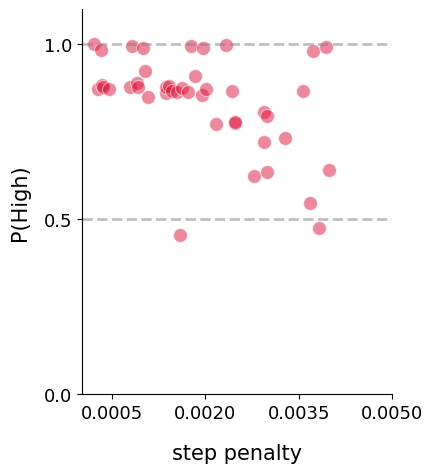

In [17]:
# scatter
plt.figure(figsize=(4, 5))
sns.scatterplot(x=sorted_penalties, y=sorted_phigh, marker='o', alpha=0.5, color="crimson", s=100)
plt.axhline(0.5, color='gray', alpha=0.5, linestyle='--', linewidth=2)
plt.axhline(1.0, color='gray', alpha=0.5, linestyle='--', linewidth=2)
plt.xlabel("step penalty", fontsize=15, labelpad=15)
plt.ylabel("P(High)", fontsize=15, labelpad=10)
plt.ylim([0.7, 1.1])
plt.yticks(np.arange(0, 1.1, 0.5), fontsize=13)
plt.xticks(np.arange(0.0005, 0.005, 0.0015), fontsize=13)
ax = plt.gca()
#ax.get_xticklabels()[0].set_visible(False)
#ax.get_yticklabels()[0].set_visible(False)
sns.despine(top=True, right=True)
plt.show()

### box plots

In [18]:
def add_sig_bar(ax, x1, x2, y, h, p):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=0.5, c='black')

    if p < 0.001:
        text = '***'
    elif p < 0.01:
        text = '**'
    elif p < 0.05:
        text = '*'
    else:
        text = 'n.s.'

    ax.text((x1+x2)/2, y+h, text, ha='center', va='bottom', fontsize=12)

In [520]:
penalties = np.array(sorted_penalties)
phighs = np.array(sorted_phigh)

# Sort indices by penalty
sorted_idx = np.argsort(penalties)

# Split into 4 equal-sized groups
quartile_indices = np.array_split(sorted_idx, 4)

q1_group = phighs[quartile_indices[0]]
q2_group = phighs[quartile_indices[1]]
q3_group = phighs[quartile_indices[2]]
q4_group = phighs[quartile_indices[3]]

In [521]:
from scipy.stats import kruskal, mannwhitneyu
import itertools

In [522]:
# overall test (4 groups)
stat, p = kruskal(q1_group, q2_group, q3_group, q4_group)
print("Kruskal-Wallis p =", p)

# pairwise comparisons
groups = {
    "q1": q1_group,
    "q2": q2_group,
    "q3": q3_group,
    "q4": q4_group
}

pairwise_p = {}

for (name1, g1), (name2, g2) in itertools.combinations(groups.items(), 2):
    p_val = mannwhitneyu(g1, g2, alternative='two-sided').pvalue
    pairwise_p[f"{name1} vs {name2}"] = p_val

# print results
for k, v in pairwise_p.items():
    print(f"{k}: p = {v}")

Kruskal-Wallis p = 0.01348440325848043
q1 vs q2: p = 0.03561636409984439
q1 vs q3: p = 0.02557464990093703
q1 vs q4: p = 0.006706275607805576
q2 vs q3: p = 0.4701007598741287
q2 vs q4: p = 0.13002979638383577
q3 vs q4: p = 0.3072263700681952


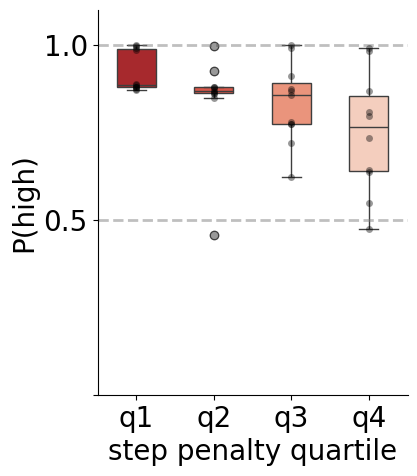

In [524]:
data = [q1_group, q2_group, q3_group, q4_group]

palette = "Reds_r"

plt.figure(figsize=(4, 5))

sns.boxplot(data=data, width=0.5, palette=palette)

# overlay session means (recommended)
sns.stripplot(data=data, color='black', alpha=0.4, jitter=False)

plt.ylim([0, 1.1])
plt.xticks([0, 1, 2, 3], ['q1', 'q2', 'q3', 'q4'], fontsize=20)
plt.yticks(np.arange(0, 1.1, 0.5), fontsize=20)

plt.ylabel("P(high)", fontsize=20)
plt.xlabel("step penalty quartile", fontsize=20)
ax = plt.gca()
ax.get_yticklabels()[0].set_visible(False)

plt.axhline(0.5, color='gray', alpha=0.5, linestyle='--', linewidth=2)
plt.axhline(1.0, color='gray', alpha=0.5, linestyle='--', linewidth=2)

sns.despine(top=True, right=True)

ax = plt.gca()

y_max = np.nanmax(phighs)
h = y_max * 0.05

# using pairwise_p dictionary from previous code
#add_sig_bar(ax, 0, 1, y_max + h, h, pairwise_p["q1 vs q2"])
#add_sig_bar(ax, 1, 2, y_max + h,   h, pairwise_p["q2 vs q3"])
#add_sig_bar(ax, 2, 3, y_max + h,   h, pairwise_p["q3 vs q4"])

# optional wider comparisons
#add_sig_bar(ax, 0, 2, y_max + 5*h,   h, pairwise_p["q1 vs q3"])
#add_sig_bar(ax, 1, 3, y_max + 9*h,   h, pairwise_p["q2 vs q4"])
#add_sig_bar(ax, 0, 3, y_max + 3*h,  h, pairwise_p["q1 vs q4"])

plt.show()

# P(High) against centrality

In [36]:
from analysis import opponent_visibility

Get slice onset positions for each session for each trial

In [37]:
slice_onset_positions_dict = {}
for j, trial_list in enumerate(trial_lists):
    pos_list = []
    for i in range(len(trial_list)):
        if i == 0:
            continue
        slice_onset_positions = (opponent_visibility.get_player_position_slice_onset(player_id=0, trial=None, trial_list=trial_list, trial_index=i))
        pos_list.append(slice_onset_positions)
    slice_onset_positions_dict[j] = pos_list

Find the arena radius through the data

In [38]:
all_positions = np.array([
    pos for pos_list in slice_onset_positions_dict.values()
    for pos in pos_list
    if pos is not None
])

In [39]:
arena_radius = np.nanmax(np.linalg.norm(all_positions, axis=1))

In [40]:
arena_radius

np.float64(19.74449542008289)

In [41]:
centrality_dict = {}
mean_centrality_dict = {}
for j, pos_list in slice_onset_positions_dict.items():
    centrality_dict[j] = []
    for pos in pos_list:
        if pos is None:
            centrality_dict[j].append(np.nan)
            continue
        dist = np.linalg.norm(pos)
        centrality = 1 - (dist / arena_radius) if arena_radius > 0 else 1.0
        centrality_dict[j].append(centrality)
    mean_centrality_dict[j] = np.nanmean(centrality_dict[j])

In [42]:
# collect average centrality for each session, sorted by step penalty
mean_centrality_list = []
sorted_penalties = []

for penalty, session_id in sorted(zip(step_penalties, mean_centrality_dict.keys()), key=lambda x: x[0]):
    mean_centrality_list.append(mean_centrality_dict[session_id])
    sorted_penalties.append(penalty)

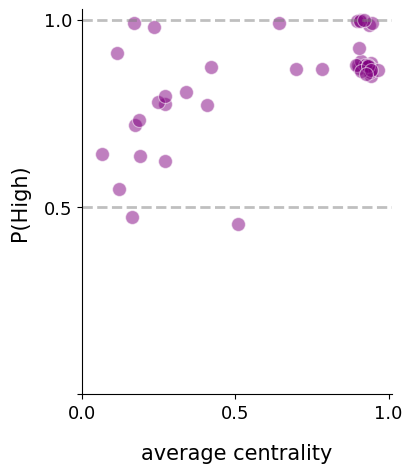

In [43]:
# scatter
plt.figure(figsize=(4, 5))
sns.scatterplot(x=mean_centrality_list, y=sorted_phigh, marker='o', alpha=0.5, color="purple", s=100)
plt.axhline(0.5, color='gray', alpha=0.5, linestyle='--', linewidth=2)
plt.axhline(1.0, color='gray', alpha=0.5, linestyle='--', linewidth=2)
plt.xlabel("average centrality", fontsize=15, labelpad=15)
plt.ylabel("P(High)", fontsize=15, labelpad=10)
#plt.ylim([0.7, 1.1])
plt.yticks(np.arange(0, 1.1, 0.5), fontsize=13)
plt.xticks(np.arange(0, 1.1, 0.5), fontsize=13)
ax = plt.gca()
#ax.get_xticklabels()[0].set_visible(False)
ax.get_yticklabels()[0].set_visible(False)
sns.despine(top=True, right=True)
plt.show()

### box plots

In [513]:
means = np.array(mean_centrality_list)
phighs = np.array(sorted_phigh)

# Sort indices by penalty
sorted_idx = np.argsort(means)

# Split into 4 equal-sized groups
quartile_indices = np.array_split(sorted_idx, 4)

q1_group = phighs[quartile_indices[0]]
q2_group = phighs[quartile_indices[1]]
q3_group = phighs[quartile_indices[2]]
q4_group = phighs[quartile_indices[3]]

In [514]:
from scipy.stats import kruskal, mannwhitneyu
import itertools

In [515]:
# overall test (4 groups)
stat, p = kruskal(q1_group, q2_group, q3_group, q4_group)
print("Kruskal-Wallis p =", p)

# pairwise comparisons
groups = {
    "q1": q1_group,
    "q2": q2_group,
    "q3": q3_group,
    "q4": q4_group
}

pairwise_p = {}

for (name1, g1), (name2, g2) in itertools.combinations(groups.items(), 2):
    p_val = mannwhitneyu(g1, g2, alternative='two-sided').pvalue
    pairwise_p[f"{name1} vs {name2}"] = p_val

# print results
for k, v in pairwise_p.items():
    print(f"{k}: p = {v}")

Kruskal-Wallis p = 0.023197202263932352
q1 vs q2: p = 0.2934238832742103
q1 vs q3: p = 0.01511526935649349
q1 vs q4: p = 0.04475929457557227
q2 vs q3: p = 0.03561636409984439
q2 vs q4: p = 0.2178322292372723
q3 vs q4: p = 0.2750629920777592


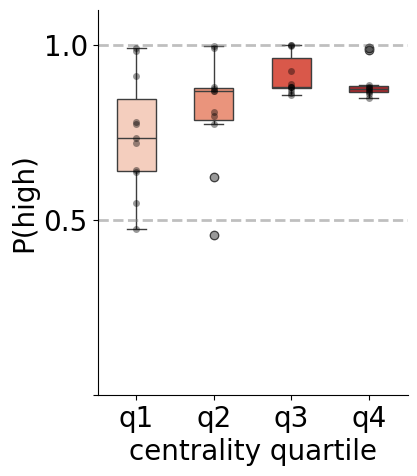

In [519]:
data = [q1_group, q2_group, q3_group, q4_group]

palette = "Reds"

plt.figure(figsize=(4, 5))

sns.boxplot(data=data, width=0.5, palette=palette)

# overlay session means (recommended)
sns.stripplot(data=data, color='black', alpha=0.4, jitter=False)

plt.ylim([0, 1.1])
plt.xticks([0, 1, 2, 3], ['q1', 'q2', 'q3', 'q4'], fontsize=20)
plt.yticks(np.arange(0, 1.1, 0.5), fontsize=20)

plt.ylabel("P(high)", fontsize=20)
plt.xlabel("centrality quartile", fontsize=20)
ax = plt.gca()
ax.get_yticklabels()[0].set_visible(False)

plt.axhline(0.5, color='gray', alpha=0.5, linestyle='--', linewidth=2)
plt.axhline(1.0, color='gray', alpha=0.5, linestyle='--', linewidth=2)

sns.despine(top=True, right=True)

ax = plt.gca()

y_max = np.nanmax(phighs)
h = y_max * 0.05

ax = plt.gca()

plt.show()

## P(High) across walls

In [534]:
solo_example = [trial_lists_solo[19]]

In [535]:
analysis_results = {
    session_id: {

            # trial list and filtered trial indices
            'trial_lists': {
                'full_session': None
            },

            # chosen wall numbers and whether high or low
            'choice_data' : {
                'wall_numbers': None,
                'chose_high': None,
                'probability_chose_high': None  # array of values from walls 1 to 8
            }
            

        }
    #for session_id in np.arange(len(trial_lists))
    for session_id in np.arange(len(solo_example))
}

In [536]:
for session_id in analysis_results.keys():

    print(f"\n\nProcessing session: {session_id}\n\n")
    player_data = analysis_results[session_id]
    #trial_list = trial_lists[session_id]
    trial_list = solo_example[session_id]
    print(f"Number of trials in full session: {len(trial_list)}")


    player_data['trial_lists']['full_session'] = trial_list



Processing session: 0


Number of trials in full session: 668


In [537]:
for session_id in analysis_results.keys():
    
    player_data = analysis_results[session_id]
    trial_list = player_data['trial_lists']['full_session']
    print(session_id)

    player_data['choice_data']['wall_numbers'] = get_indices.get_chosen_walls(trial_list).astype(int)
    player_data['choice_data']['chose_high'] = get_indices.was_high_wall_chosen(trial_list)


    # print(len(player_data['choice_data']['chose_high']))

0


In [538]:
for session_id in analysis_results.keys():
    
    player_data = analysis_results[session_id]
    wall_numbers = player_data['choice_data']['wall_numbers']
    chose_high = player_data['choice_data']['chose_high']

    wall_probabilities = np.full(8, np.nan)

    # specify min bins == highest integer value + 1
    # slice from index 1 because 0 will always be counted, but is not relevant
    counts = np.bincount(wall_numbers, minlength=9)[1:]  # count occurrences of 1-8
    chosen_counts = np.bincount(wall_numbers[chose_high], minlength=9)[1:]  # count True occurrences

    mask = counts > 0  # Avoid division by zero
    mask = counts > 4  # Ensure at least 5 trials per wall to calculate probability
    wall_probabilities[mask] = chosen_counts[mask] / counts[mask]

    player_data['choice_data']['probability_chose_high'] = wall_probabilities

In [539]:
wall_number_list = [analysis_results[session_id]['choice_data']['wall_numbers']
 for session_id in analysis_results
 ]
chose_high_list = [analysis_results[session_id]['choice_data']['chose_high']
 for session_id in analysis_results
 ]


wall_numbers = np.concatenate(wall_number_list).astype(int)
chose_high = np.concatenate(chose_high_list)

In [540]:
# more efficient code with vectorised functions

wall_probabilities = np.full(8, np.nan)

# specify min bins == highest integer value + 1
# slice from index 1 because 0 will always be counted, but is not relevant
counts = np.bincount(wall_numbers, minlength=9)[1:]  # count occurrences of 1-8
chosen_counts = np.bincount(wall_numbers[chose_high], minlength=9)[1:]  # count True occurrences

mask = counts > 0  # Avoid division by zero
wall_probabilities[mask] = chosen_counts[mask] / counts[mask]

In [541]:
# get error bars

standard_error = np.sqrt((wall_probabilities * (1 - wall_probabilities)) / len(wall_number_list))

### example model

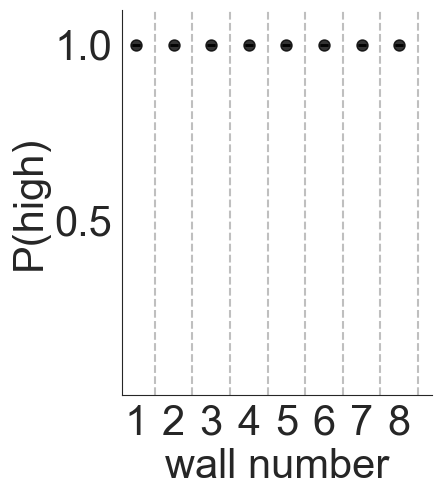

In [542]:
wall_numbers = np.arange(1,9)
wall_probabilities = wall_probabilities

# set seaborn style
sns.set_style("white", {"axes.grid": False})

# create figure and axis
plt.figure(figsize=(4, 5))

# plot vertical dashed grey lines for each categorical x value
for x in wall_numbers:
    plt.axvline(x=x+0.5, color='grey', linestyle='dashed', alpha=0.5)

# plot the probability line with markers
#sns.lineplot(x=wall_numbers, y=wall_probabilities, marker='o', markersize=8, linewidth=2.5, color="black")
#plt.errorbar(x=wall_numbers, y=wall_probabilities, yerr=standard_error, fmt="o")
plt.errorbar(
    wall_numbers,
    wall_probabilities,
    yerr=standard_error,
    fmt='o',
    alpha=0.8,
    color="black",
    markersize=8,

    ecolor='black',            
    elinewidth=2,              
    capsize=3,                 
    capthick=2,

    linestyle='none'
)
# Customize labels and title
plt.xlabel("wall number", fontsize=30)
plt.ylabel("P(high)", fontsize=30)
# plt.title("Probability of Choosing High by Wall Number", fontsize=14)

# set y-axis for probability
plt.ylim([0,1.1])

# adjust x-axis ticks to match categorical values
plt.xticks(wall_numbers, fontsize=30)
plt.yticks(np.arange(0, 1.1, 0.5), fontsize=30)

ax = plt.gca()
ax.get_yticklabels()[0].set_visible(False)

# Remove top and right borders
sns.despine(top=True, right=True)

# show the plot
plt.show()

# P(High) heatmaps in circular bins

In [237]:
num_players = 1
first_visible_wall_index = 0
chosen_wall_index = 0 

In [238]:
pairs = list(zip(step_penalties, trial_lists))
pairs_sorted = sorted(pairs, key=lambda x: x[0])

step_penalties_sorted, trial_lists_sorted = zip(*pairs_sorted)

step_penalties_sorted = list(step_penalties_sorted)
trial_lists_sorted = list(trial_lists_sorted)

In [239]:
penalties = np.array(step_penalties_sorted)

low_thresh = np.percentile(penalties, 25)
mid_thresh = np.percentile(penalties, 50)
high_thresh = np.percentile(penalties, 75)

In [240]:
low_lists = []
mid_low_lists = []
mid_high_lists = []
high_lists = []

low_ids = []
mid_low_ids = []
mid_high_ids = []
high_ids = []

In [242]:
for session_id, (penalty, trial_list) in enumerate(zip(step_penalties, trial_lists)):

    if penalty <= low_thresh:
        low_lists.append(trial_list)
        low_ids.append(session_id)

    elif penalty <= mid_thresh:
        mid_low_lists.append(trial_list)
        mid_low_ids.append(session_id)

    elif penalty <= high_thresh:
        mid_high_lists.append(trial_list)
        mid_high_ids.append(session_id)

    else:
        high_lists.append(trial_list)
        high_ids.append(session_id)

## P(High) when High first visible in octagon space split by step penalty range

low sp

In [243]:
(trial_list_high_vis_filtered_1,
 trial_list_high_vis_and_choice_filtered_1) = heatmap_phigh.filter_pipeline_p_high_first_seen_wall(
    low_lists,
    num_players,
    first_visible_wall_index,
    chosen_wall_index
)

filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 1. 1. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0.
 1. 0. 0. 1. 1. 0. 0. 0. 1. 1. 0. 1. 1. 1. 0. 1. 0. 1. 0. 0. 0. 0. 1. 1.
 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 1. 1. 0. 0. 1. 0. 0.
 0. 1. 1. 0. 0. 1. 1. 0. 1. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 1. 0. 1. 0.
 0. 1. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 1. 0. 1. 0. 1. 1. 0. 0. 0. 1.
 0. 0. 0. 1. 1. 0. 1. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.
 0. 0. 1. 1. 0. 1. 1. 1. 0. 0. 1. 1. 0. 0. 0. 1. 1. 0. 1. 0. 1. 0. 0. 0.
 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 1. 0. 1. 1. 0. 1. 0. 1. 0. 0. 0. 1. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 1. 0. 0. 0. 1. 0. 1. 0. 0. 1. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 0. 1. 0. 0. 1. 1. 0. 1. 0. 0. 0. 1. 0.
 1. 1. 1. 0. 1. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1.
 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 1. 1. 0. 1. 1. 0. 0. 1. 0. 1. 1. 0. 0.
 1. 0. 1. 0. 0. 1. 1. 0. 1. 1. 0. 1. 

medium-low sp

In [244]:
(trial_list_high_vis_filtered_2,
 trial_list_high_vis_and_choice_filtered_2) = heatmap_phigh.filter_pipeline_p_high_first_seen_wall(
    mid_low_lists,
    num_players,
    first_visible_wall_index,
    chosen_wall_index
)

filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[0. 1. 1. 1. 0. 0. 0. 0. 1. 0. 1. 1. 0. 0. 0. 0. 0. 1. 1. 0. 1. 0. 0. 1.
 1. 0. 1. 1. 1. 1. 0. 0. 1. 0. 0. 1. 1. 0. 1. 1. 0. 0. 1. 0. 1. 0. 0. 0.
 1. 0. 1. 0. 0. 0. 0. 1. 0. 1. 1. 1. 1. 0. 0. 1. 0. 1. 1. 0. 1. 0. 0. 1.
 1. 0. 1. 1. 0. 0. 1. 0. 0. 1. 1. 1. 1. 1. 1. 0. 0. 0. 1. 1. 0. 0. 0. 0.
 0. 1. 1. 0. 0. 1. 0. 0. 1. 0. 1. 0. 1. 1. 0. 0. 0. 0. 1. 1. 0. 0. 1. 1.
 0. 1. 1. 1. 1. 1. 1. 0. 1. 1. 0. 1. 1. 1. 1. 0. 0. 1. 1. 1. 0. 0. 1. 0.
 1. 0. 0. 0. 0. 1. 1. 0. 0. 0. 1. 0. 1. 1. 1. 0. 0. 0. 1. 0. 1. 0. 0. 0.
 1. 0. 1. 1. 0. 0. 1. 1. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 1. 1. 0. 1. 0. 1. 0. 1. 1. 1. 1. 0. 0. 1. 0. 0. 0. 0. 1. 1. 0. 0. 1. 0.
 0. 1. 1. 0. 0. 0. 0. 0. 1. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 0.
 1. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.
 0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 1. 1. 1. 0. 0. 1. 0. 1. 0. 0. 0. 1. 0. 0.
 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 

medium-high sp

In [245]:
(trial_list_high_vis_filtered_3,
 trial_list_high_vis_and_choice_filtered_3) = heatmap_phigh.filter_pipeline_p_high_first_seen_wall(
    mid_high_lists,
    num_players,
    first_visible_wall_index,
    chosen_wall_index
)

filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[1. 0. 1. 0. 0. 0. 1. 1. 0. 0. 0. 1. 1. 1. 0. 1. 1. 1. 0. 1. 0. 0. 0. 1.
 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 1. 1. 0. 0. 1. 0. 0. 0.
 0. 0. 1. 0. 1. 0. 1. 0. 0. 0. 1. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0.
 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 1. 0. 0. 0.
 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 1. 0. 1. 0. 1. 0. 0.
 1. 0. 0. 1. 0. 1. 1. 1. 0. 1. 0. 0. 0. 0. 1. 1. 1. 1. 1. 0. 0. 1. 0. 0.
 1. 1. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 1. 0. 1.
 0. 0. 1. 0. 1. 0. 0. 1. 0. 1. 1. 1. 1. 1. 0. 1. 0. 1. 0. 1. 1. 1. 0. 0.
 0. 0. 1. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 0. 0. 0. 1.
 1. 0. 1. 1. 0. 1. 1. 1. 0. 0. 1. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 1. 1. 0.
 1. 0. 1. 0. 0. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1.
 0. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 1. 0.
 0. 1. 0. 1. 1. 1. 1. 0. 0. 0. 1. 1. 

high sp

In [246]:
(trial_list_high_vis_filtered_4,
 trial_list_high_vis_and_choice_filtered_4) = heatmap_phigh.filter_pipeline_p_high_first_seen_wall(
    high_lists,
    num_players,
    first_visible_wall_index,
    chosen_wall_index
)

filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[1. 0. 0. 0. 1. 1. 0. 1. 1. 0. 1. 0. 1. 1. 0. 1. 0. 1. 1. 0. 0. 0. 0. 1.
 0. 0. 0. 0. 1. 1. 1. 0. 0. 0. 1. 0. 1. 0. 0. 0. 1. 0. 1. 1. 0. 0. 0. 0.
 0. 0. 1. 0. 1. 1. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 1. 0.
 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 1. 1. 0. 0. 1. 0. 0. 0. 1. 0. 0.
 1. 0. 1. 1. 0. 0. 1. 1. 1. 0. 1. 1. 1. 0. 0. 0. 1. 0. 1. 0. 0. 1. 1. 0.
 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 1. 1. 0. 0. 1. 0. 0. 1. 0. 1. 1. 0. 0.
 1. 1. 0. 1. 0. 1. 1. 1. 0. 0. 1. 1. 0. 0. 0. 1. 1. 1. 1. 0. 0. 0. 1. 0.
 1. 0. 0. 0. 1. 0. 1. 1. 1. 0. 0. 1. 1. 0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 1.
 1. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 1. 1. 1. 0. 1. 1. 0. 0. 1. 0. 1. 0. 0.
 1. 1. 0. 1. 1. 0. 0. 1. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.
 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 1. 0. 1. 1. 0. 0. 1. 1. 0. 1. 0. 1. 1.
 0. 0. 1. 1. 0. 0. 1. 0. 0. 0. 1. 0. 1. 1. 1. 0. 0. 1. 0. 0. 0. 0. 0. 1.
 1. 0. 1. 1. 1. 1. 0. 0. 0. 1. 0. 1. 

Get slice onset positions for each session for each trial

In [247]:
slice_onset_positions_1 = {}
slice_onset_positions_2 = {}
slice_onset_positions_3 = {}
slice_onset_positions_4 = {}

quartile_lists = [
    low_lists,
    mid_low_lists,
    mid_high_lists,
    high_lists
]

slice_onset_position_dicts = [
    slice_onset_positions_1,
    slice_onset_positions_2,
    slice_onset_positions_3,
    slice_onset_positions_4
]

for group_lists, output_dict in zip(quartile_lists, slice_onset_position_dicts):
    for j, trial_list in enumerate(group_lists):
        pos_list = []

        for i in range(1, len(trial_list)):
            slice_onset_positions = opponent_visibility.get_player_position_slice_onset(
                player_id=0,
                trial=None,
                trial_list=trial_list,
                trial_index=i
            )
            pos_list.append(slice_onset_positions)

        output_dict[j] = pos_list

Find the arena radius through the data

In [248]:
all_positions = np.array([
    pos for pos_list in slice_onset_positions_dict.values()
    for pos in pos_list
    if pos is not None
])

In [249]:
arena_radius = np.nanmax(np.linalg.norm(all_positions, axis=1))

In [287]:
num_radial_bins = 10
r_max = arena_radius
radial_bins = np.linspace(0, r_max, num_radial_bins + 1)

Changing radial bins to be split by bin count

In [152]:
def collect_radial_distances(quartile_filtered, num_players):
    radial_distances = []

    for filtered in quartile_filtered:
        for player_id in range(num_players):
            trial_lists_denominator = filtered[player_id]

            for trial_list in trial_lists_denominator:
                for trial in trial_list:
                    x_val, y_val = get_indices.get_player_slice_onset_loc(
                        trial,
                        player_id=player_id
                    )
                    radial_distances.append(np.sqrt(x_val**2 + y_val**2))

    return np.asarray(radial_distances)


def make_count_balanced_radial_bins(radial_distances, num_radial_bins):
    radial_distances = np.asarray(radial_distances)
    radial_distances = radial_distances[~np.isnan(radial_distances)]

    radial_bins = np.percentile(
        radial_distances,
        np.linspace(0, 100, num_radial_bins + 1)
    )

    radial_bins = np.unique(radial_bins)

    return radial_bins

In [288]:
quartile_filtered = [
    trial_list_high_vis_filtered_1,
    trial_list_high_vis_filtered_2,
    trial_list_high_vis_filtered_3,
    trial_list_high_vis_filtered_4,
]

quartile_filtered_and_choice = [
    trial_list_high_vis_and_choice_filtered_1,
    trial_list_high_vis_and_choice_filtered_2,
    trial_list_high_vis_and_choice_filtered_3,
    trial_list_high_vis_and_choice_filtered_4,
]

In [190]:
num_radial_bins_requested = 6

radial_distances = collect_radial_distances(
    quartile_filtered,
    num_players
)

radial_bins = make_count_balanced_radial_bins(
    radial_distances,
    num_radial_bins_requested
)

num_radial_bins = len(radial_bins) - 1

In [289]:

bins_wall_seen = []
bins_wall_seen_wall_chosen = []

for group_index, (filtered, filtered_and_choice) in enumerate(
    zip(quartile_filtered, quartile_filtered_and_choice),
    start=1
):
    # initialise bin counts for this quartile group
    wall_seen_counts = np.zeros(num_radial_bins)
    wall_seen_wall_chosen_counts = np.zeros(num_radial_bins)

    for player_id in range(num_players):

        # denominator: trials where player saw specified first-seen wall
        trial_lists_denominator = filtered[player_id]

        # numerator: trials where player additionally chose specified chosen wall
        trial_lists_numerator = filtered_and_choice[player_id]

        for trial_list in trial_lists_denominator:
            for trial in trial_list:

                x_val, y_val = get_indices.get_player_slice_onset_loc(
                    trial,
                    player_id=player_id
                )

                r = np.sqrt(x_val**2 + y_val**2)
                bin_index = np.digitize(r, radial_bins) - 1

                if 0 <= bin_index < num_radial_bins:
                    wall_seen_counts[bin_index] += 1

        for trial_list in trial_lists_numerator:
            for trial in trial_list:

                x_val, y_val = get_indices.get_player_slice_onset_loc(
                    trial,
                    player_id=player_id
                )

                r = np.sqrt(x_val**2 + y_val**2)
                bin_index = np.digitize(r, radial_bins) - 1

                if 0 <= bin_index < num_radial_bins:
                    wall_seen_wall_chosen_counts[bin_index] += 1

        print(
            f"Done for quartile {group_index}, player {player_id}, "
            f"counts in numerator bin 0: {wall_seen_wall_chosen_counts[0]}"
        )

    bins_wall_seen.append(wall_seen_counts)
    bins_wall_seen_wall_chosen.append(wall_seen_wall_chosen_counts)

Done for quartile 1, player 0, counts in numerator bin 0: 4624.0
Done for quartile 2, player 0, counts in numerator bin 0: 3876.0
Done for quartile 3, player 0, counts in numerator bin 0: 934.0
Done for quartile 4, player 0, counts in numerator bin 0: 0.0


In [290]:
pH_by_bin_high = []
probabilities_high = []

min_trials_per_bin = 15

for group_index, (numerator_counts, denominator_counts) in enumerate(
    zip(bins_wall_seen_wall_chosen, bins_wall_seen),
    start=1
):
    pH_by_bin = np.divide(
        numerator_counts,
        denominator_counts,
        out=np.zeros_like(numerator_counts, dtype=float),
        where=denominator_counts > 0
    )

    # filter out bins with too few denominator trials
    pH_by_bin[denominator_counts <= min_trials_per_bin] = np.nan

    pH_by_bin_high.append(pH_by_bin)
    probabilities_high.append(pH_by_bin)

    print(f"Computed probabilities for quartile {group_index}")

Computed probabilities for quartile 1
Computed probabilities for quartile 2
Computed probabilities for quartile 3
Computed probabilities for quartile 4


In [333]:
def plot_heatmap_phigh_circular(
    probabilities,
    radial_bins,
    bin_counts=None,
    cmap_name='inferno',
    diff_cmap_name='PiYG',
    show_counts=True,
    title=None,
    diff=False
):
    '''Plot P(Choose High) across radial bins overlaid on octagon.

    probabilities: 1D array of probabilities across radial bins
    radial_bins: bin edges for radial distance
    bin_counts: 1D array of denominator counts for each radial bin
    '''

    octagon_vertex_coordinates = plot_octagon.return_octagon_path_points()

    fig, ax = plt.subplots(figsize=(8, 8))

    cmap = cm.get_cmap(cmap_name)
    cmap.set_bad(color='white')
    
    if diff:
        norm = mpl.colors.Normalize(vmin=-1, vmax=1)
    else:
        norm = mpl.colors.Normalize(vmin=0, vmax=1)

    octagon_clip = Polygon(
        octagon_vertex_coordinates,
        closed=True,
        facecolor='none',
        edgecolor='none',
        transform=ax.transData
    )

    for i in range(len(radial_bins) - 1):
        r_inner = radial_bins[i]
        r_outer = radial_bins[i + 1]
        r_mid = (r_inner + r_outer) / 2

        theta = np.linspace(0, 2 * np.pi, 500)

        x_outer = r_outer * np.cos(theta)
        y_outer = r_outer * np.sin(theta)

        x_inner = r_inner * np.cos(theta[::-1])
        y_inner = r_inner * np.sin(theta[::-1])

        vertices = np.column_stack([
            np.concatenate([x_outer, x_inner]),
            np.concatenate([y_outer, y_inner])
        ])

        color = cmap(norm(probabilities[i]))

        patch = Polygon(
            vertices,
            facecolor=color,
            edgecolor='black',
            linewidth=0,
            antialiased=True
        )

        patch.set_clip_path(octagon_clip)
        ax.add_patch(patch)

        # Add bin count label inside ring
        if show_counts and bin_counts is not None:
            count = bin_counts[i]

            if not np.isnan(probabilities[i]):
                
                ax.text(
                    0,
                    r_mid,
                    f"{int(count)}",
                    ha='center',
                    va='center',
                    fontsize=12,
                    color='white',
                    fontweight='bold'
                )

    # Overlay octagon outline
    octagon_patch = Polygon(
        octagon_vertex_coordinates,
        closed=True,
        edgecolor='black',
        facecolor='none',
        lw=2
    )
    ax.add_patch(octagon_patch)

    if title is not None:
        if diff:
            ax.set_title(f"average ΔP(high) = {title}", fontsize=20)
        else:
            ax.set_title(f"average P(high) = {title}", fontsize=20)

    ax.set_xlim([-25, 25])
    ax.set_ylim([-25, 25])
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, pad=0, shrink=1)
    cbar.ax.tick_params(labelsize=20, length=6, width=1.5)
    if diff:
        cbar.set_label("ΔP(high)", size=20)
        cbar.set_ticks(np.arange(-1, 1.1, 0.5))
    else:
        cbar.set_label("P(high)", size=20)
        cbar.set_ticks(np.arange(0, 1.1, 0.5))

    return fig, ax

### Heatmap for low step penalty lists

In [291]:
title1=np.round(np.nanmean(probabilities_high[0]),2)

/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_1173/3647730139.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


(<Figure size 800x800 with 2 Axes>,
 <Axes: title={'center': 'average P(high) = 1.0'}>)

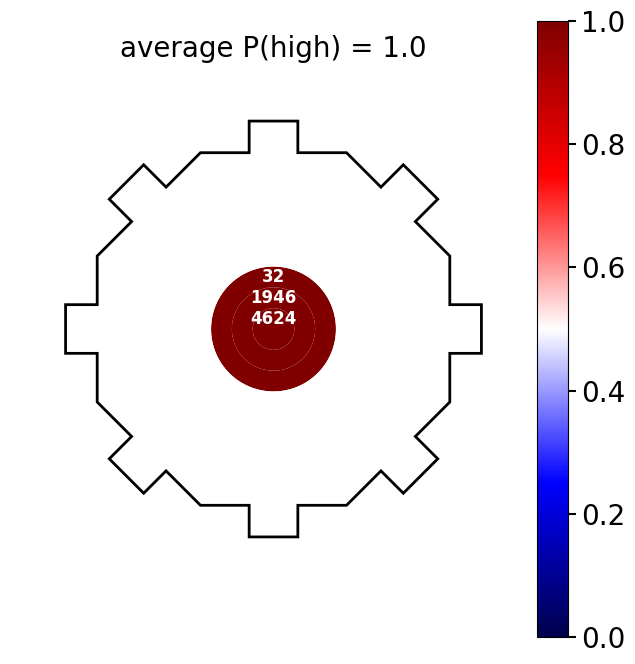

In [292]:
plot_heatmap_phigh_circular(probabilities_high[0], radial_bins, bin_counts=bins_wall_seen[0],
                                 cmap_name='seismic', diff_cmap_name='PiYG', title=title1)

/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_1173/1893720993.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


(<Figure size 800x800 with 2 Axes>,
 <Axes: title={'center': 'average P(high) = 1.0'}>)

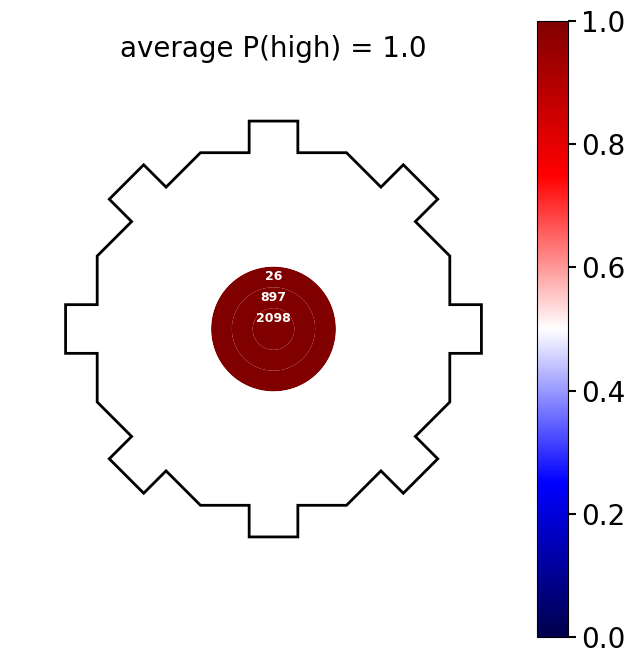

In [136]:
plot_heatmap_phigh_circular(probabilities_high[0], radial_bins, bin_counts=bins_wall_seen[0],
                                 cmap_name='seismic', diff_cmap_name='PiYG', title=title1)

In [259]:
title2=np.round(np.nanmean(probabilities_high[1]),2)

/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_1173/3647730139.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


(<Figure size 800x800 with 2 Axes>,
 <Axes: title={'center': 'average P(high) = 0.88'}>)

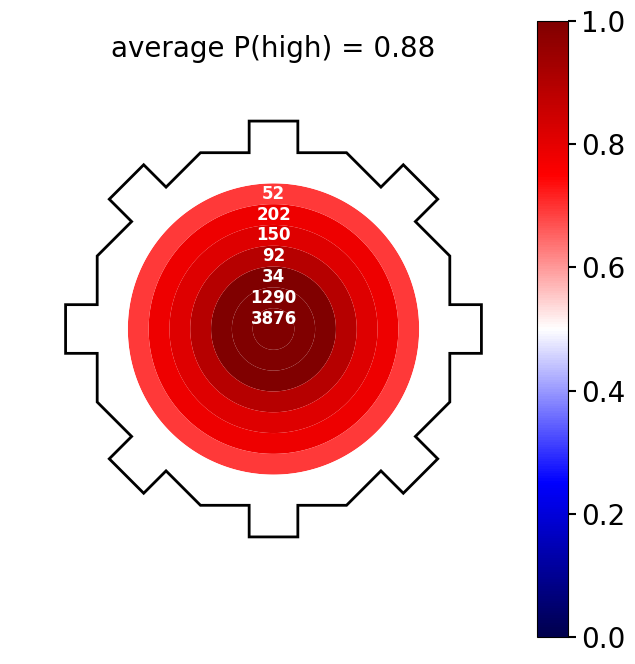

In [260]:
plot_heatmap_phigh_circular(probabilities_high[1], radial_bins, bin_counts=bins_wall_seen[1],
                                 cmap_name='seismic', diff_cmap_name='PiYG', title=title2)

/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_1173/1893720993.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


(<Figure size 800x800 with 2 Axes>,
 <Axes: title={'center': 'average P(high) = 0.88'}>)

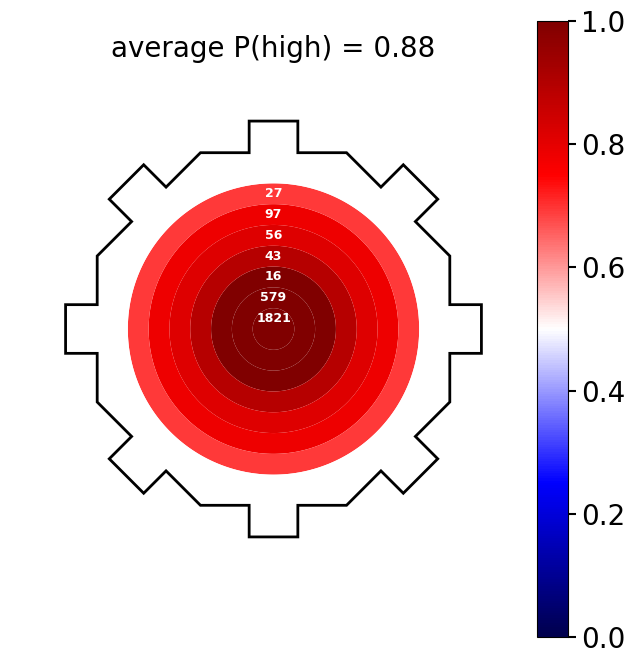

In [139]:
plot_heatmap_phigh_circular(probabilities_high[1], radial_bins, bin_counts=bins_wall_seen[1],
                                 cmap_name='seismic', diff_cmap_name='PiYG', title=title2)

In [261]:
title3=np.round(np.nanmean(probabilities_high[2]),2)

/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_1173/3647730139.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


(<Figure size 800x800 with 2 Axes>,
 <Axes: title={'center': 'average P(high) = 0.95'}>)

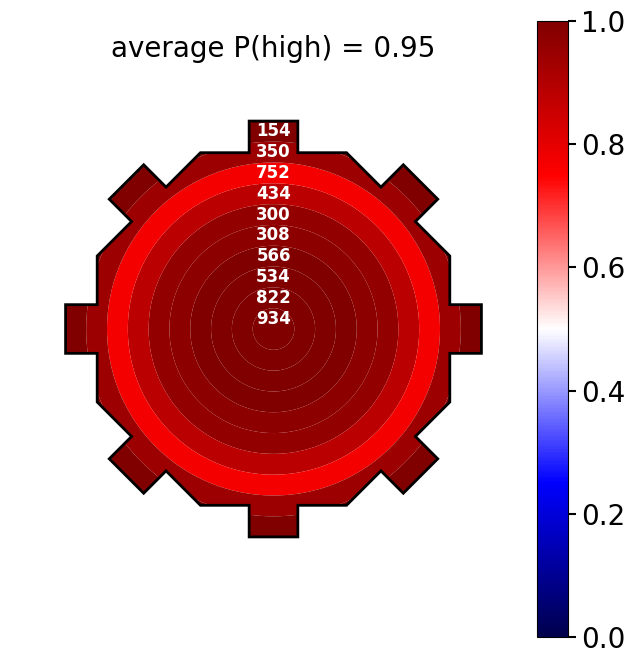

In [262]:
plot_heatmap_phigh_circular(probabilities_high[2], radial_bins, bin_counts=bins_wall_seen[2],
                                 cmap_name='seismic', diff_cmap_name='PiYG', title=title3)

/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_1173/1893720993.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


(<Figure size 800x800 with 2 Axes>,
 <Axes: title={'center': 'average P(high) = 0.95'}>)

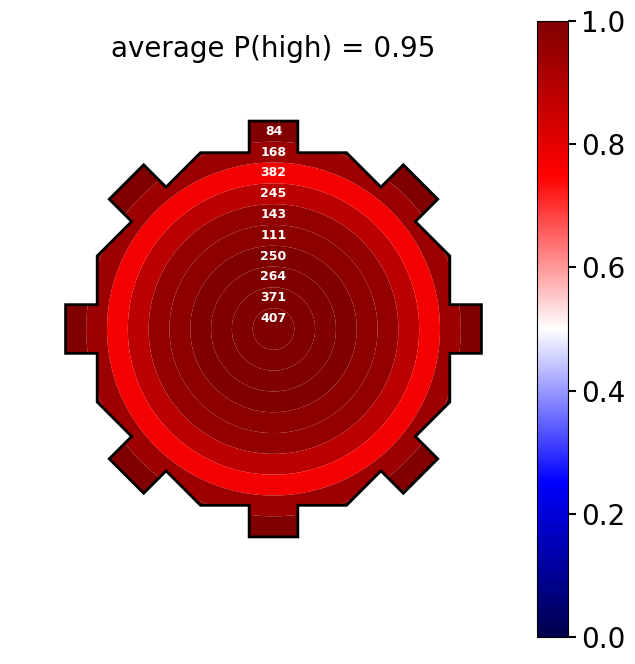

In [142]:
plot_heatmap_phigh_circular(probabilities_high[2], radial_bins, bin_counts=bins_wall_seen[2],
                                 cmap_name='seismic', diff_cmap_name='PiYG', title=title3)

In [263]:
title4=np.round(np.nanmean(probabilities_high[3]),2)

/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_1173/3647730139.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


(<Figure size 800x800 with 2 Axes>,
 <Axes: title={'center': 'average P(high) = 0.84'}>)

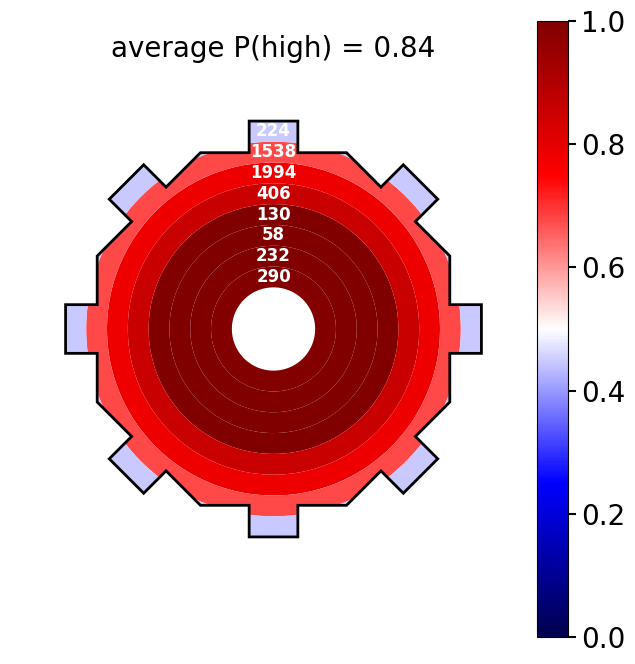

In [264]:
plot_heatmap_phigh_circular(probabilities_high[3], radial_bins, bin_counts=bins_wall_seen[3], 
                                 cmap_name='seismic', diff_cmap_name='PiYG', title=title4)

/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_1173/1893720993.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


(<Figure size 800x800 with 2 Axes>,
 <Axes: title={'center': 'average P(high) = 0.84'}>)

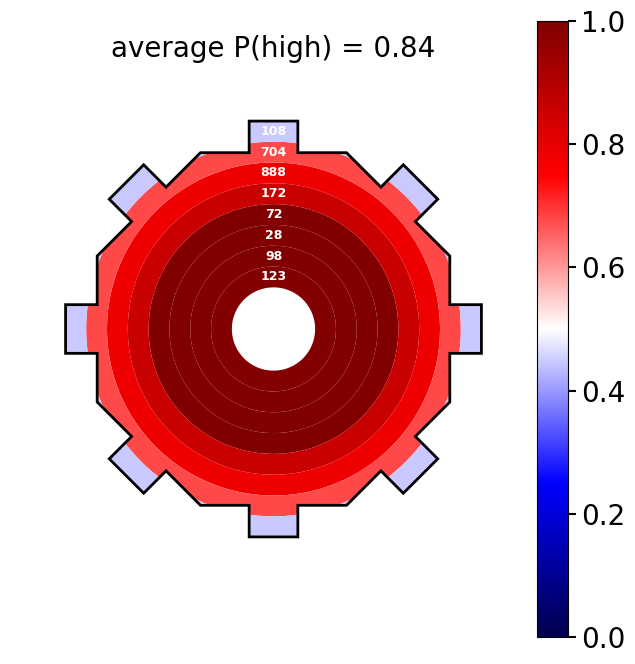

In [145]:
plot_heatmap_phigh_circular(probabilities_high[3], radial_bins, bin_counts=bins_wall_seen[3], 
                                 cmap_name='seismic', diff_cmap_name='PiYG', title=title4)

## P(High) when Low first visible in octagon space split by step penalty range

In [293]:
num_players = 1
first_visible_wall_index = 1
chosen_wall_index = 0 

low sp

In [294]:
(trial_list_high_vis_filtered_5,
 trial_list_high_vis_and_choice_filtered_5) = heatmap_phigh.filter_pipeline_p_high_first_seen_wall(
    low_lists,
    num_players,
    first_visible_wall_index,
    chosen_wall_index
)

filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[1. 0. 1. 0. 1. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 0. 1. 1.
 0. 1. 1. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 1. 0. 1. 0. 1. 0. 0. 0. 0. 0.
 1. 0. 1. 1. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 1. 1. 1. 0. 0. 0. 1. 0. 0. 1.
 0. 0. 0. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1. 0. 0. 1. 1. 1. 0. 1. 0. 1. 0. 0.
 0. 0. 0. 0. 1. 1. 1. 0. 0. 1. 1. 0. 0. 0. 0. 1. 0. 1. 0. 0. 1. 0. 0. 0.
 1. 1. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 1. 0. 1. 1. 1. 1. 1. 0. 1. 1. 0. 1.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 1. 0. 1. 0. 1.
 0. 0. 0. 0. 0. 1. 0. 1. 1. 0. 0. 1. 0. 0. 1. 0. 0. 0. 1. 1. 0. 0. 0. 1.
 1. 1. 1. 0. 0. 0. 1. 0. 0. 1. 0. 1. 1. 1. 0. 1. 0. 0. 1. 0. 1. 1. 0. 1.
 1. 1. 0. 1. 0. 1. 1. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 1.
 0. 0. 0. 1. 0. 0. 1. 1. 1. 0. 0. 0. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1. 0.
 1. 0. 1. 1. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0.
 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 

medium-low sp

In [295]:
(trial_list_high_vis_filtered_6,
 trial_list_high_vis_and_choice_filtered_6) = heatmap_phigh.filter_pipeline_p_high_first_seen_wall(
    mid_low_lists,
    num_players,
    first_visible_wall_index,
    chosen_wall_index
)

filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[1. 0. 0. 0. 1. 1. 0. 1. 0. 1. 0. 0. 0. 1. 0. 1. 0. 0. 0. 1. 0. 1. 0. 0.
 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 1. 1. 1. 1. 0. 1. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 1. 0. 1. 1. 0.
 0. 0. 0. 0. 1. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 1.
 0. 0. 0. 1. 1. 0. 1. 1. 0. 1. 0. 1. 0. 0. 1. 0. 0. 1. 0. 0. 1. 1. 0. 0.
 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 1. 1. 0. 0.
 0. 1. 1. 1. 1. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 1. 0. 1. 0. 1. 0. 0.
 0. 1. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 1. 0. 1. 1. 1. 0. 1. 1. 0.
 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 1. 0. 1. 1. 0. 0. 1. 1. 0. 0.
 1. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0.
 0. 1. 1. 1. 0. 0. 0. 1. 0. 1. 0. 0. 0. 1. 1. 1. 1. 0. 0. 0. 0. 0. 1. 0.
 0. 0. 0. 0. 1. 0. 1. 1. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 1. 1. 0. 0. 1. 1.
 0. 0. 1. 1. 1. 0. 0. 1. 0. 0. 1. 0. 

medium-high sp

In [296]:
(trial_list_high_vis_filtered_7,
 trial_list_high_vis_and_choice_filtered_7) = heatmap_phigh.filter_pipeline_p_high_first_seen_wall(
    mid_high_lists,
    num_players,
    first_visible_wall_index,
    chosen_wall_index
)

filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[0. 0. 0. 1. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.
 0. 0. 1. 0. 0. 0. 0. 1. 0. 1. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.
 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 1. 1. 0. 1. 1. 1. 0. 1. 0. 0. 0.
 1. 0. 0. 1. 0. 1. 1. 0. 1. 0. 0. 0. 1. 1. 1. 0. 1. 1. 1. 0. 0. 1. 1. 0.
 1. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 1. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 1. 0. 1. 0. 0. 0. 0. 0. 1. 1. 0. 1. 0.
 0. 0. 0. 0. 1. 0. 0. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1. 0. 0. 0. 1. 0. 1. 0.
 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 1. 0. 0. 0. 0. 0.
 0. 1. 0. 0. 1. 1. 0. 0. 1. 0. 1. 1. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 1. 0.
 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 1. 0. 0. 1. 1. 0. 0. 1. 1. 1. 0. 0. 0.
 0. 1. 0. 1. 1. 0. 0. 0. 0. 0. 1. 1. 0. 1. 0. 0. 1. 1. 0. 0. 1. 0. 1. 0.
 0. 0. 0. 0. 0. 1. 0. 0. 1. 1. 0. 0. 0. 0. 0. 1. 0. 1. 1. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 0. 0. 

high sp

In [297]:
(trial_list_high_vis_filtered_8,
 trial_list_high_vis_and_choice_filtered_8) = heatmap_phigh.filter_pipeline_p_high_first_seen_wall(
    high_lists,
    num_players,
    first_visible_wall_index,
    chosen_wall_index
)

filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[0. 1. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 1. 1. 0.
 1. 1. 1. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 1. 1. 0. 0. 0. 0. 1. 1. 1. 0.
 1. 0. 0. 1. 0. 0. 0. 1. 1. 1. 0. 0. 0. 0. 1. 1. 0. 1. 1. 0. 0. 0. 0. 0.
 0. 1. 1. 1. 1. 1. 1. 0. 0. 1. 1. 0. 1. 0. 0. 0. 1. 0. 1. 1. 0. 0. 1. 1.
 0. 1. 0. 0. 1. 1. 0. 0. 0. 1. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 1. 0. 0. 1.
 1. 0. 1. 0. 1. 0. 1. 0. 1. 1. 1. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0.
 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 1. 1. 0. 0. 0. 0. 1. 1. 0. 0. 0.
 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 1. 0. 1. 0.
 0. 1. 0. 1. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 1.
 0. 0. 1. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 1. 1. 0. 1. 1. 1. 0. 1. 1. 0. 0.
 1. 0. 1. 1. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 1. 0. 0.
 0. 1. 0. 0. 1. 1. 0. 1. 0. 1. 0. 1. 0. 0. 0. 0. 1. 0. 1. 0. 0. 1. 1. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 

Get slice onset positions for each session for each trial

In [298]:
slice_onset_positions_1 = {}
slice_onset_positions_2 = {}
slice_onset_positions_3 = {}
slice_onset_positions_4 = {}

quartile_lists = [
    low_lists,
    mid_low_lists,
    mid_high_lists,
    high_lists
]

slice_onset_position_dicts = [
    slice_onset_positions_1,
    slice_onset_positions_2,
    slice_onset_positions_3,
    slice_onset_positions_4
]

for group_lists, output_dict in zip(quartile_lists, slice_onset_position_dicts):
    for j, trial_list in enumerate(group_lists):
        pos_list = []

        for i in range(1, len(trial_list)):
            slice_onset_positions = opponent_visibility.get_player_position_slice_onset(
                player_id=0,
                trial=None,
                trial_list=trial_list,
                trial_index=i
            )
            pos_list.append(slice_onset_positions)

        output_dict[j] = pos_list

In [299]:
quartile_filtered = [
    trial_list_high_vis_filtered_5,
    trial_list_high_vis_filtered_6,
    trial_list_high_vis_filtered_7,
    trial_list_high_vis_filtered_8,
]

quartile_filtered_and_choice = [
    trial_list_high_vis_and_choice_filtered_5,
    trial_list_high_vis_and_choice_filtered_6,
    trial_list_high_vis_and_choice_filtered_7,
    trial_list_high_vis_and_choice_filtered_8,
]

bins_wall_seen = []
bins_wall_seen_wall_chosen = []

for group_index, (filtered, filtered_and_choice) in enumerate(
    zip(quartile_filtered, quartile_filtered_and_choice),
    start=1
):
    # initialise bin counts for this quartile group
    wall_seen_counts = np.zeros(num_radial_bins)
    wall_seen_wall_chosen_counts = np.zeros(num_radial_bins)

    for player_id in range(num_players):

        # denominator: trials where player saw specified first-seen wall
        trial_lists_denominator = filtered[player_id]

        # numerator: trials where player additionally chose specified chosen wall
        trial_lists_numerator = filtered_and_choice[player_id]

        for trial_list in trial_lists_denominator:
            for trial in trial_list:

                x_val, y_val = get_indices.get_player_slice_onset_loc(
                    trial,
                    player_id=player_id
                )

                r = np.sqrt(x_val**2 + y_val**2)
                bin_index = np.digitize(r, radial_bins) - 1

                if 0 <= bin_index < num_radial_bins:
                    wall_seen_counts[bin_index] += 1

        for trial_list in trial_lists_numerator:
            for trial in trial_list:

                x_val, y_val = get_indices.get_player_slice_onset_loc(
                    trial,
                    player_id=player_id
                )

                r = np.sqrt(x_val**2 + y_val**2)
                bin_index = np.digitize(r, radial_bins) - 1

                if 0 <= bin_index < num_radial_bins:
                    wall_seen_wall_chosen_counts[bin_index] += 1

        print(
            f"Done for quartile {group_index}, player {player_id}, "
            f"counts in numerator bin 0: {wall_seen_wall_chosen_counts[0]}"
        )

    bins_wall_seen.append(wall_seen_counts)
    bins_wall_seen_wall_chosen.append(wall_seen_wall_chosen_counts)

Done for quartile 1, player 0, counts in numerator bin 0: 3214.0
Done for quartile 2, player 0, counts in numerator bin 0: 2484.0
Done for quartile 3, player 0, counts in numerator bin 0: 626.0
Done for quartile 4, player 0, counts in numerator bin 0: 0.0


In [300]:
pH_by_bin_low = []
probabilities_low = []

min_trials_per_bin = 20

for group_index, (numerator_counts, denominator_counts) in enumerate(
    zip(bins_wall_seen_wall_chosen, bins_wall_seen),
    start=1
):
    pH_by_bin = np.divide(
        numerator_counts,
        denominator_counts,
        out=np.zeros_like(numerator_counts, dtype=float),
        where=denominator_counts > 0
    )

    # filter out bins with too few denominator trials
    pH_by_bin[denominator_counts <= min_trials_per_bin] = np.nan

    pH_by_bin_low.append(pH_by_bin)
    probabilities_low.append(pH_by_bin)

    print(f"Computed probabilities for quartile {group_index}")

Computed probabilities for quartile 1
Computed probabilities for quartile 2
Computed probabilities for quartile 3
Computed probabilities for quartile 4


### Heatmap for low step penalty lists

In [301]:
title5=np.round(np.nanmean(probabilities_low[0]),2)

/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_1173/3647730139.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


(<Figure size 800x800 with 2 Axes>,
 <Axes: title={'center': 'average P(high) = 0.72'}>)

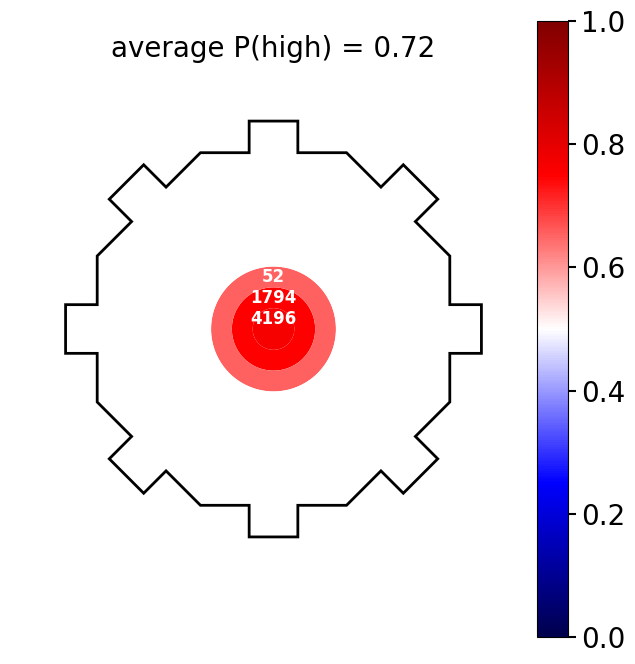

In [302]:
plot_heatmap_phigh_circular(probabilities_low[0], radial_bins, bin_counts=bins_wall_seen[0],
                                 cmap_name='seismic', diff_cmap_name='PiYG', title=title5)

In [303]:
title6=np.round(np.nanmean(probabilities_low[1]),2)

/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_1173/3647730139.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


(<Figure size 800x800 with 2 Axes>,
 <Axes: title={'center': 'average P(high) = 0.37'}>)

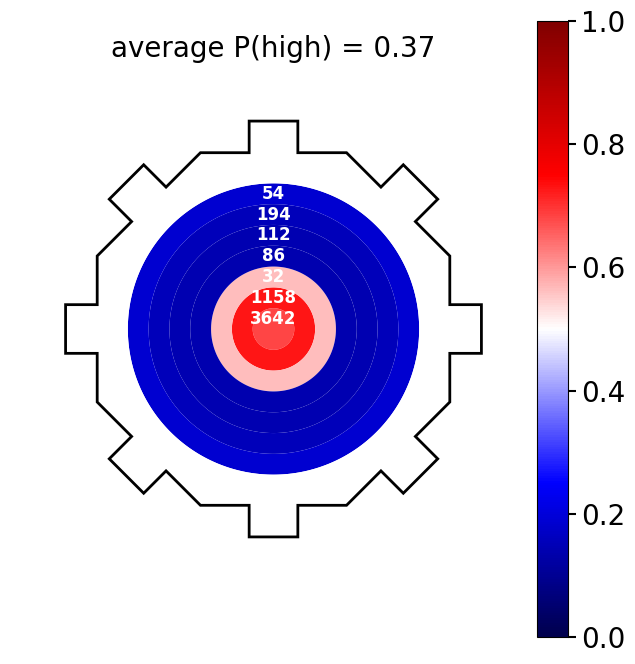

In [304]:
plot_heatmap_phigh_circular(probabilities_low[1], radial_bins, bin_counts=bins_wall_seen[1],
                                 cmap_name='seismic', diff_cmap_name='PiYG', title=title6)

In [305]:
title7=np.round(np.nanmean(probabilities_low[2]),2)

/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_1173/2938385296.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


(<Figure size 800x800 with 2 Axes>,
 <Axes: title={'center': 'average P(high) = 0.76'}>)

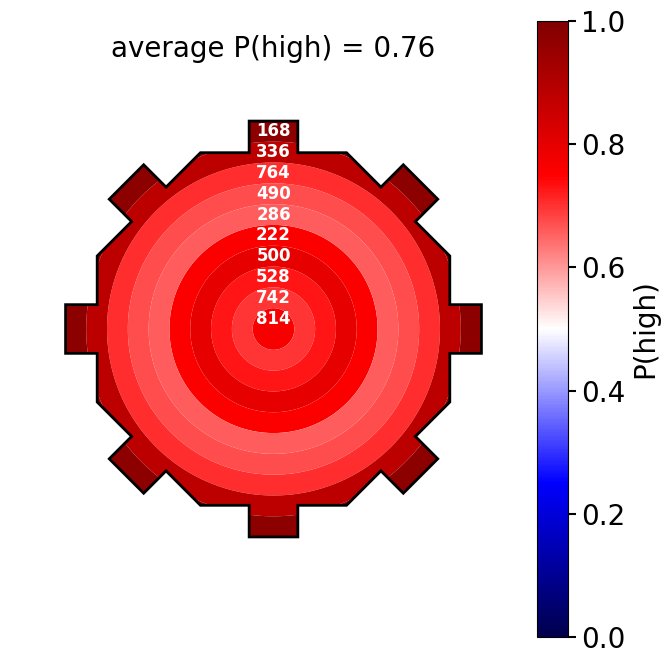

In [316]:
plot_heatmap_phigh_circular(probabilities_low[2], radial_bins, bin_counts=bins_wall_seen[2],
                                 cmap_name='seismic', diff_cmap_name='PiYG', title=title7)

In [307]:
title8=np.round(np.nanmean(probabilities_low[3]),2)

/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_1173/2938385296.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


(<Figure size 800x800 with 2 Axes>,
 <Axes: title={'center': 'average P(high) = 0.69'}>)

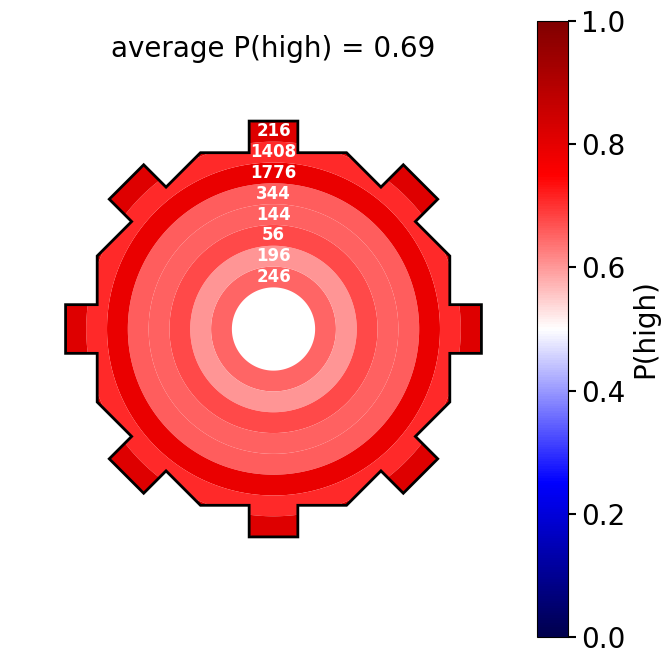

In [317]:
plot_heatmap_phigh_circular(probabilities_low[3], radial_bins, bin_counts=bins_wall_seen[3],
                                 cmap_name='seismic', diff_cmap_name='PiYG', title=title8)

## Difference plots

In [321]:
probabilities_diff = []
for i in range(len(probabilities_high)):
    diff = probabilities_high[i] - probabilities_low[i]
    probabilities_diff.append(diff)

high first seen - low first seen

In [214]:
def plot_heatmap_phigh_circular(probabilities, radial_bins, 
                                 cmap_name='inferno', diff_cmap_name='PiYG'):
    ''' Plot a heatmap of P(Choose High) across circular bins overlaid on octagon
     
        probabilities: 1D array of probabilities across radial bins
        radial_bins: bin edges for radial distance
        n_angular_bins: number of angular bins (default 8 for octagon)
    '''
    

    octagon_vertex_coordinates = plot_octagon.return_octagon_path_points()
    
    fig, ax = plt.subplots(figsize=(8, 8))
    
    cmap = cm.get_cmap(cmap_name)
    cmap.set_bad(color='white')
    
    # Normalize probabilities to 0-1
    norm = mpl.colors.Normalize(vmin=-1, vmax=1)
    
    # Plot each bin as a rectangle in Cartesian coordinates
# Create octagon clip path, but do not add it visibly yet
    octagon_clip = Polygon(
        octagon_vertex_coordinates,
        closed=True,
        facecolor='none',
        edgecolor='none',
        transform=ax.transData
    )

    for i in range(len(radial_bins) - 1):
        r_inner = radial_bins[i]
        r_outer = radial_bins[i + 1]

        theta = np.linspace(0, 2*np.pi, 500)

        x_outer = r_outer * np.cos(theta)
        y_outer = r_outer * np.sin(theta)

        x_inner = r_inner * np.cos(theta[::-1])
        y_inner = r_inner * np.sin(theta[::-1])

        vertices = np.column_stack([
            np.concatenate([x_outer, x_inner]),
            np.concatenate([y_outer, y_inner])
        ])

        color = cmap(norm(probabilities[i]))

        patch = Polygon(
            vertices, 
            facecolor=color, 
            edgecolor='black', 
            linewidth=0, 
            antialiased=True)

        # This is the key line
        patch.set_clip_path(octagon_clip)

        ax.add_patch(patch)
    
    
    # Overlay octagon outline
    octagon_patch = Polygon(
    octagon_vertex_coordinates,
    closed=True,
    edgecolor='black',
    facecolor='none',
    lw=2
    )   
    ax.add_patch(octagon_patch)

    
    ax.set_xlim([-25, 25])
    ax.set_ylim([-25, 25])
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    # Add colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, pad=0.1, shrink=0.5)


low step penalty

/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_1173/3322557042.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


(<Figure size 800x800 with 2 Axes>,
 <Axes: title={'center': 'average ΔP(high) = 0.28'}>)

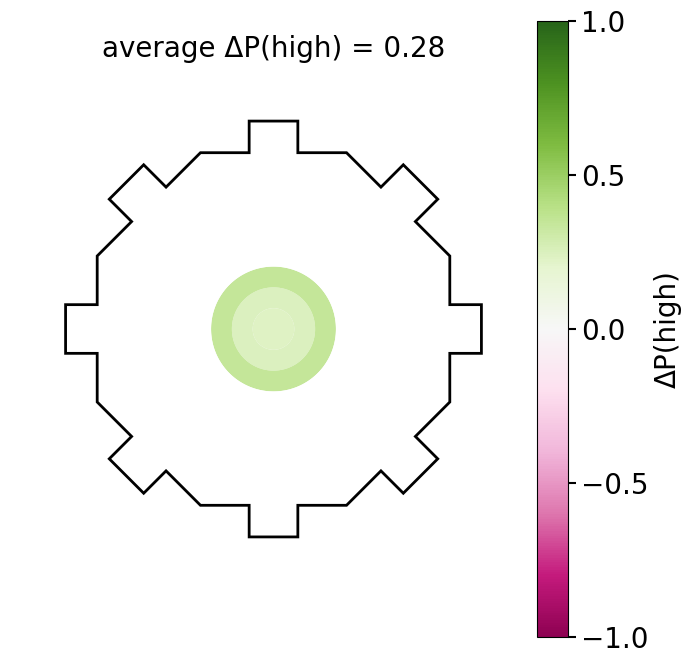

In [335]:
plot_heatmap_phigh_circular(probabilities_diff[0], radial_bins, 
                                 cmap_name='PiYG', diff_cmap_name='PiYG', title= np.round(np.nanmean(probabilities_diff[0]),2), diff=True)

low step penalty

/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_1173/3322557042.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


(<Figure size 800x800 with 2 Axes>,
 <Axes: title={'center': 'average ΔP(high) = 0.51'}>)

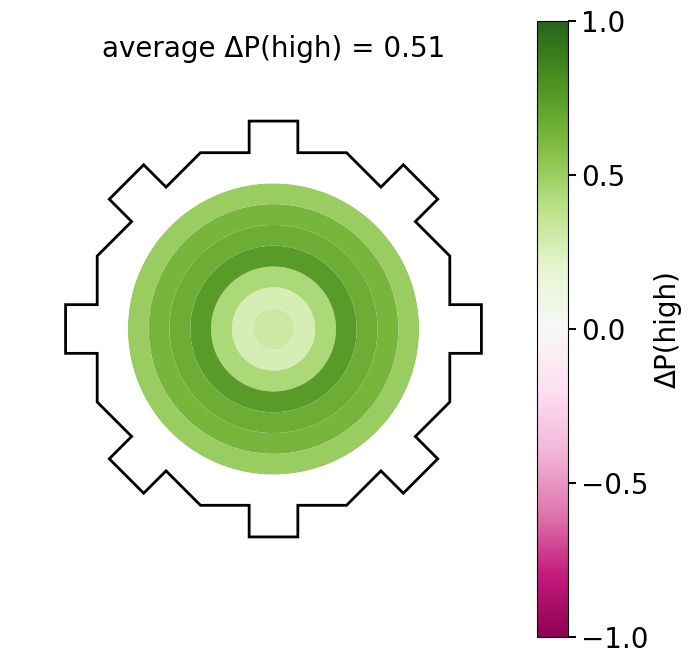

In [336]:
plot_heatmap_phigh_circular(probabilities_diff[1], radial_bins, 
                                 cmap_name='PiYG', diff_cmap_name='PiYG', title= np.round(np.nanmean(probabilities_diff[1]),2), diff=True)

mid-high step penalty

/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_1173/3322557042.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


(<Figure size 800x800 with 2 Axes>,
 <Axes: title={'center': 'average ΔP(high) = 0.19'}>)

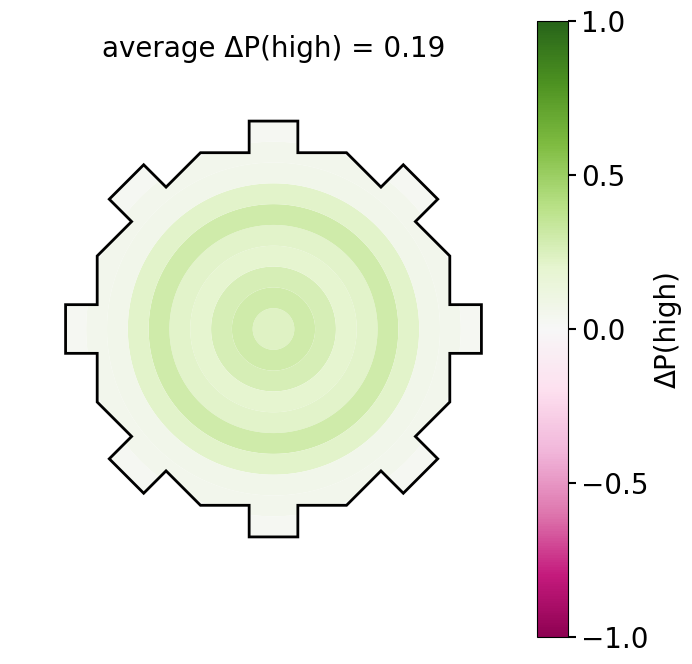

In [337]:
plot_heatmap_phigh_circular(probabilities_diff[2], radial_bins, 
                                 cmap_name='PiYG', diff_cmap_name='PiYG', title= np.round(np.nanmean(probabilities_diff[2]),2), diff=True)

high step penalty

/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_1173/3322557042.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


(<Figure size 800x800 with 2 Axes>,
 <Axes: title={'center': 'average ΔP(high) = 0.15'}>)

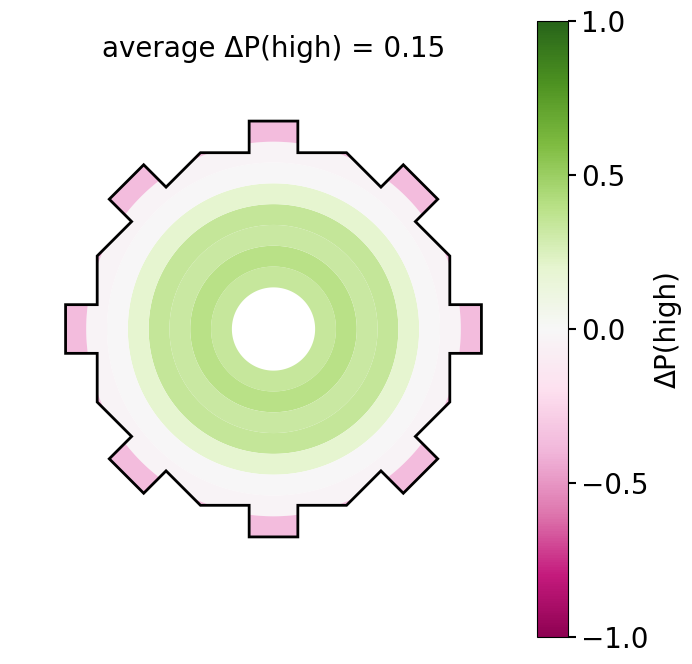

In [338]:
plot_heatmap_phigh_circular(probabilities_diff[3], radial_bins, 
                                 cmap_name='PiYG', diff_cmap_name='PiYG', title= np.round(np.nanmean(probabilities_diff[3]),2), diff=True)

# First-seen effect by wall separation (for each step penalty group)

we want P(Low | Low first visible) in violin plots first across low, medium, high step penalty groups and then split again by wall separation - for the latter I will need to filter the trial lists again before feeding to heatmap_phigh function

I need P(Low | Low first visible) for each session in each group

In [339]:
num_players = 1
first_visible_wall_index = 1
chosen_wall_index = 1

low sp

In [341]:
(trial_list_low_vis_filtered_9,
  trial_list_low_vis_and_choice_filtered_9) = heatmap_phigh.filter_pipeline_p_high_first_seen_wall(low_lists,
                                                                        num_players,
                                                                        first_visible_wall_index,
                                                                        chosen_wall_index)

filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[1. 0. 1. 0. 1. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 0. 1. 1.
 0. 1. 1. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 1. 0. 1. 0. 1. 0. 0. 0. 0. 0.
 1. 0. 1. 1. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 1. 1. 1. 0. 0. 0. 1. 0. 0. 1.
 0. 0. 0. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1. 0. 0. 1. 1. 1. 0. 1. 0. 1. 0. 0.
 0. 0. 0. 0. 1. 1. 1. 0. 0. 1. 1. 0. 0. 0. 0. 1. 0. 1. 0. 0. 1. 0. 0. 0.
 1. 1. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 1. 0. 1. 1. 1. 1. 1. 0. 1. 1. 0. 1.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 1. 0. 1. 0. 1.
 0. 0. 0. 0. 0. 1. 0. 1. 1. 0. 0. 1. 0. 0. 1. 0. 0. 0. 1. 1. 0. 0. 0. 1.
 1. 1. 1. 0. 0. 0. 1. 0. 0. 1. 0. 1. 1. 1. 0. 1. 0. 0. 1. 0. 1. 1. 0. 1.
 1. 1. 0. 1. 0. 1. 1. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 1.
 0. 0. 0. 1. 0. 0. 1. 1. 1. 0. 0. 0. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1. 0.
 1. 0. 1. 1. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0.
 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 

medium sp

In [343]:
(trial_list_low_vis_filtered_10,
  trial_list_low_vis_and_choice_filtered_10) = heatmap_phigh.filter_pipeline_p_high_first_seen_wall(mid_low_lists,
                                                                        num_players,
                                                                        first_visible_wall_index,
                                                                        chosen_wall_index)

filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[1. 0. 0. 0. 1. 1. 0. 1. 0. 1. 0. 0. 0. 1. 0. 1. 0. 0. 0. 1. 0. 1. 0. 0.
 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 1. 1. 1. 1. 0. 1. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 1. 0. 1. 1. 0.
 0. 0. 0. 0. 1. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 1.
 0. 0. 0. 1. 1. 0. 1. 1. 0. 1. 0. 1. 0. 0. 1. 0. 0. 1. 0. 0. 1. 1. 0. 0.
 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 1. 1. 0. 0.
 0. 1. 1. 1. 1. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 1. 0. 1. 0. 1. 0. 0.
 0. 1. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 1. 0. 1. 1. 1. 0. 1. 1. 0.
 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 1. 0. 1. 1. 0. 0. 1. 1. 0. 0.
 1. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0.
 0. 1. 1. 1. 0. 0. 0. 1. 0. 1. 0. 0. 0. 1. 1. 1. 1. 0. 0. 0. 0. 0. 1. 0.
 0. 0. 0. 0. 1. 0. 1. 1. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 1. 1. 0. 0. 1. 1.
 0. 0. 1. 1. 1. 0. 0. 1. 0. 0. 1. 0. 

medium high sp

In [344]:
(trial_list_low_vis_filtered_11,
  trial_list_low_vis_and_choice_filtered_11) = heatmap_phigh.filter_pipeline_p_high_first_seen_wall(mid_high_lists,
                                                                        num_players,
                                                                        first_visible_wall_index,
                                                                        chosen_wall_index)

filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[0. 0. 0. 1. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.
 0. 0. 1. 0. 0. 0. 0. 1. 0. 1. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.
 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 1. 1. 0. 1. 1. 1. 0. 1. 0. 0. 0.
 1. 0. 0. 1. 0. 1. 1. 0. 1. 0. 0. 0. 1. 1. 1. 0. 1. 1. 1. 0. 0. 1. 1. 0.
 1. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 1. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 1. 0. 1. 0. 0. 0. 0. 0. 1. 1. 0. 1. 0.
 0. 0. 0. 0. 1. 0. 0. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1. 0. 0. 0. 1. 0. 1. 0.
 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 1. 0. 0. 0. 0. 0.
 0. 1. 0. 0. 1. 1. 0. 0. 1. 0. 1. 1. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 1. 0.
 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 1. 0. 0. 1. 1. 0. 0. 1. 1. 1. 0. 0. 0.
 0. 1. 0. 1. 1. 0. 0. 0. 0. 0. 1. 1. 0. 1. 0. 0. 1. 1. 0. 0. 1. 0. 1. 0.
 0. 0. 0. 0. 0. 1. 0. 0. 1. 1. 0. 0. 0. 0. 0. 1. 0. 1. 1. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 0. 0. 

high sp

In [345]:
(trial_list_low_vis_filtered_12,
  trial_list_low_vis_and_choice_filtered_12) = heatmap_phigh.filter_pipeline_p_high_first_seen_wall(high_lists,
                                                                        num_players,
                                                                        first_visible_wall_index,
                                                                        chosen_wall_index)

filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[0. 1. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 1. 1. 0.
 1. 1. 1. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 1. 1. 0. 0. 0. 0. 1. 1. 1. 0.
 1. 0. 0. 1. 0. 0. 0. 1. 1. 1. 0. 0. 0. 0. 1. 1. 0. 1. 1. 0. 0. 0. 0. 0.
 0. 1. 1. 1. 1. 1. 1. 0. 0. 1. 1. 0. 1. 0. 0. 0. 1. 0. 1. 1. 0. 0. 1. 1.
 0. 1. 0. 0. 1. 1. 0. 0. 0. 1. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 1. 0. 0. 1.
 1. 0. 1. 0. 1. 0. 1. 0. 1. 1. 1. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0.
 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 1. 1. 0. 0. 0. 0. 1. 1. 0. 0. 0.
 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 1. 0. 1. 0.
 0. 1. 0. 1. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 1.
 0. 0. 1. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 1. 1. 0. 1. 1. 1. 0. 1. 1. 0. 0.
 1. 0. 1. 1. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 1. 0. 0.
 0. 1. 0. 0. 1. 1. 0. 1. 0. 1. 0. 1. 0. 0. 0. 0. 1. 0. 1. 0. 0. 1. 1. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 

In [358]:
p_low_q1_lists = []
p_low_q2_lists = []
p_low_q3_lists = []
p_low_q4_lists = []

for session_id in range(len(low_lists)):
    p_low_q1 = len(trial_list_low_vis_and_choice_filtered_9[0][session_id]) / len(low_lists[session_id])
    p_low_q1_lists.append(p_low_q1)

for session_id in range(len(mid_low_lists)):
    p_low_q2 = len(trial_list_low_vis_and_choice_filtered_10[0][session_id]) / len(mid_low_lists[session_id])
    p_low_q2_lists.append(p_low_q2)

for session_id in range(len(mid_high_lists)):
    p_low_q3 = len(trial_list_low_vis_and_choice_filtered_11[0][session_id]) / len(mid_high_lists[session_id])
    p_low_q3_lists.append(p_low_q3)

for session_id in range(len(high_lists)):
    p_low_q4 = len(trial_list_low_vis_and_choice_filtered_12[0][session_id]) / len(high_lists[session_id])
    p_low_q4_lists.append(p_low_q4)

In [359]:
mean_p_low = []
sem_p_low = []
std_p_low = []

groups = [
    p_low_q1_lists,
    p_low_q2_lists,
    p_low_q3_lists,
    p_low_q4_lists
]

for group in groups:
    group = np.array(group)

    mean_p_low.append(np.nanmean(group))
    sem_p_low.append(np.nanstd(group) / np.sqrt(np.sum(~np.isnan(group))))
    std_p_low.append(np.nanstd(group))

In [360]:
q1_group = np.array(p_low_q1_lists)
q2_group = np.array(p_low_q2_lists)
q3_group = np.array(p_low_q3_lists)
q4_group = np.array(p_low_q4_lists)

data = [
    q1_group,
    q2_group,
    q3_group,
    q4_group
]

In [361]:
# overall
stat, p = kruskal(q1_group, q2_group, q3_group, q4_group)
print("Kruskal-Wallis p =", p)

# pairwise
p_q1_q2 = mannwhitneyu(q1_group, q2_group).pvalue
p_q2_q3 = mannwhitneyu(q2_group, q3_group).pvalue
p_q3_q4 = mannwhitneyu(q3_group, q4_group).pvalue
p_q1_q3 = mannwhitneyu(q1_group, q3_group).pvalue
p_q2_q4 = mannwhitneyu(q2_group, q4_group).pvalue
p_q1_q4 = mannwhitneyu(q1_group, q4_group).pvalue

Kruskal-Wallis p = 0.05177801536659149


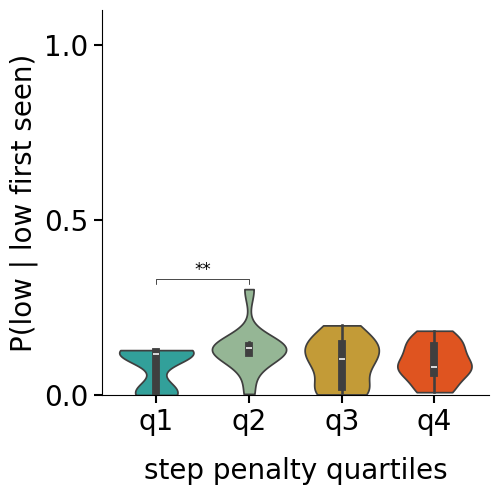

In [371]:
#alette = sns.color_palette("tab20b", 4)
palette = ["lightseagreen", "darkseagreen", "goldenrod", "orangered"]

plt.figure(figsize=(5, 5))

sns.violinplot(data=data, palette=palette, cut=0)

plt.xticks(
    [0, 1, 2, 3],
    ['q1', 'q2', 'q3', 'q4'],
    fontsize=13
)
plt.ylim(0,1.1)
plt.yticks(np.arange(0, 1.1, 0.5), fontsize=20)
plt.ylabel("P(low | low first seen)", fontsize=20)
plt.xlabel("step penalty quartiles", fontsize=20, labelpad=15)
plt.xticks([0, 1, 2, 3], ['q1', 'q2', 'q3', 'q4'], fontsize=20)

sns.despine(top=True, right=True)

ax = plt.gca()
ax.tick_params(width=1.5, length=6)

y_max = np.nanmax([np.nanmax(group) for group in data])
h = y_max * 0.05

#add_sig_bar(ax, 0, 1, y_max + h, h, p_q1_q2)
#add_sig_bar(ax, 1, 2, y_max + 3*h, h, p_q2_q3)
#add_sig_bar(ax, 2, 3, y_max + 5*h, h, p_q3_q4)

# optional broader comparisons
#add_sig_bar(ax, 0, 2, y_max + 7*h, h, p_q1_q3)
#add_sig_bar(ax, 1, 3, y_max + 9*h, h, p_q2_q4)
#add_sig_bar(ax, 0, 3, y_max + 11*h, h, p_q1_q4)

plt.show()

### let's now split by wall separation

In [372]:
num_players = 1
first_visible_wall_index = 1
chosen_wall_index = 1

In [374]:
trial_lists_sep1 = []
trial_lists_sep2 = []
trial_lists_sep4 = []

for session_id in range(len(trial_lists)):
    player_data = analysis_results[session_id]
    trial_lists_sep1.append(player_data['trial_lists']['wall_sep_1'])
    trial_lists_sep2.append(player_data['trial_lists']['wall_sep_2'])
    trial_lists_sep4.append(player_data['trial_lists']['wall_sep_4'])

In [375]:
penalties = np.array(step_penalties)

low_thresh = np.percentile(penalties, 25)
mid_thresh = np.percentile(penalties, 50)
high_thresh = np.percentile(penalties, 75)

In [376]:
# sep1
low_lists_sep1 = []
mid_low_lists_sep1 = []
mid_high_lists_sep1 = []
high_lists_sep1 = []

# sep2
low_lists_sep2 = []
mid_low_lists_sep2 = []
mid_high_lists_sep2 = []
high_lists_sep2 = []

# sep4
low_lists_sep4 = []
mid_low_lists_sep4 = []
mid_high_lists_sep4 = []
high_lists_sep4 = []

In [377]:
for penalty, trial_list in zip(step_penalties, trial_lists_sep1):

    if penalty <= low_thresh:
        low_lists_sep1.append(trial_list)

    elif penalty <= mid_thresh:
        mid_low_lists_sep1.append(trial_list)

    elif penalty <= high_thresh:
        mid_high_lists_sep1.append(trial_list)

    else:
        high_lists_sep1.append(trial_list)

In [378]:
for penalty, trial_list in zip(step_penalties, trial_lists_sep2):

    if penalty <= low_thresh:
        low_lists_sep2.append(trial_list)

    elif penalty <= mid_thresh:
        mid_low_lists_sep2.append(trial_list)

    elif penalty <= high_thresh:
        mid_high_lists_sep2.append(trial_list)

    else:
        high_lists_sep2.append(trial_list)

In [379]:
for penalty, trial_list in zip(step_penalties, trial_lists_sep4):

    if penalty <= low_thresh:
        low_lists_sep4.append(trial_list)

    elif penalty <= mid_thresh:
        mid_low_lists_sep4.append(trial_list)

    elif penalty <= high_thresh:
        mid_high_lists_sep4.append(trial_list)

    else:
        high_lists_sep4.append(trial_list)

### starting with wall sep 1

low sp

In [380]:
(trial_list_low_vis_filtered_13,
  trial_list_low_vis_and_choice_filtered_13) = heatmap_phigh.filter_pipeline_p_high_first_seen_wall(low_lists_sep1,
                                                                        num_players,
                                                                        first_visible_wall_index,
                                                                        chosen_wall_index)

filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[0. 1. 0. 1. 0. 0. 1. 0. 0. 0. 0. 1. 1. 0. 1. 0. 0. 0. 0. 1. 0. 0. 1. 1.
 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 1. 0. 0. 0. 1. 0. 0. 1. 0.
 1. 0. 0. 0. 0. 0. 1. 1. 0. 1. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 1. 1. 1. 0.
 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 1. 1. 0. 0. 0. 0. 0. 1. 0. 1. 0. 1. 1. 1. 1. 0. 1. 0. 1. 1. 0. 0.
 0. 0. 0. 1. 0. 1. 0. 1. 0. 0. 1. 0. 0. 0. 1. 0. 0. 1. 1. 0. 0. 0. 0. 1.
 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0.
 0. 0. 0. 0. 0. 1. 0. 1. 0. 1. 0. 0. 0. 0. 1. 0. 1. 0. 0. 1. 0. 1. 1. 0.
 0. 1. 0. 1. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 0. 0. 1. 1. 0.
 0. 1. 0. 0. 1. 1. 0. 1. 1. 0. 0. 1. 0. 0. 0. 1. 0. 1. 0. 1. 0. 0. 0. 0.
 0. 0. 0. 1. 0. 1. 1. 0. 0. 0. 0. 1. 0. 1. 0. 1. 1. 0. 1. 0. 0. 0. 1. 1.
 0. 1. 1. 0. 1. 1. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0.]
And the number of valid trials at th

medium sp

In [381]:
(trial_list_low_vis_filtered_14,
  trial_list_low_vis_and_choice_filtered_14) = heatmap_phigh.filter_pipeline_p_high_first_seen_wall(mid_low_lists_sep1,
                                                                        num_players,
                                                                        first_visible_wall_index,
                                                                        chosen_wall_index)

filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[1. 0. 0. 0. 1. 0. 1. 0. 0. 1. 0. 1. 0. 0. 0. 0. 1. 0. 0. 1. 1. 0. 0. 0.
 1. 1. 1. 1. 0. 1. 1. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.
 0. 1. 1. 0. 1. 0. 0. 1. 1. 0. 0. 1. 1. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0.
 0. 1. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 1. 1. 1. 0. 0. 1. 0.
 0. 0. 1. 0. 0. 0. 0. 1. 1. 0. 0. 0. 1. 0. 0. 0. 1. 1. 0. 0. 0. 0. 1. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 1. 0. 0. 1. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1.
 1. 0. 0. 0. 0. 0. 1. 0. 0. 1. 1. 0. 1. 0. 0. 1. 1. 0. 0. 0. 1. 0. 0. 0.
 0. 0. 0. 0. 0. 1. 1. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0.
 0. 1. 0. 1. 1. 0. 1. 0. 0. 0. 0. 0. 1. 1. 1. 0. 0. 0. 0. 1. 0. 1. 0. 1.
 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0.
 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 1. 

medium-high sp

In [382]:
(trial_list_low_vis_filtered_15,
  trial_list_low_vis_and_choice_filtered_15) = heatmap_phigh.filter_pipeline_p_high_first_seen_wall(mid_high_lists_sep1,
                                                                        num_players,
                                                                        first_visible_wall_index,
                                                                        chosen_wall_index)

filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 0.
 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 1. 0. 1. 0. 0. 1. 0. 0. 1. 1. 1. 1. 0.
 1. 0. 1. 0. 0. 1. 0. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.
 0. 0. 0. 0. 0. 1. 0. 1. 0. 1. 0. 1. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0.
 0. 1. 1. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 1. 0. 1. 1. 1. 0.
 0. 0. 1. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 1.
 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 1. 1. 0. 1. 0. 0. 0. 1. 0.
 0. 0. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 1. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.
 1. 0. 0. 0. 0. 1. 0. 0. 1. 0. 1. 1. 0. 0. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1.
 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 1. 0. 0. 0. 0. 1. 0. 0. 1.
 0. 0. 1. 0. 0. 0. 0. 1. 1. 1. 0. 1. 0. 1. 0. 0. 0. 1. 1. 0. 1. 1. 0. 0.
 1. 0. 0. 1. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 1. 1.
 0. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 

high sp

In [383]:
(trial_list_low_vis_filtered_16,
  trial_list_low_vis_and_choice_filtered_16) = heatmap_phigh.filter_pipeline_p_high_first_seen_wall(high_lists_sep1,
                                                                        num_players,
                                                                        first_visible_wall_index,
                                                                        chosen_wall_index)

filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 1. 0. 0. 1. 0. 1. 0. 1. 0. 1. 0. 0. 0.
 0. 0. 0. 0. 1. 0. 1. 1. 1. 0. 1. 0. 1. 0. 1. 0. 1. 1. 0. 0. 1. 0. 0. 0.
 0. 1. 1. 0. 1. 1. 0. 1. 0. 0. 0. 1. 0. 1. 1. 0. 1. 0. 0. 0. 0. 0. 1. 0.
 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 1. 1. 0. 0. 1. 0. 1.
 0. 1. 1. 0. 0. 0. 0. 1. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 0. 0. 1. 0. 1. 0.
 1. 0. 0. 0. 0. 1. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.
 0. 1. 0. 1. 1. 0. 0. 1. 1. 0. 1. 1. 1. 0. 0. 1. 0. 1. 0. 0. 1. 0. 0. 0.
 0. 0. 0. 0. 1. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0. 1. 1. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 1. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0.]
And the number of valid trials at this step is 76
filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[1. 1. 0. 1. 1. 0. 0. 0. 0. 1. 0. 1. 0. 1. 1. 0. 0. 1. 1. 0. 0. 0. 0. 0.
 0. 0. 1. 0

### then sep 2

low sp

In [384]:
(trial_list_low_vis_filtered_17,
  trial_list_low_vis_and_choice_filtered_17) = heatmap_phigh.filter_pipeline_p_high_first_seen_wall(low_lists_sep2,
                                                                        num_players,
                                                                        first_visible_wall_index,
                                                                        chosen_wall_index)

filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[1. 0. 1. 0. 1. 0. 0. 0. 1. 0. 1. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1.
 0. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 1. 0. 1. 1.
 1. 1. 0. 0. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 1. 0. 1. 0. 0. 0.
 1. 0. 1. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 1. 0. 0.
 1. 1. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 1. 1. 0. 1. 0. 1. 0. 0. 1. 0. 0. 1.
 0. 0. 0. 1. 0. 0. 0. 1. 0. 1. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0.
 0. 0. 0. 0. 1. 0. 1. 1. 0.]
And the number of valid trials at this step is 59
filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[1. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 0. 1. 0. 0. 0. 0. 1. 0.
 1. 1. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 1. 1. 0. 0. 0. 1. 0. 0. 1. 1.
 0. 0. 0. 1. 0. 1. 0. 0. 0. 1. 0. 1. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0.
 0. 1. 0. 0. 1. 1. 0. 0. 0. 0. 1. 0. 1. 1. 1. 1. 0. 1. 0. 0. 0. 0. 1. 0.
 0. 1. 0. 1. 0. 0

medium sp

In [385]:
(trial_list_low_vis_filtered_18,
  trial_list_low_vis_and_choice_filtered_18) = heatmap_phigh.filter_pipeline_p_high_first_seen_wall(mid_low_lists_sep2,
                                                                        num_players,
                                                                        first_visible_wall_index,
                                                                        chosen_wall_index)

filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 1. 0. 1. 1. 1. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 1.
 0. 1. 1. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0.
 1. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 1. 0. 1. 1. 0. 0. 0. 1. 0. 0. 0. 1. 1.
 1. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 1. 1. 1. 1. 0. 0. 0. 1. 1. 0. 1. 0. 1.
 0. 0. 1. 1. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 1. 0. 0. 1. 0. 1.
 1. 0. 1. 1. 1. 0. 1. 0. 0. 1. 0. 1. 1. 1. 1. 0. 0. 1. 1. 0. 0. 0. 0. 0.
 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 1. 0. 1. 0. 1. 0. 1. 0. 0. 1. 0. 0. 1. 0.
 0. 0. 1. 0. 0. 1. 0. 1. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.
 1. 1. 0. 0. 1. 0. 0. 0. 0. 0.]
And the number of valid trials at this step is 82
filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[0. 0. 1. 0. 0

medium-high sp

In [386]:
(trial_list_low_vis_filtered_19,
  trial_list_low_vis_and_choice_filtered_19) = heatmap_phigh.filter_pipeline_p_high_first_seen_wall(mid_high_lists_sep2,
                                                                        num_players,
                                                                        first_visible_wall_index,
                                                                        chosen_wall_index)

filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[0. 1. 0. 0. 0. 0. 1. 1. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 1. 1. 0. 1. 1.
 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.
 1. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 1. 0. 0. 1. 1. 1. 1. 0. 0. 1. 1. 0. 0.
 0. 0. 0. 1. 0. 0. 0. 1. 1. 0. 1. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.
 1. 1. 0. 1. 1. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 1. 0. 1. 0.
 1. 0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 1. 0. 1. 1. 0. 0. 1. 0. 1. 1. 1. 1. 0.
 1. 0.]
And the number of valid trials at this step is 52
filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[1. 0. 0. 1. 1. 0. 1. 1. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 1. 1. 0. 1. 0. 1.
 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 1. 0. 1. 1. 0. 0. 0. 0. 1. 0. 1. 0. 1. 1.
 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 1. 0. 1. 0. 1. 1. 0. 1. 0. 1. 0. 0. 0. 1.
 1. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 0. 1. 0. 0. 1. 0. 0. 0. 1. 0. 1. 1.
 0. 0. 0. 0. 1. 1. 1. 1. 0. 0. 1. 1. 1

high sp

In [387]:
(trial_list_low_vis_filtered_20,
  trial_list_low_vis_and_choice_filtered_20) = heatmap_phigh.filter_pipeline_p_high_first_seen_wall(high_lists_sep2,
                                                                        num_players,
                                                                        first_visible_wall_index,
                                                                        chosen_wall_index)

filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[1. 0. 1. 0. 0. 0. 0. 1. 1. 1. 0. 0. 1. 0. 1. 1. 0. 0. 1. 1. 0. 1. 0. 1.
 0. 0. 0. 0. 1. 0. 1. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.
 0. 1. 0. 0. 1. 0. 0. 0. 1. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 1. 0.
 1. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 1. 0. 0. 0. 0.
 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 1. 1.
 1. 1. 0. 1. 1. 0.]
And the number of valid trials at this step is 43
filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 1. 0. 0. 1. 0. 1. 0. 0. 1. 0. 1. 1. 0. 0.
 1. 0. 1. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 1.
 0. 1. 0. 1. 1. 1. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 1. 1. 0. 1. 0. 0. 1. 0.
 1. 0. 0. 1. 1. 0. 1. 0. 1. 0. 0. 1. 0. 1. 1. 0. 1. 0. 0. 0. 0. 0. 1. 1.
 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 1. 0. 1. 1. 0. 0. 0. 0. 0. 1. 1. 1.
 0. 0. 1. 0. 1. 0. 0. 0. 0

### and finally sep 4

low sp

In [388]:
(trial_list_low_vis_filtered_21,
  trial_list_low_vis_and_choice_filtered_21) = heatmap_phigh.filter_pipeline_p_high_first_seen_wall(low_lists_sep4,
                                                                        num_players,
                                                                        first_visible_wall_index,
                                                                        chosen_wall_index)

filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[0. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 1. 1. 0. 1. 0. 0. 1. 0. 0. 1. 0. 1.
 0. 0. 0. 0. 1. 1. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 0. 1. 1. 1. 1. 0. 1. 0.
 1. 0. 0. 1. 0. 0. 1. 0. 1. 1. 1. 1. 1. 0. 0. 0. 0. 1. 0. 1. 0. 0. 1. 0.
 0. 0. 1. 1. 1. 1. 0. 1. 0. 1. 1. 1. 1. 0. 1. 0. 0. 0. 0. 1. 0. 1. 0. 1.
 1. 0. 0. 0. 1. 1. 1. 1. 0. 0. 1. 0. 1. 0. 1. 0. 0. 0. 0. 1. 1. 1. 1. 0.
 1. 1. 1. 0. 1. 0. 1.]
And the number of valid trials at this step is 67
filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[0. 0. 0. 0. 0. 1. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0.
 1. 1. 1. 0. 1. 1. 0. 1. 1. 0. 0. 1. 0. 1. 1. 0. 1. 0. 1. 0. 0. 0. 0. 0.
 0. 0. 1. 1. 0. 0. 1. 0. 0. 0. 0. 1. 0. 1. 1. 0. 0. 0. 1. 1. 1. 1. 1. 1.
 1. 1. 0. 1. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 0. 0. 0. 0.
 0. 0. 1. 0. 1. 0. 0. 1. 1. 1. 1. 1. 0. 0. 0. 1. 0. 1. 1. 0. 0. 1. 0. 0.
 1. 1. 0. 1. 1. 0. 0.]


medium sp

In [389]:
(trial_list_low_vis_filtered_22,
  trial_list_low_vis_and_choice_filtered_22) = heatmap_phigh.filter_pipeline_p_high_first_seen_wall(mid_low_lists_sep4,
                                                                        num_players,
                                                                        first_visible_wall_index,
                                                                        chosen_wall_index)

filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[0. 1. 1. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0.
 0. 0. 1. 1. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 0.
 1. 0. 1. 1. 0. 1. 0. 0. 0. 1. 1. 0. 0. 1. 0. 0. 1. 0. 0. 1. 1. 0. 1. 0.
 1. 1. 1. 1. 0. 1. 0. 1. 0. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 0. 0. 1. 1. 0.
 1. 0. 1. 1. 1. 1. 0. 1. 1. 1. 1. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 1. 1. 0.
 0. 0. 1. 0. 1. 1. 1. 1. 0. 1. 0. 0. 0. 0. 0. 1. 1. 1. 0. 0. 0. 1. 0. 1.
 1. 0. 1. 0. 0. 0. 0. 0. 0. 1. 1. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 1. 1. 0.
 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 1. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 0. 0. 1.
 1. 0. 1. 1. 1. 0. 0. 1. 1. 0. 0. 1. 0. 1. 0. 0. 0. 1. 0. 1. 1. 0. 1. 1.
 1. 1. 1. 1. 0. 1. 0. 1. 0. 1. 0. 0. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0.
 1. 1. 0. 0. 1. 1. 1. 0. 0. 1. 0. 0. 1. 1. 1. 1. 0.]
And the number of valid trials at this step is 121
filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session

medium-high sp

In [390]:
(trial_list_low_vis_filtered_23,
  trial_list_low_vis_and_choice_filtered_23) = heatmap_phigh.filter_pipeline_p_high_first_seen_wall(mid_high_lists_sep4,
                                                                        num_players,
                                                                        first_visible_wall_index,
                                                                        chosen_wall_index)

filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 1. 1. 0. 0. 1. 0. 1. 1. 1. 0. 0.
 0. 0. 0. 0. 1. 1. 1. 0. 0. 0. 1. 1. 0. 1. 1. 1. 1. 0. 0. 0. 1. 0. 0. 1.
 0. 1. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 1. 1. 0. 0. 1. 0. 1. 0. 0. 1.
 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 1. 0. 1. 1. 0. 1.
 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 1. 0. 0. 0. 0.]
And the number of valid trials at this step is 41
filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[0. 0. 0. 1. 0. 1. 0. 1. 1. 0. 0. 1. 1. 0. 1. 0. 0. 1. 0. 0. 1. 0. 1. 1.
 0. 1. 0. 0. 0. 1. 1. 1. 1. 0. 1. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 1. 0. 0.
 1. 1. 1. 0. 1. 0. 0. 0. 1. 0. 1. 1. 1. 0. 1. 1. 0. 0. 0. 0. 1. 0. 0. 0.
 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 1. 1. 0. 0. 1. 0. 0. 1. 1. 1. 0. 0. 1.
 0. 1. 1. 0. 0. 0. 1. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1.
 1. 1. 0. 1. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 1. 1. 1. 0. 1.

high sp

In [391]:
(trial_list_low_vis_filtered_24,
  trial_list_low_vis_and_choice_filtered_24) = heatmap_phigh.filter_pipeline_p_high_first_seen_wall(high_lists_sep4,
                                                                        num_players,
                                                                        first_visible_wall_index,
                                                                        chosen_wall_index)

filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 0. 0. 0. 1. 0. 0. 1. 1. 1. 1.
 1. 0. 0. 0. 0. 1. 1. 0. 1. 0. 0. 1. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 1.
 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0. 1. 1. 0. 0.
 1. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 1.
 1. 0. 0. 0. 1. 0. 1. 0. 1. 0. 1. 0. 0. 0. 1. 1. 1. 0.]
And the number of valid trials at this step is 41
filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[0. 0. 0. 1. 0. 1. 0. 0. 0. 1. 1. 1. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 1.
 1. 0. 0. 0. 1. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 0. 0. 1. 1.
 1. 0. 1. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1. 0. 0. 1. 1. 0. 0. 1. 0. 1. 1.
 0. 1. 0. 0. 1. 0. 0. 1. 1. 1. 1. 1. 0. 1. 1. 0. 0. 0. 1. 0. 0. 1. 0. 0.
 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 1. 1. 0. 1. 1. 1. 0. 0. 1.
 0. 0. 0. 0. 0. 1. 1. 1. 1. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1.

### now we want to compare wall sep results for each step penalty group

note that I fucked up naming the variables here

In [392]:
p_low_lp_1 = []
p_low_lp_2 = []
p_low_lp_4 = []

for session_id in range(len(low_lists_sep1)):
    p_low_1 = len(trial_list_low_vis_and_choice_filtered_13[0][session_id])/len(low_lists_sep1[session_id])
    p_low_2 = len(trial_list_low_vis_and_choice_filtered_17[0][session_id])/len(low_lists_sep2[session_id])
    p_low_4 = len(trial_list_low_vis_and_choice_filtered_21[0][session_id])/len(low_lists_sep4[session_id])

    p_low_lp_1.append(p_low_1)
    p_low_lp_2.append(p_low_2)
    p_low_lp_4.append(p_low_4)

In [393]:
p_mid_low_lp_1 = []
p_mid_low_lp_2 = []
p_mid_low_lp_4 = []

for session_id in range(len(mid_low_lists_sep1)):
    p_1 = len(trial_list_low_vis_and_choice_filtered_14[0][session_id])/len(mid_low_lists_sep1[session_id])
    p_2 = len(trial_list_low_vis_and_choice_filtered_18[0][session_id])/len(mid_low_lists_sep2[session_id])
    p_4 = len(trial_list_low_vis_and_choice_filtered_22[0][session_id])/len(mid_low_lists_sep4[session_id])

    p_mid_low_lp_1.append(p_1)
    p_mid_low_lp_2.append(p_2)
    p_mid_low_lp_4.append(p_4)

In [394]:
p_mid_high_lp_1 = []
p_mid_high_lp_2 = []
p_mid_high_lp_4 = []

for session_id in range(len(mid_high_lists_sep1)):
    p_1 = len(trial_list_low_vis_and_choice_filtered_15[0][session_id])/len(mid_high_lists_sep1[session_id])
    p_2 = len(trial_list_low_vis_and_choice_filtered_19[0][session_id])/len(mid_high_lists_sep2[session_id])
    p_4 = len(trial_list_low_vis_and_choice_filtered_23[0][session_id])/len(mid_high_lists_sep4[session_id])

    p_mid_high_lp_1.append(p_1)
    p_mid_high_lp_2.append(p_2)
    p_mid_high_lp_4.append(p_4)

In [395]:
p_high_lp_1 = []
p_high_lp_2 = []
p_high_lp_4 = []

for session_id in range(len(high_lists_sep1)):
    p_1 = len(trial_list_low_vis_and_choice_filtered_16[0][session_id])/len(high_lists_sep1[session_id])
    p_2 = len(trial_list_low_vis_and_choice_filtered_20[0][session_id])/len(high_lists_sep2[session_id])
    if len(high_lists_sep4[session_id]) == 0:
        p_4 = 1
    else:
        p_4 = len(trial_list_low_vis_and_choice_filtered_24[0][session_id])/len(high_lists_sep4[session_id])

    p_high_lp_1.append(p_1)
    p_high_lp_2.append(p_2)
    p_high_lp_4.append(p_4)

In [396]:
low_sep1 = np.array(p_low_lp_1)
low_sep2 = np.array(p_low_lp_2)
low_sep4 = np.array(p_low_lp_4)

In [397]:
data = [
    low_sep1,
    low_sep2,
    low_sep4
]

In [398]:
# overall
stat, p = kruskal(low_sep1, low_sep2, low_sep4)
print("Kruskal-Wallis p =", p)

# pairwise
p_12 = mannwhitneyu(low_sep1, low_sep2).pvalue
p_24 = mannwhitneyu(low_sep2, low_sep4).pvalue
p_14 = mannwhitneyu(low_sep1, low_sep4).pvalue

Kruskal-Wallis p = 3.986596285544124e-05


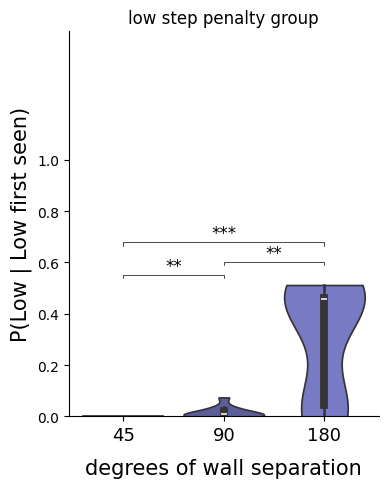

In [399]:
palette = sns.color_palette("tab20b", 3)

plt.figure(figsize=(4, 5))

sns.violinplot(data=data, palette=palette, cut=0)

# overlay points (recommended)
#sns.swarmplot(data=data, color='black', size=5)

plt.xticks([0, 1, 2], ['45', '90', '180'], fontsize=13)
plt.yticks(np.arange(0, 1.1, 0.2))
plt.ylim([0,1.5])
plt.ylabel("P(Low | Low first seen)", fontsize=15)
plt.xlabel("degrees of wall separation", fontsize=15, labelpad=10)
plt.title("low step penalty group")

sns.despine(top=True, right=True)

ax = plt.gca()

y_max = np.nanmax(data)
h = y_max * 0.05

add_sig_bar(ax, 0, 1, y_max + h, h/2, p_12)
add_sig_bar(ax, 1, 2, y_max + 3*h, h/2, p_24)
add_sig_bar(ax, 0, 2, y_max + 6*h, h/2, p_14)

plt.show()

In [400]:
mid_low_sep1 = np.array(p_mid_low_lp_1)
mid_low_sep2 = np.array(p_mid_low_lp_2)
mid_low_sep4 = np.array(p_mid_low_lp_4)

In [404]:
mid_high_sep1 = np.array(p_mid_high_lp_1)
mid_high_sep2 = np.array(p_mid_high_lp_2)
mid_high_sep4 = np.array(p_mid_high_lp_4)

In [402]:
data = [
    mid_low_sep1,
    mid_low_sep2,
    mid_low_sep4
]

In [403]:
# overall
stat, p = kruskal(mid_sep1, mid_sep2, mid_sep4)
print("Kruskal-Wallis p =", p)

# pairwise
p_12 = mannwhitneyu(mid_sep1, mid_sep2).pvalue
p_24 = mannwhitneyu(mid_sep2, mid_sep4).pvalue
p_14 = mannwhitneyu(mid_sep1, mid_sep4).pvalue

NameError: name 'mid_sep1' is not defined

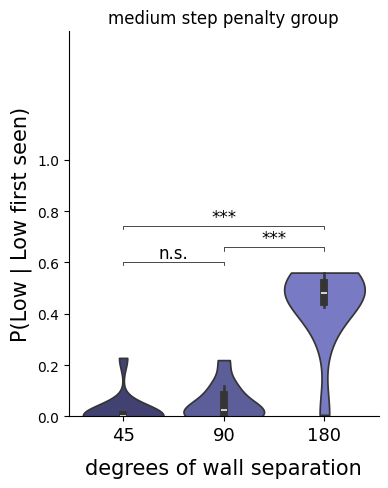

In [88]:
palette = sns.color_palette("tab20b", 3)

plt.figure(figsize=(4, 5))

sns.violinplot(data=data, palette=palette, cut=0)

# overlay points (recommended)
#sns.swarmplot(data=data, color='black', size=5)

plt.xticks([0, 1, 2], ['45', '90', '180'], fontsize=13)
plt.yticks(np.arange(0, 1.1, 0.2))
plt.ylim([0,1.5])
plt.ylabel("P(Low | Low first seen)", fontsize=15)
plt.xlabel("degrees of wall separation", fontsize=15, labelpad=10)
plt.title("medium step penalty group")

sns.despine(top=True, right=True)

ax = plt.gca()

y_max = np.nanmax(data)
h = y_max * 0.05

add_sig_bar(ax, 0, 1, y_max + h, h/2, p_12)
add_sig_bar(ax, 1, 2, y_max + 3*h, h/2, p_24)
add_sig_bar(ax, 0, 2, y_max + 6*h, h/2, p_14)

plt.show()

In [405]:
high_sep1 = np.array(p_high_lp_1)
high_sep2 = np.array(p_high_lp_2)
high_sep4 = np.array(p_high_lp_4)

In [77]:
data = [
    high_sep1,
    high_sep2,
    high_sep4
]

In [78]:
# overall
stat, p = kruskal(high_sep1, high_sep2, high_sep4)
print("Kruskal-Wallis p =", p)

# pairwise
p_12 = mannwhitneyu(high_sep1, high_sep2).pvalue
p_24 = mannwhitneyu(high_sep2, high_sep4).pvalue
p_14 = mannwhitneyu(high_sep1, high_sep4).pvalue

Kruskal-Wallis p = 0.003817618206101452


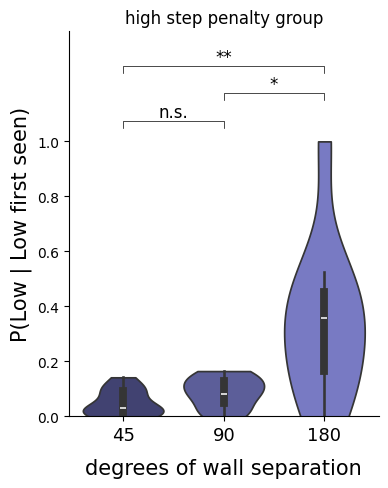

In [82]:
palette = sns.color_palette("tab20b", 3)

plt.figure(figsize=(4, 5))

sns.violinplot(data=data, palette=palette, cut=0)

# overlay points (recommended)
#sns.swarmplot(data=data, color='black', size=5)

plt.xticks([0, 1, 2], ['45', '90', '180'], fontsize=13)
plt.yticks(np.arange(0, 1.1, 0.2))
plt.ylim([0,1.4])
plt.ylabel("P(Low | Low first seen)", fontsize=15)
plt.xlabel("degrees of wall separation", fontsize=15, labelpad=10)
plt.title("high step penalty group")

sns.despine(top=True, right=True)

ax = plt.gca()

y_max = np.nanmax(data)
h = y_max * 0.05

add_sig_bar(ax, 0, 1, y_max + h, h/2, p_12)
add_sig_bar(ax, 1, 2, y_max + 3*h, h/2, p_24)
add_sig_bar(ax, 0, 2, y_max + 5*h, h/2, p_14)

plt.show()

### I want to compare P(L | L first) across sp groups for each wall sep

45

In [419]:
data = [
    low_sep1,
    mid_low_sep1,
    mid_high_sep1,
    high_sep1
]

In [420]:
# overall
stat, p = kruskal(low_sep1, mid_low_sep1, mid_high_sep1, high_sep1)
print("Kruskal-Wallis p =", p)

# pairwise
p_low_midlow = mannwhitneyu(low_sep1, mid_low_sep1).pvalue
p_midlow_midhigh = mannwhitneyu(mid_low_sep1, mid_high_sep1).pvalue
p_midhigh_high = mannwhitneyu(mid_high_sep1, high_sep1).pvalue

# optional broader comparisons
p_low_midhigh = mannwhitneyu(low_sep1, mid_high_sep1).pvalue
p_midlow_high = mannwhitneyu(mid_low_sep1, high_sep1).pvalue
p_low_high = mannwhitneyu(low_sep1, high_sep1).pvalue

Kruskal-Wallis p = 0.0001412242670331459


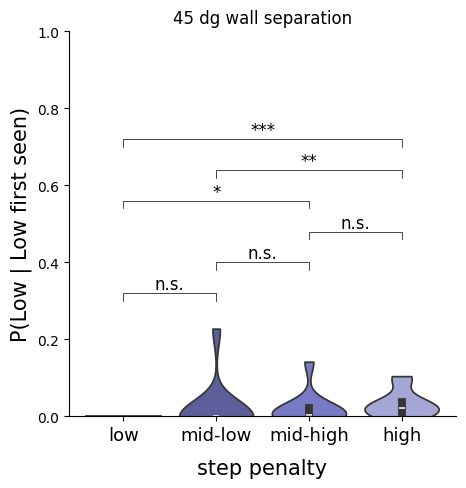

In [421]:

palette = sns.color_palette("tab20b", 4)

plt.figure(figsize=(5, 5))

sns.violinplot(data=data, palette=palette, cut=0)

plt.xticks(
    [0, 1, 2, 3],
    ['low', 'mid-low', 'mid-high', 'high'],
    fontsize=13
)

plt.yticks(np.arange(0, 1.1, 0.2))
plt.ylim([0, 1])
plt.ylabel("P(Low | Low first seen)", fontsize=15)
plt.xlabel("step penalty", fontsize=15, labelpad=10)
plt.title("45 dg wall separation")

sns.despine(top=True, right=True)

ax = plt.gca()

add_sig_bar(ax, 0, 1, 0.30, 0.02, p_low_midlow)
add_sig_bar(ax, 1, 2, 0.38, 0.02, p_midlow_midhigh)
add_sig_bar(ax, 2, 3, 0.46, 0.02, p_midhigh_high)

# optional broader comparisons
add_sig_bar(ax, 0, 2, 0.54, 0.02, p_low_midhigh)
add_sig_bar(ax, 1, 3, 0.62, 0.02, p_midlow_high)
add_sig_bar(ax, 0, 3, 0.70, 0.02, p_low_high)

plt.show()

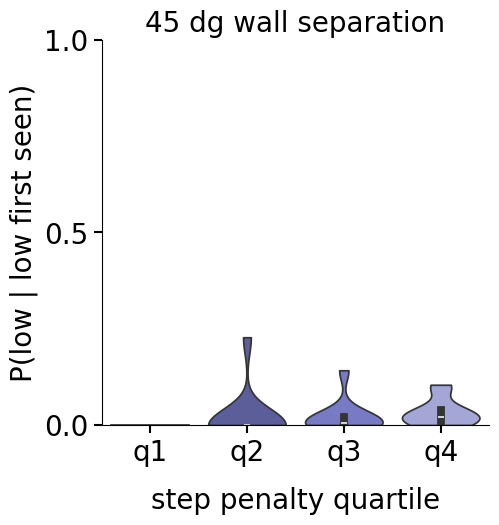

In [422]:

palette = sns.color_palette("tab20b", 4)

plt.figure(figsize=(5, 5))

sns.violinplot(data=data, palette=palette, cut=0)

plt.xticks(
    [0, 1, 2, 3],
    ['q1','q2','q3','q4'],
    fontsize=20
)

plt.yticks(np.arange(0, 1.1, 0.5), fontsize=20)
plt.ylim([0, 1])
plt.ylabel("P(low | low first seen)", fontsize=20)
plt.xlabel("step penalty quartile", fontsize=20, labelpad=15)
plt.title("45 dg wall separation", fontsize=20)

sns.despine(top=True, right=True)

ax = plt.gca()
ax.tick_params(width=1.5, length=6)


plt.show()

90

In [414]:
data = [
    low_sep2,
    mid_low_sep2,
    mid_high_sep2,
    high_sep2
]

In [416]:
# overall
stat, p = kruskal(low_sep2, mid_low_sep2, mid_high_sep2, high_sep2)
print("Kruskal-Wallis p =", p)

# pairwise
p_low_midlow = mannwhitneyu(low_sep2, mid_low_sep2).pvalue
p_midlow_midhigh = mannwhitneyu(mid_low_sep2, mid_high_sep2).pvalue
p_midhigh_high = mannwhitneyu(mid_high_sep2, high_sep2).pvalue

# optional broader comparisons
p_low_midhigh = mannwhitneyu(low_sep2, mid_high_sep2).pvalue
p_midlow_high = mannwhitneyu(mid_low_sep2, high_sep2).pvalue
p_low_high = mannwhitneyu(low_sep2, high_sep2).pvalue

Kruskal-Wallis p = 0.0008029430845151572


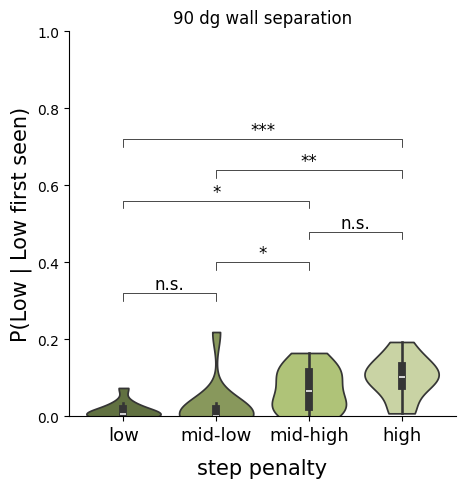

In [417]:
palette = sns.color_palette("tab20b")[4:8]
#palette = sns.color_palette("tab20b", 4)

plt.figure(figsize=(5, 5))

sns.violinplot(data=data, palette=palette, cut=0)

plt.xticks(
    [0, 1, 2, 3],
    ['low', 'mid-low', 'mid-high', 'high'],
    fontsize=13
)

plt.yticks(np.arange(0, 1.1, 0.2))
plt.ylim([0, 1])
plt.ylabel("P(Low | Low first seen)", fontsize=15)
plt.xlabel("step penalty", fontsize=15, labelpad=10)
plt.title("90 dg wall separation")

sns.despine(top=True, right=True)

ax = plt.gca()

add_sig_bar(ax, 0, 1, 0.30, 0.02, p_low_midlow)
add_sig_bar(ax, 1, 2, 0.38, 0.02, p_midlow_midhigh)
add_sig_bar(ax, 2, 3, 0.46, 0.02, p_midhigh_high)

# optional broader comparisons
add_sig_bar(ax, 0, 2, 0.54, 0.02, p_low_midhigh)
add_sig_bar(ax, 1, 3, 0.62, 0.02, p_midlow_high)
add_sig_bar(ax, 0, 3, 0.70, 0.02, p_low_high)

plt.show()

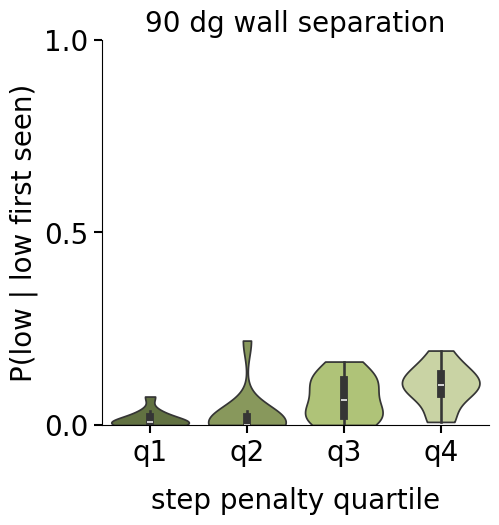

In [418]:

palette = sns.color_palette("tab20b")[4:8]

plt.figure(figsize=(5, 5))

sns.violinplot(data=data, palette=palette, cut=0)

plt.xticks(
    [0, 1, 2, 3],
    ['q1','q2','q3','q4'],
    fontsize=20
)

plt.yticks(np.arange(0, 1.1, 0.5), fontsize=20)
plt.ylim([0, 1])
plt.ylabel("P(low | low first seen)", fontsize=20)
plt.xlabel("step penalty quartile", fontsize=20, labelpad=15)
plt.title("90 dg wall separation", fontsize=20)

sns.despine(top=True, right=True)

ax = plt.gca()
ax.tick_params(width=1.5, length=6)


plt.show()

180

In [424]:
data = [
    low_sep4,
    mid_low_sep4,
    mid_high_sep4,
    high_sep4
]

In [425]:
# overall
stat, p = kruskal(low_sep4, mid_low_sep4, mid_high_sep4, high_sep4)
print("Kruskal-Wallis p =", p)

# pairwise
p_low_midlow = mannwhitneyu(low_sep4, mid_low_sep4).pvalue
p_midlow_midhigh = mannwhitneyu(mid_low_sep4, mid_high_sep4).pvalue
p_midhigh_high = mannwhitneyu(mid_high_sep4, high_sep4).pvalue

# optional broader comparisons
p_low_midhigh = mannwhitneyu(low_sep4, mid_high_sep4).pvalue
p_midlow_high = mannwhitneyu(mid_low_sep4, high_sep4).pvalue
p_low_high = mannwhitneyu(low_sep4, high_sep4).pvalue

Kruskal-Wallis p = 0.008290208012298761


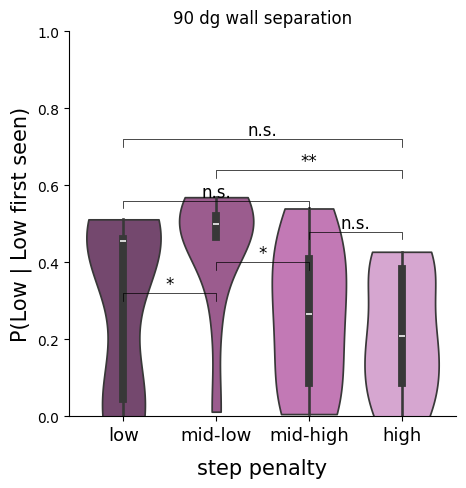

In [428]:
palette = sns.color_palette("tab20b")[16::]
#palette = sns.color_palette("tab20b", 4)

plt.figure(figsize=(5, 5))

sns.violinplot(data=data, palette=palette, cut=0)

plt.xticks(
    [0, 1, 2, 3],
    ['low', 'mid-low', 'mid-high', 'high'],
    fontsize=13
)

plt.yticks(np.arange(0, 1.1, 0.2))
plt.ylim([0, 1])
plt.ylabel("P(Low | Low first seen)", fontsize=15)
plt.xlabel("step penalty", fontsize=15, labelpad=10)
plt.title("90 dg wall separation")

sns.despine(top=True, right=True)

ax = plt.gca()

add_sig_bar(ax, 0, 1, 0.30, 0.02, p_low_midlow)
add_sig_bar(ax, 1, 2, 0.38, 0.02, p_midlow_midhigh)
add_sig_bar(ax, 2, 3, 0.46, 0.02, p_midhigh_high)

# optional broader comparisons
add_sig_bar(ax, 0, 2, 0.54, 0.02, p_low_midhigh)
add_sig_bar(ax, 1, 3, 0.62, 0.02, p_midlow_high)
add_sig_bar(ax, 0, 3, 0.70, 0.02, p_low_high)

plt.show()

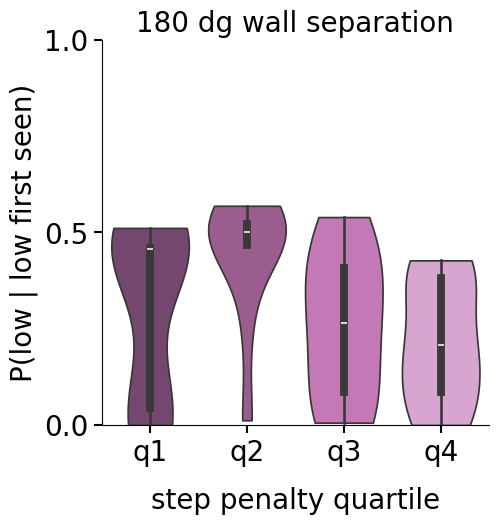

In [429]:

palette = sns.color_palette("tab20b")[16::]

plt.figure(figsize=(5, 5))

sns.violinplot(data=data, palette=palette, cut=0)

plt.xticks(
    [0, 1, 2, 3],
    ['q1','q2','q3','q4'],
    fontsize=20
)

plt.yticks(np.arange(0, 1.1, 0.5), fontsize=20)
plt.ylim([0, 1])
plt.ylabel("P(low | low first seen)", fontsize=20)
plt.xlabel("step penalty quartile", fontsize=20, labelpad=15)
plt.title("180 dg wall separation", fontsize=20)

sns.despine(top=True, right=True)

ax = plt.gca()
ax.tick_params(width=1.5, length=6)


plt.show()

# P(closest wall) by wall separation (for each penalty group)

In [430]:
import sandbox.glm.data_extraction_funcs as data_extraction_funcs

In [431]:
player_id = 0

for this I need to get the distance to each active wall at slice onset

In [432]:
for list_idx, trial_list in enumerate(low_lists_sep1):
    dist_low_1 = data_extraction_funcs.extract_distances_to_walls(trial_list, player_id)
    wall_low_1 = get_indices.was_high_wall_chosen(trial_list)
for list_idx, trial_list in enumerate(low_lists_sep2):  
    dist_low_2 = data_extraction_funcs.extract_distances_to_walls(trial_list, player_id)
    wall_low_2 = get_indices.was_high_wall_chosen(trial_list)
for list_idx, trial_list in enumerate(low_lists_sep4):
    dist_low_4 = data_extraction_funcs.extract_distances_to_walls(trial_list, player_id)
    wall_low_4 = get_indices.was_high_wall_chosen(trial_list)

for list_idx, trial_list in enumerate(mid_low_lists_sep1):
    dist_mid_low_1 = data_extraction_funcs.extract_distances_to_walls(trial_list, player_id)
    wall_mid_low_1 = get_indices.was_high_wall_chosen(trial_list)
for list_idx, trial_list in enumerate(mid_low_lists_sep2):
    dist_mid_low_2 = data_extraction_funcs.extract_distances_to_walls(trial_list, player_id)
    wall_mid_low_2 = get_indices.was_high_wall_chosen(trial_list)
for list_idx, trial_list in enumerate(mid_low_lists_sep4):
    dist_mid_low_4 = data_extraction_funcs.extract_distances_to_walls(trial_list, player_id)
    wall_mid_low_4 = get_indices.was_high_wall_chosen(trial_list)

for list_idx, trial_list in enumerate(mid_high_lists_sep1):
    dist_mid_high_1 = data_extraction_funcs.extract_distances_to_walls(trial_list, player_id)
    wall_mid_high_1 = get_indices.was_high_wall_chosen(trial_list)
for list_idx, trial_list in enumerate(mid_high_lists_sep2):
    dist_mid_high_2 = data_extraction_funcs.extract_distances_to_walls(trial_list, player_id)
    wall_mid_high_2 = get_indices.was_high_wall_chosen(trial_list)
for list_idx, trial_list in enumerate(mid_high_lists_sep4):
    dist_mid_high_4 = data_extraction_funcs.extract_distances_to_walls(trial_list, player_id)
    wall_mid_high_4 = get_indices.was_high_wall_chosen(trial_list)

for list_idx, trial_list in enumerate(high_lists_sep1):
    dist_high_1 = data_extraction_funcs.extract_distances_to_walls(trial_list, player_id)
    wall_high_1 = get_indices.was_high_wall_chosen(trial_list)
for list_idx, trial_list in enumerate(high_lists_sep2):
    dist_high_2 = data_extraction_funcs.extract_distances_to_walls(trial_list, player_id)
    wall_high_2 = get_indices.was_high_wall_chosen(trial_list)
for list_idx, trial_list in enumerate(high_lists_sep4):
    dist_high_4 = data_extraction_funcs.extract_distances_to_walls(trial_list, player_id)
    wall_high_4 = get_indices.was_high_wall_chosen(trial_list)

In [433]:
def compute_closest_wall_choice_fraction(trial_list, player_id):
    distances = data_extraction_funcs.extract_distances_to_walls(trial_list, player_id)
    choices = get_indices.was_high_wall_chosen(trial_list)

    correct = []

    for (dist_high, dist_low), chose_high in zip(distances, choices):
        if np.isnan(dist_high) or np.isnan(dist_low):
            continue

        closest_is_high = dist_high < dist_low
        print(f"closest is high {closest_is_high}")
        print(f"chose high {chose_high}")

        correct.append(closest_is_high == chose_high)

    if len(correct) == 0:
        return np.nan

    return np.mean(correct)

In [434]:
def compute_group_values(trial_lists):
    return [
        compute_closest_wall_choice_fraction(trial_list, player_id)
        for trial_list in trial_lists
    ]

In [256]:
high_4 = compute_group_values(high_lists_sep4)

closest is high False
chose high True
closest is high False
chose high True
closest is high True
chose high True
closest is high False
chose high True
closest is high True
chose high True
closest is high True
chose high True
closest is high True
chose high True
closest is high False
chose high False
closest is high False
chose high False
closest is high False
chose high False
closest is high True
chose high False
closest is high True
chose high True
closest is high False
chose high True
closest is high False
chose high False
closest is high False
chose high False
closest is high True
chose high False
closest is high False
chose high True
closest is high True
chose high True
closest is high True
chose high False
closest is high False
chose high False
closest is high True
chose high True
closest is high True
chose high True
closest is high False
chose high False
closest is high False
chose high True
closest is high True
chose high False
closest is high False
chose high True
closest is hi

In [435]:
low_1 = compute_group_values(low_lists_sep1)
low_2 = compute_group_values(low_lists_sep2)
low_4 = compute_group_values(low_lists_sep4)

mid_low_1 = compute_group_values(mid_low_lists_sep1)
mid_low_2 = compute_group_values(mid_low_lists_sep2)
mid_low_4 = compute_group_values(mid_low_lists_sep4)

mid_high_1 = compute_group_values(mid_high_lists_sep1)
mid_high_2 = compute_group_values(mid_high_lists_sep2)
mid_high_4 = compute_group_values(mid_high_lists_sep4)

high_1 = compute_group_values(high_lists_sep1)
high_2 = compute_group_values(high_lists_sep2)
high_4 = compute_group_values(high_lists_sep4)

closest is high True
chose high True
closest is high True
chose high True
closest is high False
chose high True
closest is high False
chose high True
closest is high False
chose high True
closest is high True
chose high True
closest is high False
chose high True
closest is high True
chose high True
closest is high False
chose high True
closest is high True
chose high True
closest is high False
chose high True
closest is high False
chose high True
closest is high True
chose high True
closest is high True
chose high True
closest is high False
chose high True
closest is high True
chose high True
closest is high False
chose high True
closest is high True
chose high True
closest is high False
chose high True
closest is high True
chose high True
closest is high True
chose high True
closest is high True
chose high True
closest is high False
chose high True
closest is high False
chose high True
closest is high True
chose high True
closest is high False
chose high True
closest is high False
cho

In [447]:
data = [
    low_1,
    low_2,
    low_4
]

In [448]:
# overall
stat, p = kruskal(low_1, low_2, low_4)
print("Kruskal-Wallis p =", p)

# pairwise
p_1 = mannwhitneyu(low_1, low_2).pvalue
p_2 = mannwhitneyu(low_2, low_4).pvalue
p_3 = mannwhitneyu(low_1, low_4).pvalue

print(p_1,p_2,p_3)

Kruskal-Wallis p = 0.16566895420133448
0.4701007598741287 0.11503496229473924 0.13096810379821186


/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_1173/3634861864.py:5: UserWarning: The palette list has more values (20) than needed (3), which may not be intended.
  sns.violinplot(data=data, palette=palette, cut=0)


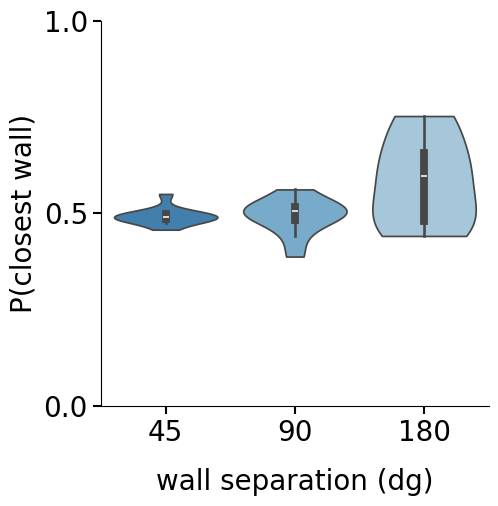

In [449]:

palette = sns.color_palette("tab20c")[0::]

plt.figure(figsize=(5, 5))

sns.violinplot(data=data, palette=palette, cut=0)

plt.xticks(
    [0, 1, 2], ['45', '90', '180'],
    fontsize=20
)

plt.yticks(np.arange(0, 1.1, 0.5), fontsize=20)
plt.ylim([0, 1])
plt.ylabel("P(closest wall)", fontsize=20)
plt.xlabel("wall separation (dg)", fontsize=20, labelpad=15)

sns.despine(top=True, right=True)

ax = plt.gca()
ax.tick_params(width=1.5, length=6)


plt.show()

In [450]:
data = [
    mid_low_1,
    mid_low_2,
    mid_low_4
]

In [460]:
# overall
stat, p = kruskal(mid_low_1, mid_low_2, mid_low_4)
print("Kruskal-Wallis p =", p)

# pairwise
p_1 = mannwhitneyu(mid_low_1, mid_low_2).pvalue
p_2 = mannwhitneyu(mid_low_2, mid_low_4).pvalue
p_3 = mannwhitneyu(mid_low_1, mid_low_4).pvalue

print(p_1,p_2,p_3)

Kruskal-Wallis p = 0.10948593736855654
0.04884406417427429 0.11503496229473924 1.0


/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_1173/415986329.py:5: UserWarning: The palette list has more values (16) than needed (3), which may not be intended.
  sns.violinplot(data=data, palette=palette, cut=0)


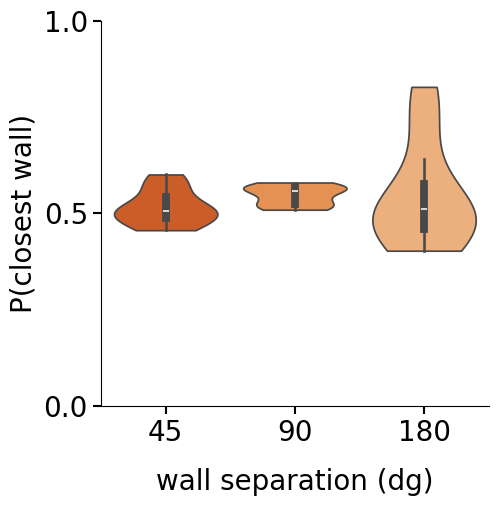

In [452]:

palette = sns.color_palette("tab20c")[4::]

plt.figure(figsize=(5, 5))

sns.violinplot(data=data, palette=palette, cut=0)

plt.xticks(
    [0, 1, 2], ['45', '90', '180'],
    fontsize=20
)

plt.yticks(np.arange(0, 1.1, 0.5), fontsize=20)
plt.ylim([0, 1])
plt.ylabel("P(closest wall)", fontsize=20)
plt.xlabel("wall separation (dg)", fontsize=20, labelpad=15)

sns.despine(top=True, right=True)

ax = plt.gca()
ax.tick_params(width=1.5, length=6)


plt.show()

In [453]:
data = [
    mid_high_1,
    mid_high_2,
    mid_high_4
]

In [454]:
# overall
stat, p = kruskal(mid_high_1, mid_high_2, mid_high_4)
print("Kruskal-Wallis p =", p)

# pairwise
p_1 = mannwhitneyu(mid_high_1, mid_high_2).pvalue
p_2 = mannwhitneyu(mid_high_2, mid_high_4).pvalue
p_3 = mannwhitneyu(mid_high_1, mid_high_4).pvalue

print(p_1,p_2,p_3)

Kruskal-Wallis p = 0.8040735642792943
0.7913367801006604 0.7913367801006604 0.5205228832757727


/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_1173/681112055.py:5: UserWarning: The palette list has more values (12) than needed (3), which may not be intended.
  sns.violinplot(data=data, palette=palette, cut=0)


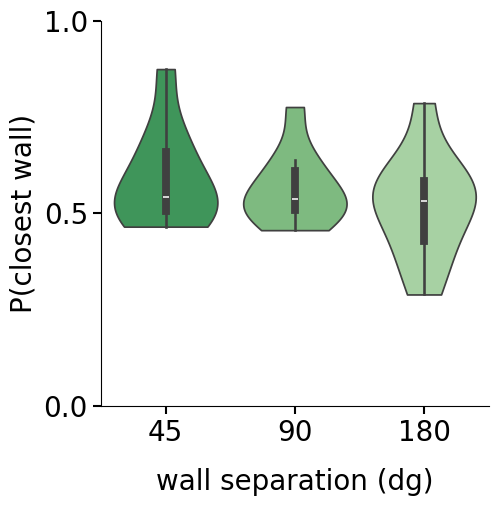

In [456]:

palette = sns.color_palette("tab20c")[8::]

plt.figure(figsize=(5, 5))

sns.violinplot(data=data, palette=palette, cut=0)

plt.xticks(
    [0, 1, 2], ['45', '90', '180'],
    fontsize=20
)

plt.yticks(np.arange(0, 1.1, 0.5), fontsize=20)
plt.ylim([0, 1])
plt.ylabel("P(closest wall)", fontsize=20)
plt.xlabel("wall separation (dg)", fontsize=20, labelpad=15)

sns.despine(top=True, right=True)

ax = plt.gca()
ax.tick_params(width=1.5, length=6)


plt.show()

In [457]:
data = [
    high_1,
    high_2,
    high_4
]

In [458]:
# overall
stat, p = kruskal(high_1, high_2, high_4)
print("Kruskal-Wallis p =", p)

# pairwise
p_1 = mannwhitneyu(high_1, high_2).pvalue
p_2 = mannwhitneyu(high_2, high_4).pvalue
p_3 = mannwhitneyu(high_1, high_4).pvalue

print(p_1,p_2,p_3)

Kruskal-Wallis p = 0.06616489455904515
0.5114059218501164 0.0877681118303241 0.03561636409984439


/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_1173/2563759129.py:5: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  sns.violinplot(data=data, palette=palette, cut=0)


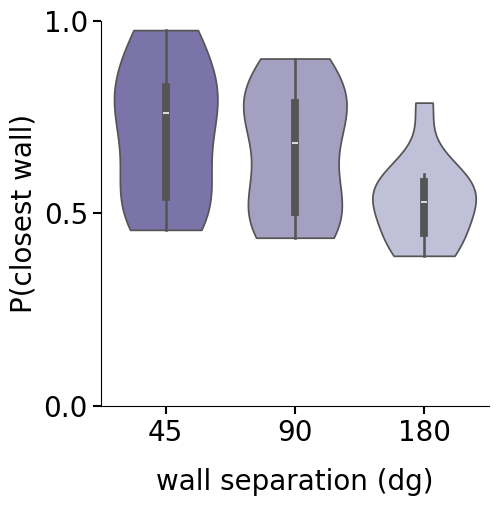

In [459]:

palette = sns.color_palette("tab20c")[12::]

plt.figure(figsize=(5, 5))

sns.violinplot(data=data, palette=palette, cut=0)

plt.xticks(
    [0, 1, 2], ['45', '90', '180'],
    fontsize=20
)

plt.yticks(np.arange(0, 1.1, 0.5), fontsize=20)
plt.ylim([0, 1])
plt.ylabel("P(closest wall)", fontsize=20)
plt.xlabel("wall separation (dg)", fontsize=20, labelpad=15)

sns.despine(top=True, right=True)

ax = plt.gca()
ax.tick_params(width=1.5, length=6)


plt.show()

now between step penalty groups keeping wall sep fixed

In [500]:
data = [
    low_1,
    mid_low_1,
    mid_high_1,
    high_1
]

In [501]:
# overall
stat, p = kruskal(low_1,
    mid_low_1,
    mid_high_1,
    high_1)
print("Kruskal-Wallis p =", p)

# pairwise
# pairwise
p1 = mannwhitneyu(low_1, mid_low_1).pvalue
p2 = mannwhitneyu(mid_low_1, mid_high_1).pvalue
p3 = mannwhitneyu(mid_high_1, high_1).pvalue

# optional broader comparisons
p4 = mannwhitneyu(low_1, mid_high_1).pvalue
p5 = mannwhitneyu(mid_low_1, high_1).pvalue
p6 = mannwhitneyu(low_1, high_1).pvalue

print(p1,p2,p3,p4,p5,p6)

Kruskal-Wallis p = 0.0014777592007821116
0.13096810379821186 0.16970614227251246 0.13002979638383577 0.00827421565071521 0.008624253827852814 0.0020269456469727064


/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_1173/4288025867.py:5: UserWarning: The palette list has more values (20) than needed (4), which may not be intended.
  sns.violinplot(data=data, palette=palette, cut=0)


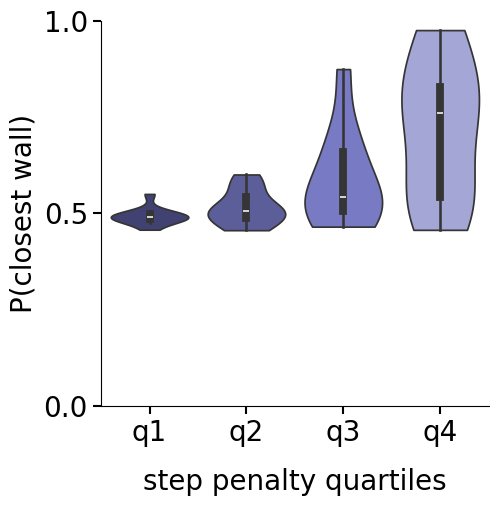

In [502]:

palette = sns.color_palette("tab20b")[0::]

plt.figure(figsize=(5, 5))

sns.violinplot(data=data, palette=palette, cut=0)

plt.xticks(
    [0, 1, 2, 3], ['q1', 'q2', 'q3', 'q4'],
    fontsize=20
)

plt.yticks(np.arange(0, 1.1, 0.5), fontsize=20)
plt.ylim([0, 1])
plt.ylabel("P(closest wall)", fontsize=20)
plt.xlabel("step penalty quartiles", fontsize=20, labelpad=15)

sns.despine(top=True, right=True)

ax = plt.gca()
ax.tick_params(width=1.5, length=6)


plt.show()

In [503]:
data = [
    low_2,
    mid_low_2,
    mid_high_2,
    high_2
]

In [504]:
# overall
stat, p = kruskal(low_2,
    mid_low_2,
    mid_high_2,
    high_2)
print("Kruskal-Wallis p =", p)

# pairwise
# pairwise
p1 = mannwhitneyu(low_2, mid_low_2).pvalue
p2 = mannwhitneyu(mid_low_2, mid_high_2).pvalue
p3 = mannwhitneyu(mid_high_2, high_2).pvalue

# optional broader comparisons
p4 = mannwhitneyu(low_2, mid_high_2).pvalue
p5 = mannwhitneyu(mid_low_2, high_2).pvalue
p6 = mannwhitneyu(low_2, high_2).pvalue

print(p1,p2,p3,p4,p5,p6)

Kruskal-Wallis p = 0.018455366977968995
0.0020269456469727064 0.549471691823942 0.2452781168067728 0.07254925722048404 0.21216467995625798 0.03561636409984439


In [505]:
p6

np.float64(0.03561636409984439)

/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_1173/4184657627.py:5: UserWarning: The palette list has more values (16) than needed (4), which may not be intended.
  sns.violinplot(data=data, palette=palette, cut=0)


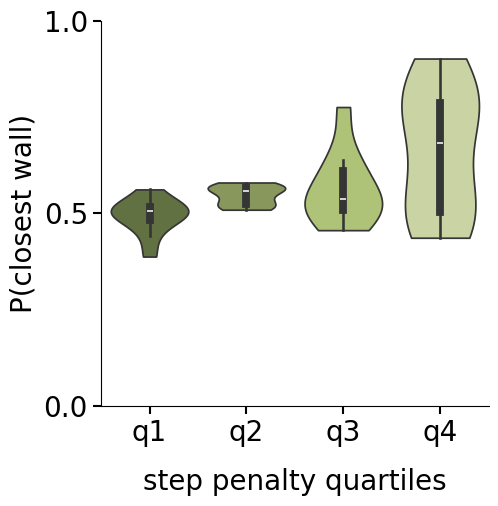

In [507]:

palette = sns.color_palette("tab20b")[4::]

plt.figure(figsize=(5, 5))

sns.violinplot(data=data, palette=palette, cut=0)

plt.xticks(
    [0, 1, 2, 3], ['q1', 'q2', 'q3', 'q4'],
    fontsize=20
)

plt.ylim([0, 1])
plt.ylabel("P(closest wall)", fontsize=20)
plt.xlabel("step penalty quartiles", fontsize=20, labelpad=15)
plt.yticks(np.arange(0, 1.1, 0.5), fontsize=20)

sns.despine(top=True, right=True)

ax = plt.gca()
ax.tick_params(width=1.5, length=6)


plt.show()

In [508]:
data = [
    low_4,
    mid_low_4,
    mid_high_4,
    high_4
]

In [509]:
# overall
stat, p = kruskal(low_4,
    mid_low_4,
    mid_high_4,
    high_4)
print("Kruskal-Wallis p =", p)

# pairwise
# pairwise
p1 = mannwhitneyu(low_4, mid_low_4).pvalue
p2 = mannwhitneyu(mid_low_4, mid_high_4).pvalue
p3 = mannwhitneyu(mid_high_4, high_4).pvalue

# optional broader comparisons
p4 = mannwhitneyu(low_4, mid_high_4).pvalue
p5 = mannwhitneyu(mid_low_4, high_4).pvalue
p6 = mannwhitneyu(low_4, high_4).pvalue

print(p1,p2,p3,p4,p5,p6)

Kruskal-Wallis p = 0.7255676175403747
0.5545304064894243 0.8602588271965479 0.7781252340552375 0.34178646181502725 0.8955142436987509 0.26429152373398135


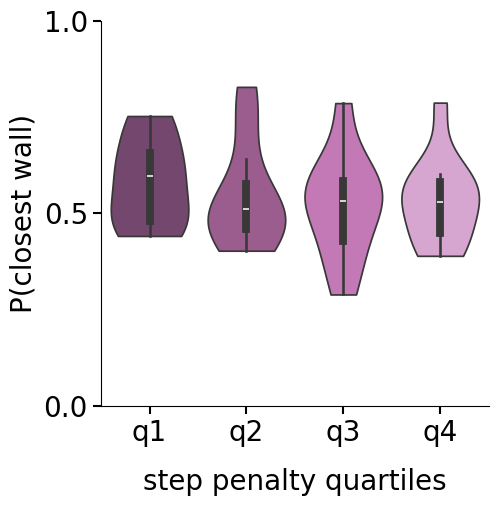

In [512]:

palette = sns.color_palette("tab20b")[16::]

plt.figure(figsize=(5, 5))

sns.violinplot(data=data, palette=palette, cut=0)

plt.xticks(
    [0, 1, 2, 3], ['q1', 'q2', 'q3', 'q4'],
    fontsize=20
)

plt.yticks(np.arange(0, 1.1, 0.5), fontsize=20)
plt.ylim([0, 1])
plt.ylabel("P(closest wall)", fontsize=20)
plt.xlabel("step penalty quartiles", fontsize=20, labelpad=15)

sns.despine(top=True, right=True)

ax = plt.gca()
ax.tick_params(width=1.5, length=6)


plt.show()

In [211]:
data = [
    low_1,
    mid_1,
    high_1
]

In [212]:
# overall
stat, p = kruskal(low_1, mid_1, high_1)
print("Kruskal-Wallis p =", p)

# pairwise
p_lm = mannwhitneyu(low_1, mid_1).pvalue
p_mh = mannwhitneyu(mid_1, high_1).pvalue
p_lh = mannwhitneyu(low_1, high_1).pvalue

Kruskal-Wallis p = 0.0038467561800624465


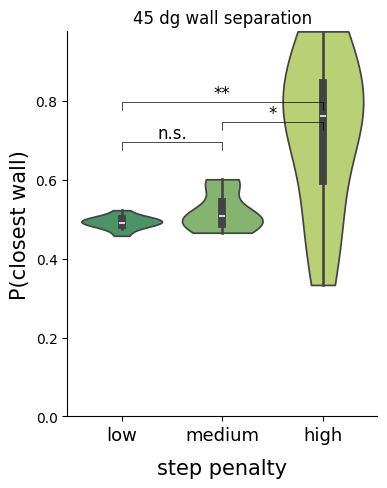

In [230]:
palette = sns.color_palette("summer", 3)

plt.figure(figsize=(4, 5))

sns.violinplot(data=data, palette=palette, cut=0)

# overlay points (recommended)
#sns.swarmplot(data=data, color='black', size=5)

plt.xticks([0, 1, 2], ['low', 'medium', 'high'], fontsize=13)
plt.yticks(np.arange(0, 1.1, 0.2))
plt.ylim([0,y_max])
plt.ylabel("P(closest wall)", fontsize=15)
plt.xlabel("step penalty", fontsize=15, labelpad=10)
plt.title("45 dg wall separation")

sns.despine(top=True, right=True)

ax = plt.gca()

y_max = np.nanmax(data)
h = y_max

add_sig_bar(ax, 0, 1, y_max-0.3, 0.02, p_lm)
add_sig_bar(ax, 1, 2,y_max-0.25, 0.02, p_mh)
add_sig_bar(ax, 0, 2, y_max-0.2, 0.02, p_lh)

plt.show()

In [231]:
data = [
    low_2,
    mid_2,
    high_2
]

In [232]:
# overall
stat, p = kruskal(low_2, mid_2, high_2)
print("Kruskal-Wallis p =", p)

# pairwise
p_lm = mannwhitneyu(low_2, mid_2).pvalue
p_mh = mannwhitneyu(mid_2, high_2).pvalue
p_lh = mannwhitneyu(low_2, high_2).pvalue

Kruskal-Wallis p = 0.0005918941199738852


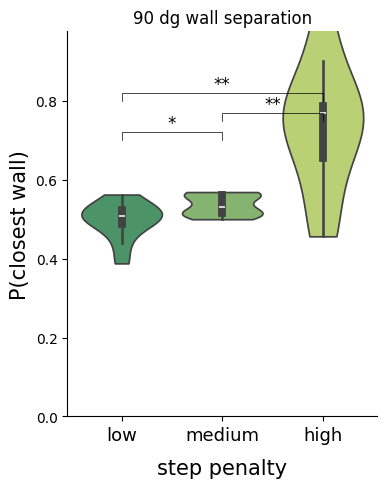

In [233]:
palette = sns.color_palette("summer", 3)

plt.figure(figsize=(4, 5))

sns.violinplot(data=data, palette=palette, cut=0)

# overlay points (recommended)
#sns.swarmplot(data=data, color='black', size=5)

plt.xticks([0, 1, 2], ['low', 'medium', 'high'], fontsize=13)
plt.yticks(np.arange(0, 1.1, 0.2))
plt.ylim([0,y_max])
plt.ylabel("P(closest wall)", fontsize=15)
plt.xlabel("step penalty", fontsize=15, labelpad=10)
plt.title("90 dg wall separation")

sns.despine(top=True, right=True)

ax = plt.gca()

y_max = np.nanmax(data)
h = y_max

add_sig_bar(ax, 0, 1, y_max-0.3, 0.02, p_lm)
add_sig_bar(ax, 1, 2,y_max-0.25, 0.02, p_mh)
add_sig_bar(ax, 0, 2, y_max-0.2, 0.02, p_lh)

plt.show()

In [244]:
data = [
    low_4,
    mid_4,
    high_4
]

In [246]:
high_4_clean = high_4[high_4!=np.nan]

In [247]:
# overall
stat, p = kruskal(low_4, mid_4, high_4_clean)
print("Kruskal-Wallis p =", p)

# pairwise
p_lm = mannwhitneyu(low_4, mid_4).pvalue
p_mh = mannwhitneyu(mid_4, high_4_clean).pvalue
p_lh = mannwhitneyu(low_4, high_4_clean).pvalue

Kruskal-Wallis p = 0.20333805783594658


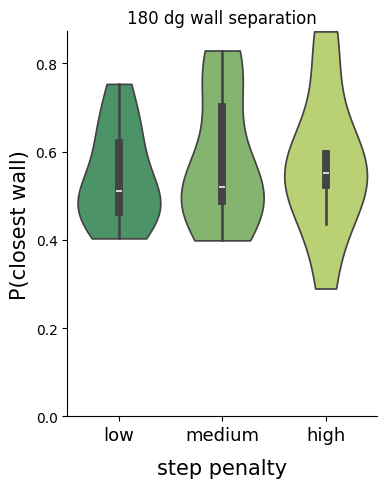

In [250]:
palette = sns.color_palette("summer", 3)

plt.figure(figsize=(4, 5))

sns.violinplot(data=data, palette=palette, cut=0)

# overlay points (recommended)
#sns.swarmplot(data=data, color='black', size=5)

plt.xticks([0, 1, 2], ['low', 'medium', 'high'], fontsize=13)
plt.yticks(np.arange(0, 1.1, 0.2))
plt.ylim([0,y_max])
plt.ylabel("P(closest wall)", fontsize=15)
plt.xlabel("step penalty", fontsize=15, labelpad=10)
plt.title("180 dg wall separation")

sns.despine(top=True, right=True)

ax = plt.gca()

y_max = np.nanmax(data)
h = y_max

#add_sig_bar(ax, 0, 1, y_max-0.3, 0.02, p_lm)
#add_sig_bar(ax, 1, 2,y_max-0.25, 0.02, p_mh)
#add_sig_bar(ax, 0, 2, y_max-0.2, 0.02, p_lh)

plt.show()

then decide which is closest

then check if closest = choice

then count how many times this is true in a session and divide over number of trials in the session

### below is the rougher code I started with

In [185]:
(trial_list_low_vis_filtered,
  trial_list_low_vis_and_choice_filtered) = heatmap_phigh.filter_pipeline_p_high_first_seen_wall(trial_lists,
                                                                        num_players,
                                                                        first_visible_wall_index,
                                                                        chosen_wall_index)

filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[0. 0. 0. 0. 1. 1. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 1. 1. 1. 1. 0.
 1. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 1. 1. 0. 0. 1. 0. 1.
 0. 0. 0. 1. 0. 0. 0. 0. 1. 1. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0.
 0. 1. 1. 0. 1. 1. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0. 1. 1. 1. 0. 0. 1. 0. 0.
 0. 1. 1. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.
 1. 0. 1. 0. 0. 0. 0. 1. 1. 1. 1. 0. 1. 0. 0. 1. 0. 0. 0. 1. 0. 0. 1. 0.
 0. 0. 1. 0. 0. 0. 0. 1. 1. 0. 1. 0. 0. 1. 1. 0. 0. 0. 0. 1. 1. 0. 0. 1.
 0. 0. 0. 1. 0. 1. 0. 0. 0. 1. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 1. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1.
 0. 0. 1. 0. 0. 0. 1. 0. 1. 0. 0. 1. 0. 0. 1. 0. 1. 1. 0. 0. 1. 0. 0. 0.
 1. 0. 1. 1. 0. 1. 1. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 0.
 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0.
 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 

In [133]:
from analysis import opponent_visibility

Get slice onset positions for each session for each trial

In [90]:
slice_onset_positions_dict = {}
for j, trial_list in enumerate(trial_lists):
    pos_list = []
    for i in range(len(trial_list)):
        if i == 0:
            continue
        slice_onset_positions = (opponent_visibility.get_player_position_slice_onset(player_id=0, trial=None, trial_list=trial_list, trial_index=i))
        pos_list.append(slice_onset_positions)
    slice_onset_positions_dict[j] = pos_list

Find the arena radius through the data

In [91]:
all_positions = np.array([
    pos for pos_list in slice_onset_positions_dict.values()
    for pos in pos_list
    if pos is not None
])

In [92]:
arena_radius = np.nanmax(np.linalg.norm(all_positions, axis=1))

In [93]:
arena_radius * 1.05

np.float64(20.123900077952392)

In [106]:
num_radial_bins = 10
r_max = arena_radius
radial_bins = np.linspace(0, r_max, num_radial_bins + 1)

# initialise bin counts for radial bins
bins_dict_wall_seen = np.zeros(num_radial_bins)
bins_dict_wall_seen_wall_chosen = np.zeros(num_radial_bins)

# across player ID 1 or 2
for player_id in range(num_players):
    
    # filtered for trials where player saw specified first-seen wall
    trial_lists_denominator = trial_list_high_vis_filtered[player_id]
    # filter for trials where player additionally chose specified chosen wall
    trial_lists_numerator = trial_list_high_vis_and_choice_filtered[player_id]

    
    # across each trial list for this player ID
    for trial_list_index, trial_list in enumerate(trial_lists_denominator):

        # across each trial in the trial list
        for trial_index, trial in enumerate(trial_list):
            
            # get slice onset position (denominator)
            x_val, y_val = get_indices.get_player_slice_onset_loc(trial, player_id=player_id)

            # compute radial distance
            r = np.sqrt(x_val**2 + y_val**2)

            # find bin index
            bin_index = np.digitize(r, radial_bins) - 1

            # increment denominator bin count if within range
            if 0 <= bin_index < num_radial_bins:
                bins_dict_wall_seen[bin_index] += 1

    # across each trial list for this player ID
    for trial_list_index, trial_list in enumerate(trial_lists_numerator):
        
        # across each trial in the filtered list
        for trial_index, trial in enumerate(trial_list):
            # get slice onset position (numerator)
            x_val, y_val = get_indices.get_player_slice_onset_loc(trial, player_id=player_id)

            # compute radial distance
            r = np.sqrt(x_val**2 + y_val**2)

            # find bin index
            bin_index = np.digitize(r, radial_bins) - 1

            # increment numerator bin count if within range
            if 0 <= bin_index < num_radial_bins:
                bins_dict_wall_seen_wall_chosen[bin_index] += 1

    print(f"Done for player {player_id}, counts in numerator bin 0: {bins_dict_wall_seen_wall_chosen[0]} ")

Done for player 0, counts in numerator bin 0: 2475.0 


In [101]:
# element-wise division of numerator and denominator arrays, with handling for division by zero
pH_by_bin_low_solo = np.divide(
    bins_dict_wall_seen_wall_chosen, bins_dict_wall_seen,
    out=np.zeros_like(bins_dict_wall_seen_wall_chosen, dtype=float),
    # boolean array to mask division for only non-zero denominator entries
    where=bins_dict_wall_seen > 0
)

# filter out bins with fewer than x trials
pH_by_bin_low_solo[bins_dict_wall_seen <= 10] = np.nan
probabilities_low = pH_by_bin_low_solo

In [107]:
# element-wise division of numerator and denominator arrays, with handling for division by zero
pH_by_bin_high_solo = np.divide(
    bins_dict_wall_seen_wall_chosen, bins_dict_wall_seen,
    out=np.zeros_like(bins_dict_wall_seen_wall_chosen, dtype=float),
    # boolean array to mask division for only non-zero denominator entries
    where=bins_dict_wall_seen > 0
)

# filter out bins with fewer than x trials
pH_by_bin_high_solo[bins_dict_wall_seen <= 10] = np.nan
probabilities_high = pH_by_bin_high_solo

In [188]:
from matplotlib import cm
import matplotlib as mpl
from matplotlib.patches import Polygon
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.path import Path
from matplotlib.patches import PathPatch

In [189]:
def plot_heatmap_phigh_circular(probabilities, radial_bins, n_angular_bins=8, 
                                 cmap_name='inferno', diff_cmap_name='PiYG'):
    ''' Plot a heatmap of P(Choose High) across circular bins overlaid on octagon
     
        probabilities: 1D array of probabilities across radial bins
        radial_bins: bin edges for radial distance
        n_angular_bins: number of angular bins (default 8 for octagon)
    '''
    

    octagon_vertex_coordinates = plot_octagon.return_octagon_path_points()
    
    fig, ax = plt.subplots(figsize=(8, 8))
    
    cmap = cm.get_cmap(cmap_name)
    cmap.set_bad(color='white')
    
    # Normalize probabilities to 0-1
    norm = mpl.colors.Normalize(vmin=0, vmax=1)
    
    # Create angular bins
    theta_bins = np.linspace(0, 2*np.pi, n_angular_bins + 1)
    
    # Plot each bin as a rectangle in Cartesian coordinates
# Create octagon clip path, but do not add it visibly yet
    octagon_clip = Polygon(
        octagon_vertex_coordinates,
        closed=True,
        facecolor='none',
        edgecolor='none',
        transform=ax.transData
    )

    for i in range(len(radial_bins) - 1):
        for j in range(n_angular_bins):
            r_inner = radial_bins[i]
            r_outer = radial_bins[i + 1]
            theta_start = theta_bins[j]
            theta_end = theta_bins[j + 1]

            theta_mid = np.linspace(theta_start, theta_end, 20)
            x_inner = r_inner * np.cos(theta_mid)
            y_inner = r_inner * np.sin(theta_mid)
            x_outer = r_outer * np.cos(theta_mid[::-1])
            y_outer = r_outer * np.sin(theta_mid[::-1])

            vertices = np.column_stack([
                np.concatenate([x_inner, x_outer]),
                np.concatenate([y_inner, y_outer])
            ])

            color = cmap(norm(probabilities[i]))
            patch = Polygon(vertices, facecolor=color, edgecolor='none', linewidth=0)

            # This is the key line
            patch.set_clip_path(octagon_clip)

            ax.add_patch(patch)
    
    
    # Overlay octagon outline
    octagon_patch = Polygon(
    octagon_vertex_coordinates,
    closed=True,
    edgecolor='black',
    facecolor='none',
    lw=2
    )   
    ax.add_patch(octagon_patch)
    
    ax.set_xlim([-25, 25])
    ax.set_ylim([-25, 25])
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    # Add colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, pad=0.1, shrink=0.5)


/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_10541/3393867097.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


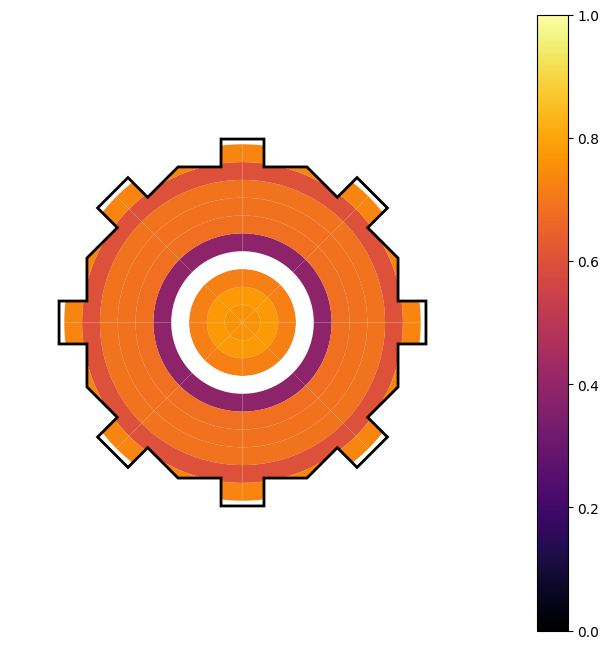

In [103]:
plot_heatmap_phigh_circular(probabilities_low, radial_bins, n_angular_bins=8, 
                                 cmap_name='inferno', diff_cmap_name='PiYG')

/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_10541/3393867097.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


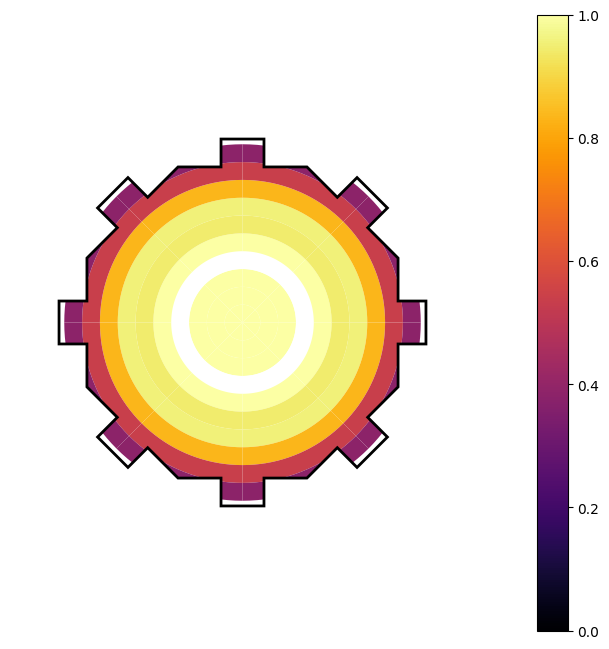

In [108]:
plot_heatmap_phigh_circular(probabilities_high, radial_bins, n_angular_bins=8, 
                                 cmap_name='inferno', diff_cmap_name='PiYG')

## Heatmaps by step penalty

In [191]:
len(step_penalties)

23

In [144]:
step_penalties[10]

0.00044613672071136534

In [145]:
analysis_results[10]['choice_data']['probability_chose_high']

np.float64(0.8763197586726998)

### low first

In [202]:
def _plot_on_ax(ax, probabilities, radial_bins, title,
                n_angular_bins=8, cmap_name='inferno'):
    octagon_vertex_coordinates = plot_octagon.return_octagon_path_points()
    cmap = cm.get_cmap(cmap_name)
    cmap.set_bad(color='white')
    norm = mpl.colors.Normalize(vmin=0, vmax=1)
    theta_bins = np.linspace(0, 2*np.pi, n_angular_bins + 1)

    octagon_clip = Polygon(
        octagon_vertex_coordinates,
        closed=True,
        facecolor='none',
        edgecolor='none',
        transform=ax.transData
    )

    for i in range(len(radial_bins) - 1):
        for j in range(n_angular_bins):
            r_inner = radial_bins[i]
            r_outer = radial_bins[i + 1]
            theta_start = theta_bins[j]
            theta_end = theta_bins[j + 1]

            theta_mid = np.linspace(theta_start, theta_end, 20)
            x_inner = r_inner * np.cos(theta_mid)
            y_inner = r_inner * np.sin(theta_mid)
            x_outer = r_outer * np.cos(theta_mid[::-1])
            y_outer = r_outer * np.sin(theta_mid[::-1])

            vertices = np.column_stack([
                np.concatenate([x_inner, x_outer]),
                np.concatenate([y_inner, y_outer])
            ])

            color = cmap(norm(probabilities[i]))
            patch = Polygon(vertices, facecolor=color, edgecolor='none', linewidth=0)
            patch.set_clip_path(octagon_clip)
            ax.add_patch(patch)

    octagon_patch = Polygon(
        octagon_vertex_coordinates,
        closed=True,
        edgecolor='black',
        facecolor='none',
        lw=2
    )
    ax.add_patch(octagon_patch)

    ax.set_xlim([-25, 25])
    ax.set_ylim([-25, 25])
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_title(title, pad=10, fontsize=14, fontweight='bold')




/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_10541/324732289.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)
/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_10541/324732289.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)
/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_10541/324732289.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_n

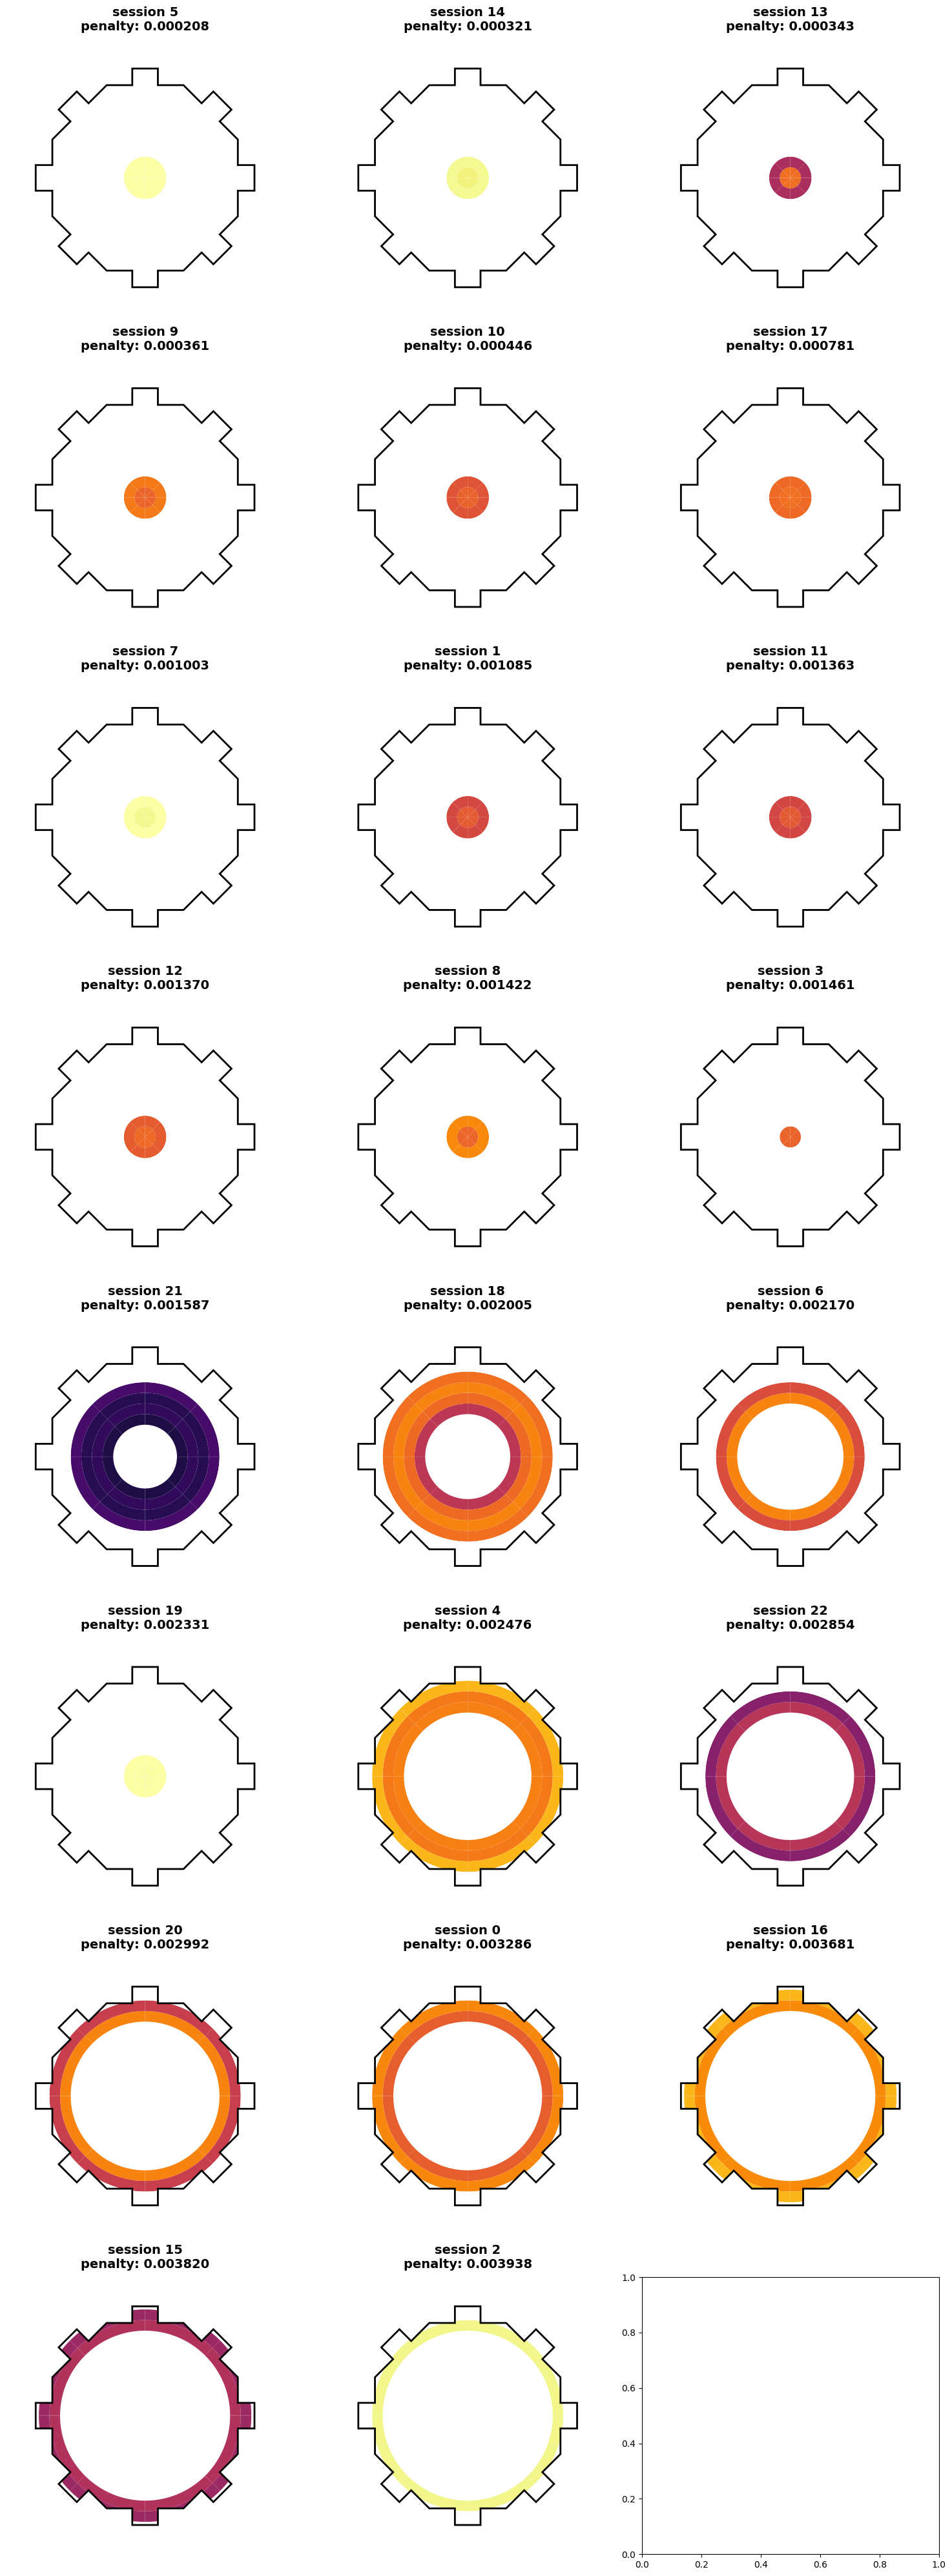

In [ ]:
num_i = len(trial_list_low_vis_filtered[0])
sorted_indices = np.argsort(step_penalties)

# Create a grid of subplots
n_cols = 3
n_rows = (len(sorted_indices) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten()  # Flatten to easily iterate

for plot_idx, idx in enumerate(sorted_indices):
    i = idx

    num_radial_bins = 10
    r_max = arena_radius
    radial_bins = np.linspace(0, r_max, num_radial_bins + 1)

    bins_dict_wall_seen = np.zeros(num_radial_bins)
    bins_dict_wall_seen_wall_chosen = np.zeros(num_radial_bins)

    for player_id in range(num_players):
        trial_list_denominator = trial_list_low_vis_filtered[player_id][i]
        trial_list_numerator = trial_list_low_vis_and_choice_filtered[player_id][i]

        for trial_index, trial in enumerate(trial_list_denominator):
            x_val, y_val = get_indices.get_player_slice_onset_loc(trial, player_id=player_id)
            r = np.sqrt(x_val**2 + y_val**2)
            bin_index = np.digitize(r, radial_bins) - 1
            if 0 <= bin_index < num_radial_bins:
                bins_dict_wall_seen[bin_index] += 1

        for trial_index, trial in enumerate(trial_list_numerator):
            x_val, y_val = get_indices.get_player_slice_onset_loc(trial, player_id=player_id)
            r = np.sqrt(x_val**2 + y_val**2)
            bin_index = np.digitize(r, radial_bins) - 1
            if 0 <= bin_index < num_radial_bins:
                bins_dict_wall_seen_wall_chosen[bin_index] += 1

    pH_by_bin_low_solo = np.divide(
        bins_dict_wall_seen_wall_chosen, bins_dict_wall_seen,
        out=np.zeros_like(bins_dict_wall_seen_wall_chosen, dtype=float),
        where=bins_dict_wall_seen > 0
    )
    pH_by_bin_low_solo[bins_dict_wall_seen <= 10] = np.nan
    probabilities_low = pH_by_bin_low_solo

    title = f"session {i}\npenalty: {step_penalties[idx]:.6f}"
    _plot_on_ax(axes[plot_idx], probabilities_low, radial_bins, title)

plt.tight_layout()
plt.show()


### high first

/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_10541/1350278361.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)
/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_10541/1350278361.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)
/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_10541/1350278361.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cma

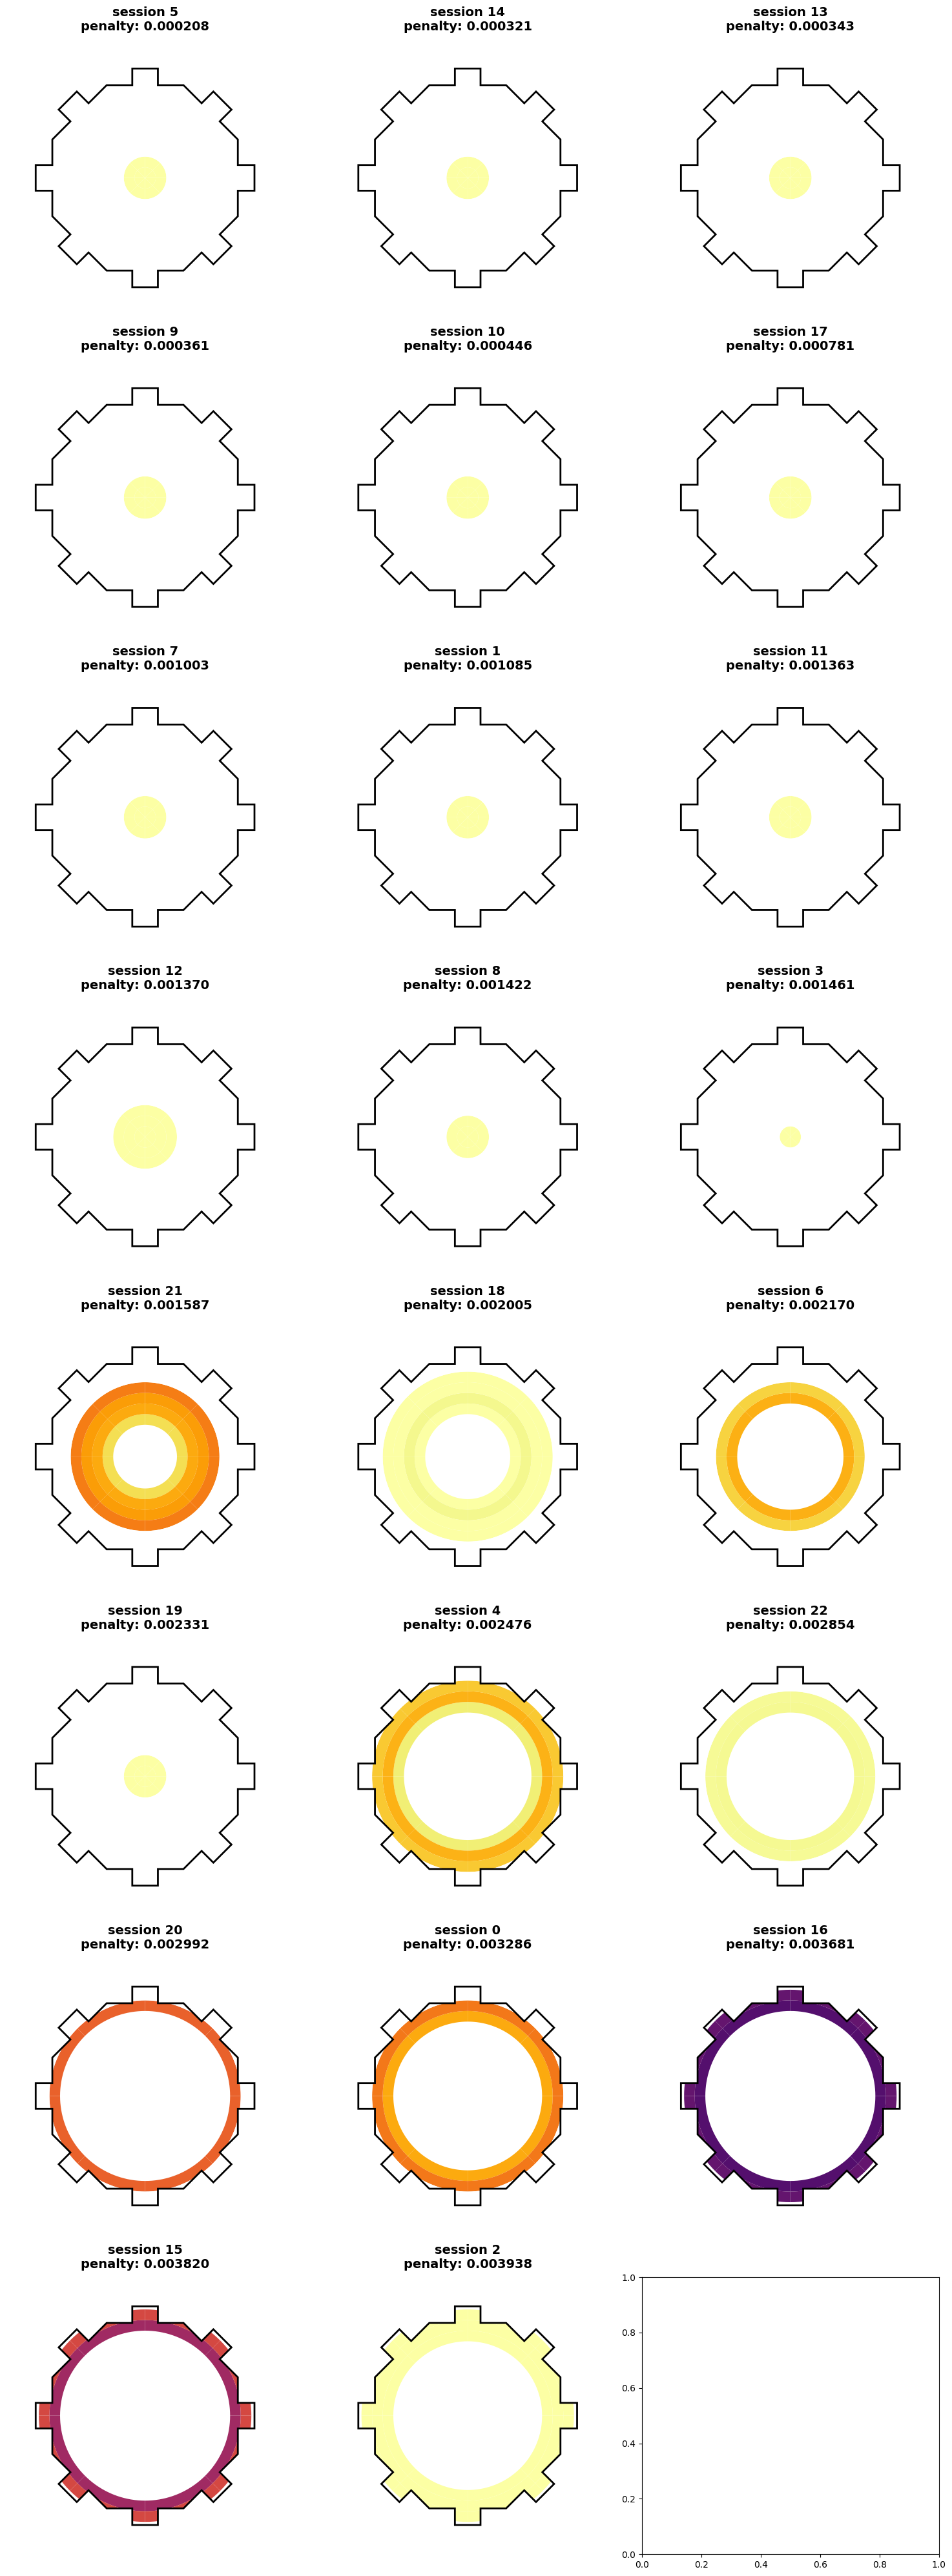

In [203]:
num_i = len(trial_list_high_vis_filtered[0])
sorted_indices = np.argsort(step_penalties)

# Create a grid of subplots
n_cols = 3
n_rows = (len(sorted_indices) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten()  # Flatten to easily iterate

for plot_idx, idx in enumerate(sorted_indices):
    i = idx

    num_radial_bins = 10
    r_max = arena_radius
    radial_bins = np.linspace(0, r_max, num_radial_bins + 1)

    bins_dict_wall_seen = np.zeros(num_radial_bins)
    bins_dict_wall_seen_wall_chosen = np.zeros(num_radial_bins)

    for player_id in range(num_players):
        trial_list_denominator = trial_list_high_vis_filtered[player_id][i]
        trial_list_numerator = trial_list_high_vis_and_choice_filtered[player_id][i]

        for trial_index, trial in enumerate(trial_list_denominator):
            x_val, y_val = get_indices.get_player_slice_onset_loc(trial, player_id=player_id)
            r = np.sqrt(x_val**2 + y_val**2)
            bin_index = np.digitize(r, radial_bins) - 1
            if 0 <= bin_index < num_radial_bins:
                bins_dict_wall_seen[bin_index] += 1

        for trial_index, trial in enumerate(trial_list_numerator):
            x_val, y_val = get_indices.get_player_slice_onset_loc(trial, player_id=player_id)
            r = np.sqrt(x_val**2 + y_val**2)
            bin_index = np.digitize(r, radial_bins) - 1
            if 0 <= bin_index < num_radial_bins:
                bins_dict_wall_seen_wall_chosen[bin_index] += 1

    pH_by_bin_high_solo = np.divide(
        bins_dict_wall_seen_wall_chosen, bins_dict_wall_seen,
        out=np.zeros_like(bins_dict_wall_seen_wall_chosen, dtype=float),
        where=bins_dict_wall_seen > 0
    )
    pH_by_bin_high_solo[bins_dict_wall_seen <= 10] = np.nan
    probabilities_high = pH_by_bin_high_solo

    title = f"session {i}\npenalty: {step_penalties[idx]:.6f}"
    _plot_on_ax(axes[plot_idx], probabilities_high, radial_bins, title)

plt.tight_layout()
plt.show()


Done for player 0, counts in numerator bin 0: 155.0 
Done for player 0, counts in numerator bin 0: 232.0 


/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_10541/3294602641.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)
/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_10541/3294602641.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


Done for player 0, counts in numerator bin 0: 234.0 
Done for player 0, counts in numerator bin 0: 145.0 


/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_10541/3294602641.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)
/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_10541/3294602641.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


Done for player 0, counts in numerator bin 0: 236.0 
Done for player 0, counts in numerator bin 0: 193.0 


...

/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_10541/3294602641.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)
/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_10541/3294602641.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)
/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_10541/3294602641.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(

Done for player 0, counts in numerator bin 0: 210.0 
Done for player 0, counts in numerator bin 0: 0.0 
Done for player 0, counts in numerator bin 0: 0.0 


/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_10541/3294602641.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)
/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_10541/3294602641.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)
/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_10541/3294602641.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(

Done for player 0, counts in numerator bin 0: 0.0 
Done for player 0, counts in numerator bin 0: 0.0 


/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_10541/3294602641.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)
/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_10541/3294602641.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


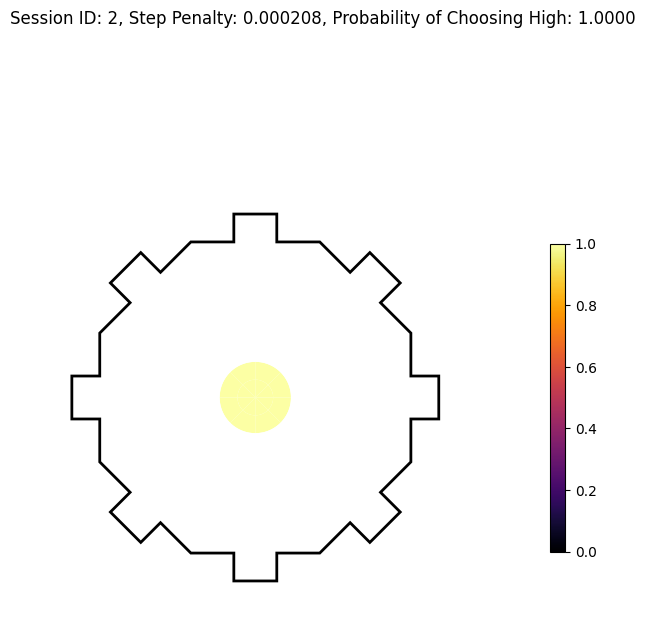

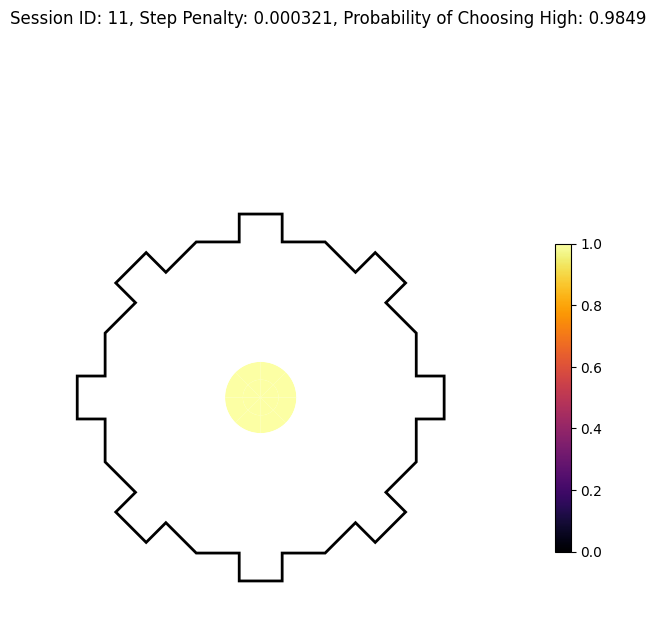

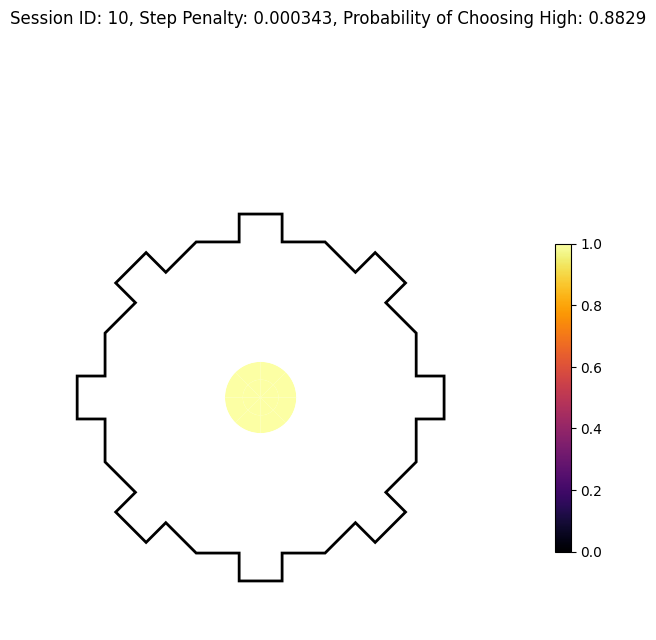

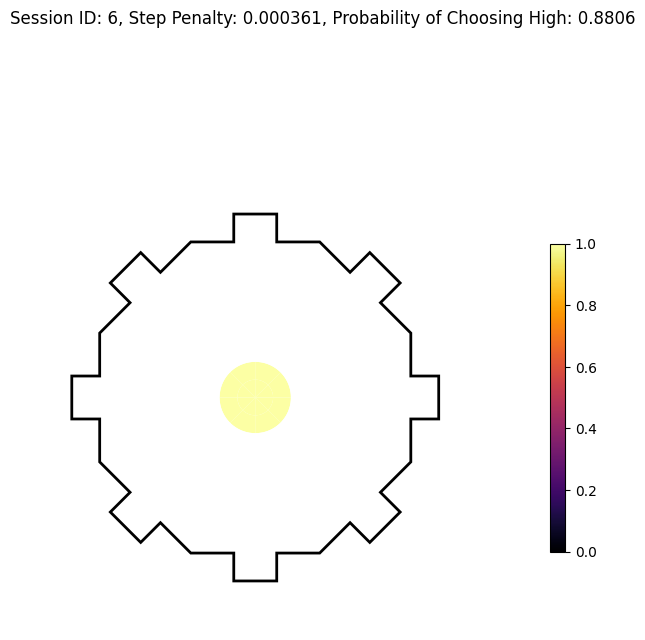

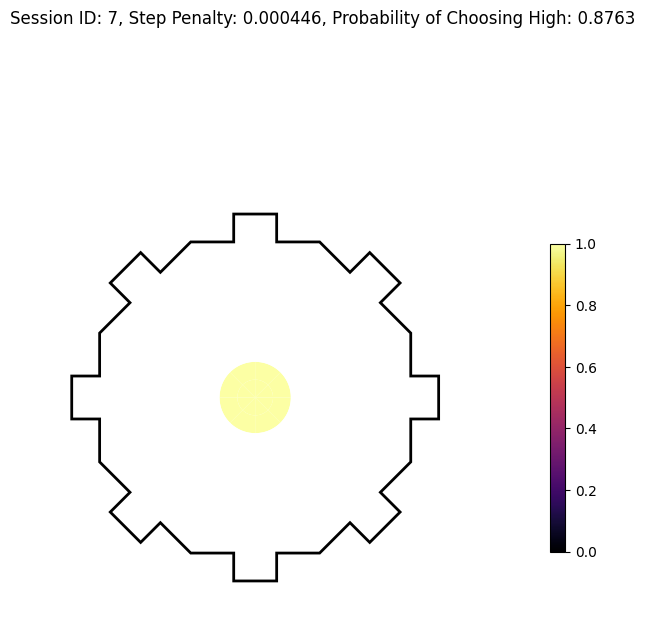

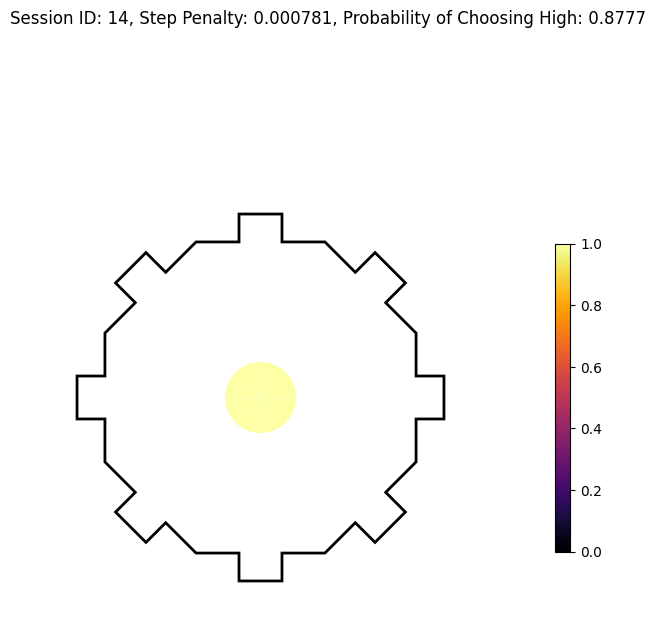

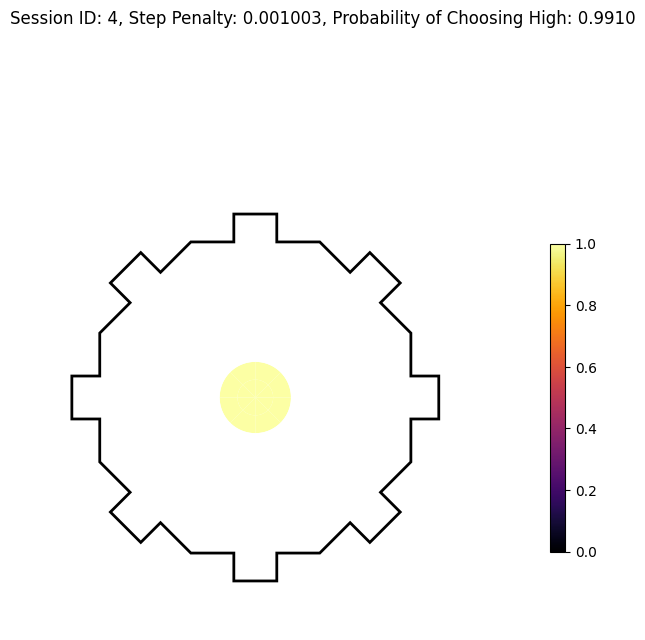

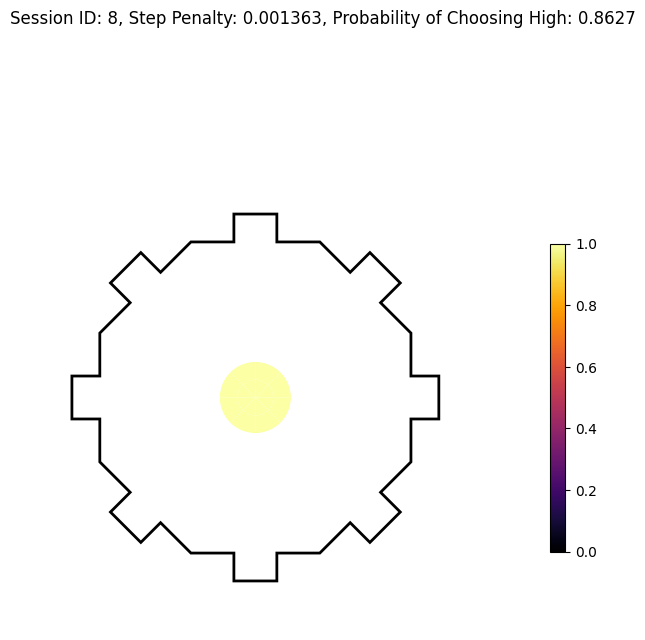

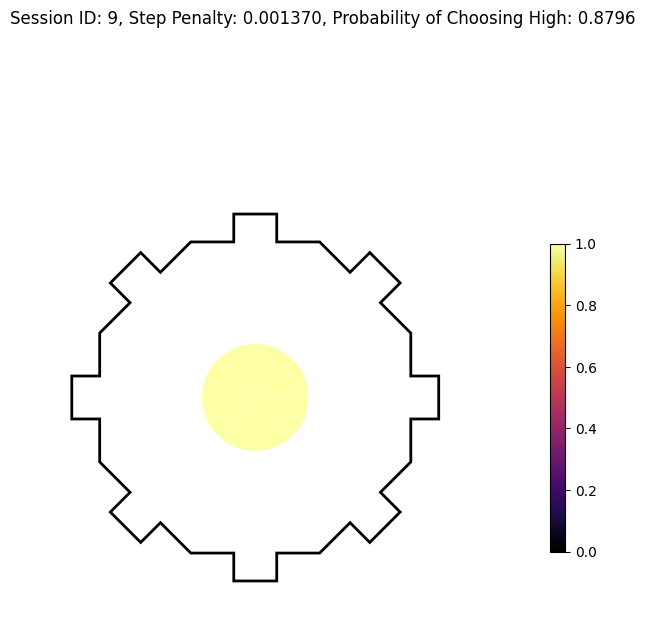

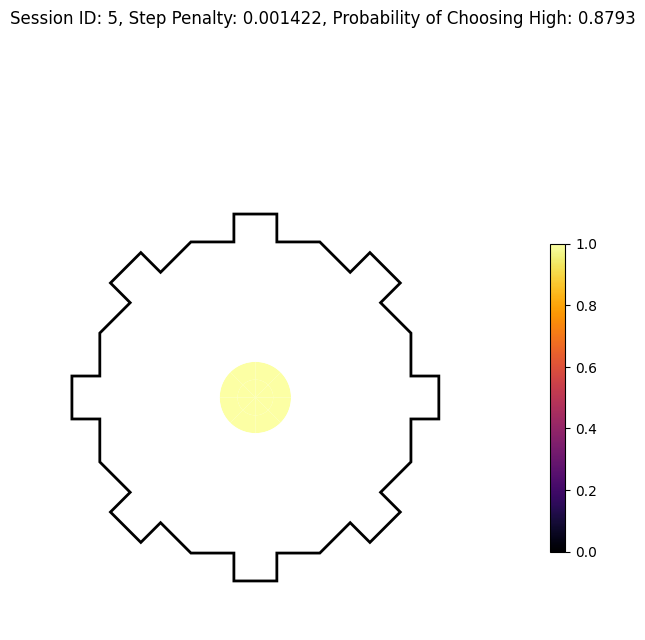

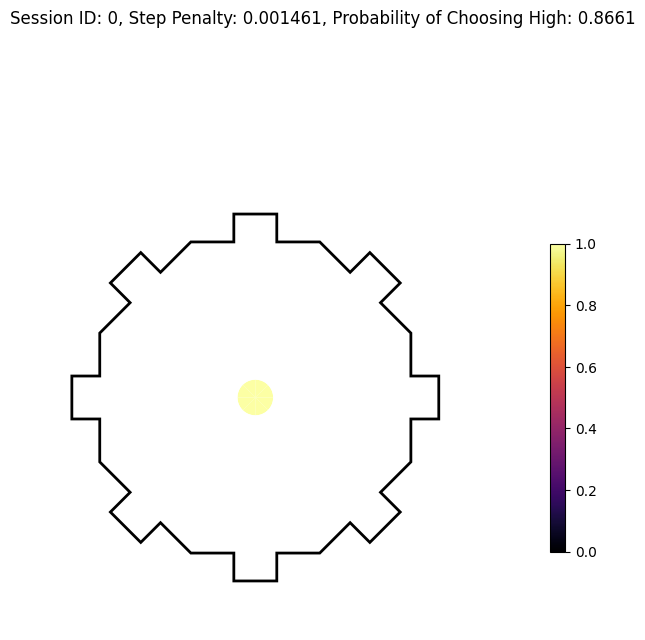

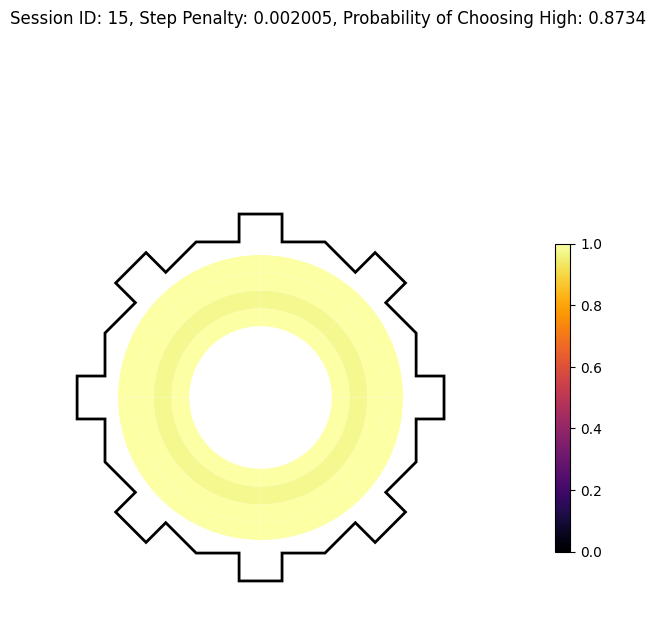

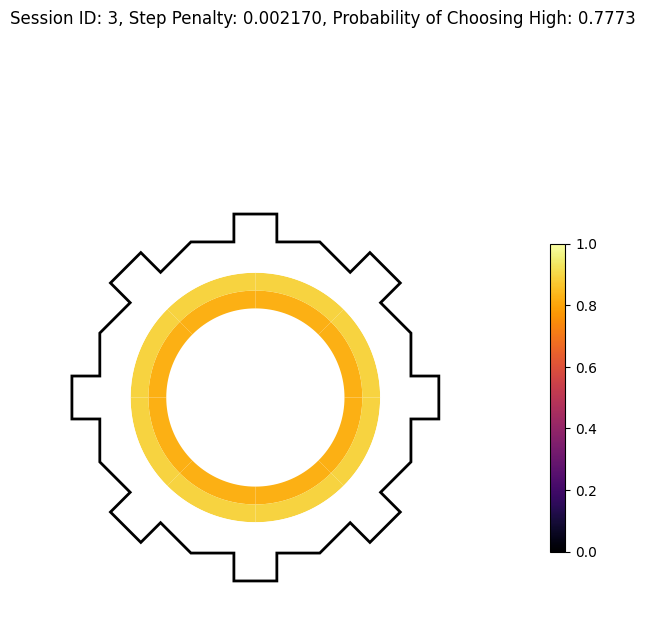

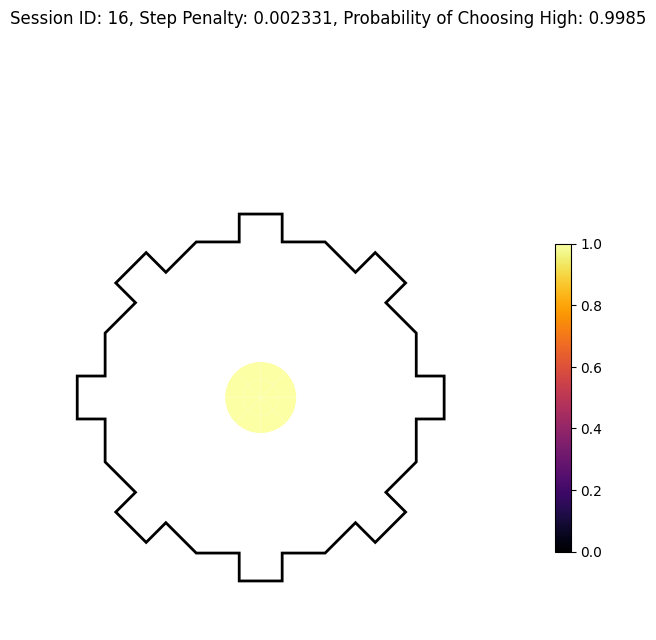

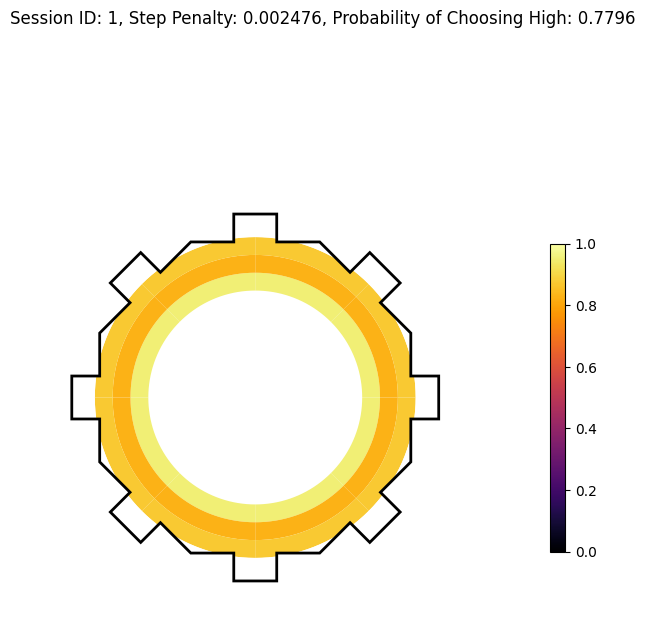

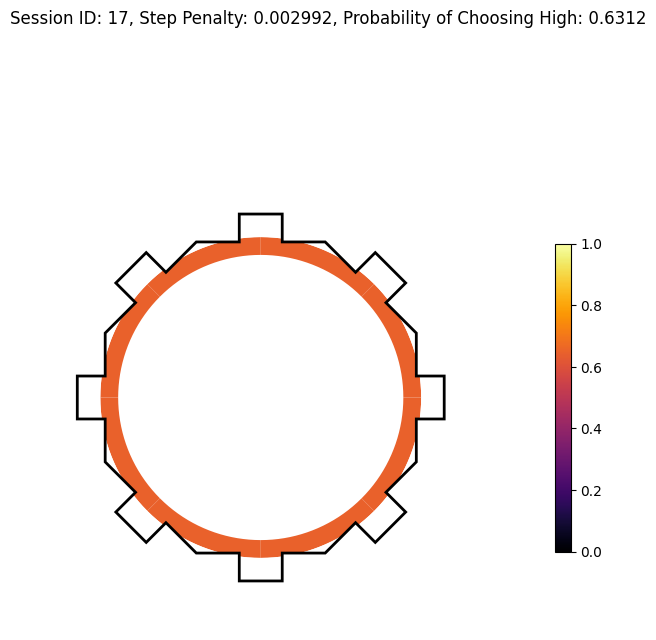

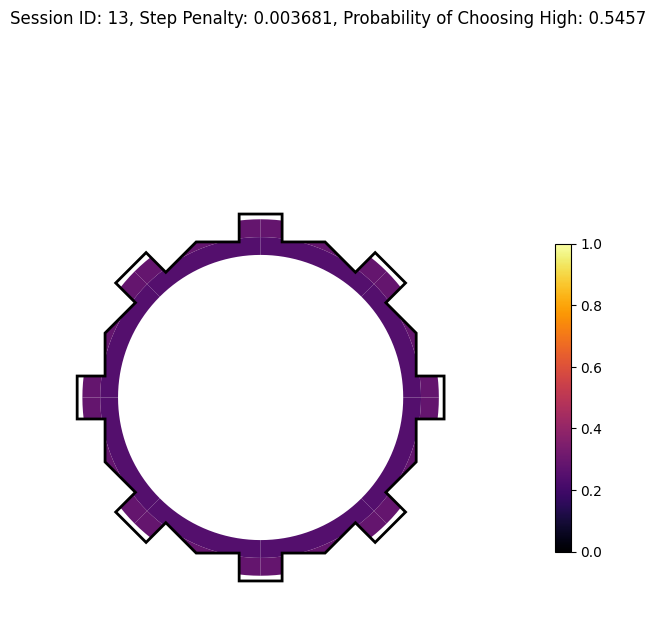

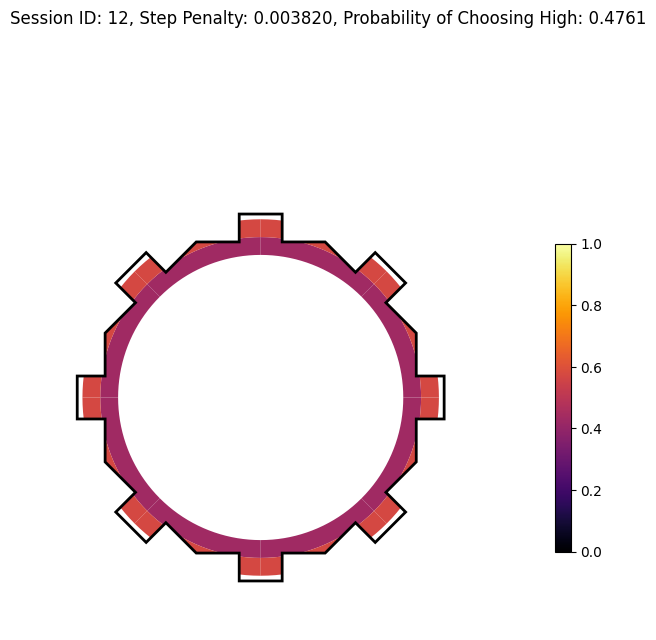

In [130]:
num_i = len(trial_list_low_vis_filtered[0])

sorted_indices = np.argsort(step_penalties)

for idx in sorted_indices:
    i = idx

    num_radial_bins = 10
    r_max = arena_radius
    radial_bins = np.linspace(0, r_max, num_radial_bins + 1)

    # initialise bin counts for radial bins
    bins_dict_wall_seen = np.zeros(num_radial_bins)
    bins_dict_wall_seen_wall_chosen = np.zeros(num_radial_bins)

    # across player ID 1 or 2
    for player_id in range(num_players):
        
        # filtered for trials where player saw specified first-seen wall
        trial_list_denominator = trial_list_high_vis_filtered[player_id][i]
        # filter for trials where player additionally chose specified chosen wall
        trial_list_numerator = trial_list_high_vis_and_choice_filtered[player_id][i]

        
        # across each trial in the trial list
        for trial_index, trial in enumerate(trial_list_denominator):
            
            # get slice onset position (denominator)
            x_val, y_val = get_indices.get_player_slice_onset_loc(trial, player_id=player_id)

            # compute radial distance
            r = np.sqrt(x_val**2 + y_val**2)

            # find bin index
            bin_index = np.digitize(r, radial_bins) - 1

            # increment denominator bin count if within range
            if 0 <= bin_index < num_radial_bins:
                bins_dict_wall_seen[bin_index] += 1

        # across each trial in the filtered list
        for trial_index, trial in enumerate(trial_list_numerator):
            # get slice onset position (numerator)
            x_val, y_val = get_indices.get_player_slice_onset_loc(trial, player_id=player_id)

            # compute radial distance
            r = np.sqrt(x_val**2 + y_val**2)

            # find bin index
            bin_index = np.digitize(r, radial_bins) - 1

            # increment numerator bin count if within range
            if 0 <= bin_index < num_radial_bins:
                bins_dict_wall_seen_wall_chosen[bin_index] += 1

    print(f"Done for player {player_id}, counts in numerator bin 0: {bins_dict_wall_seen_wall_chosen[0]} ")
    
    # element-wise division of numerator and denominator arrays, with handling for division by zero
    pH_by_bin_high_solo = np.divide(
        bins_dict_wall_seen_wall_chosen, bins_dict_wall_seen,
        out=np.zeros_like(bins_dict_wall_seen_wall_chosen, dtype=float),
        # boolean array to mask division for only non-zero denominator entries
        where=bins_dict_wall_seen > 0
    )

    # filter out bins with fewer than x trials
    pH_by_bin_high_solo[bins_dict_wall_seen <= 10] = np.nan
    probabilities_high = pH_by_bin_high_solo

    title = f"Session ID: {i}, Step Penalty: {step_penalties[idx]:.6f}, Probability of Choosing High: {analysis_results[i]['choice_data']['probability_chose_high']:.4f}"
    plot_heatmap_phigh_circular(probabilities_high, radial_bins, n_angular_bins=8, 
                                    cmap_name='inferno', diff_cmap_name='PiYG')
    plt.suptitle(title)

# P(High) by first-visible stimulus violin plots

In [206]:
import analysis.conditioned_player_choice as conditioned_player_choice

In [212]:
inferred_choice = False
current_fov = 110
chosen_wall_index = 0
visible_wall_index = 0
other_visible = None
wall_initial_vis_only = False
wall_sep = None
inverse_other_visible = False
solo = True
data_size_cutoff = 5

Low first

In [208]:
(probabilities1,
 numerator1,
  denominator1) = conditioned_player_choice.probability_trial_outcome_given_conditions_all_sessions(trial_lists, inferred_choice, current_fov,
                                                            chosen_wall_index=chosen_wall_index, visible_wall_index=visible_wall_index,
                                                            other_visible=other_visible, wall_initial_vis_only=wall_initial_vis_only,
                                                            wall_sep=wall_sep, inverse_other_visible=inverse_other_visible, solo=solo,
                                                            trial_type=globals.HIGH_LOW, data_size_cutoff=data_size_cutoff, debug=False)

filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 1. 1. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0.
 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0.
 0. 0. 1. 0. 1. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 1. 1. 0. 1. 0. 0.
 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.
 1. 0. 0. 0. 0. 0. 1. 1. 0. 1. 1. 0. 0. 0. 0. 1. 0. 1. 0. 1. 0. 0. 1. 0.
 0. 1. 1. 0. 0. 0. 0. 1. 1. 0. 1. 0. 0. 1. 1. 0. 0. 0. 0. 1. 1. 0. 0. 1.
 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 1. 1. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0.
 1. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 1.
 0. 0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 1. 0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 0. 0.
 0. 0. 0. 1. 0. 1. 0. 0. 0. 1. 0. 1. 0. 0. 0. 1. 0. 1. 0. 0. 0. 1. 0. 0.
 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.
 1. 0. 0. 0. 0. 1. 0. 0. 0. 1. 1. 0. 

In [210]:
len(probabilities1)

23

High first

In [213]:
(probabilities2,
 numerator2,
  denominator2) = conditioned_player_choice.probability_trial_outcome_given_conditions_all_sessions(trial_lists, inferred_choice, current_fov,
                                                            chosen_wall_index=chosen_wall_index, visible_wall_index=visible_wall_index,
                                                            other_visible=other_visible, wall_initial_vis_only=wall_initial_vis_only,
                                                            wall_sep=wall_sep, inverse_other_visible=inverse_other_visible, solo=solo,
                                                            trial_type=globals.HIGH_LOW, data_size_cutoff=data_size_cutoff, debug=False)

filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 1. 1. 0. 0. 0. 0. 1.
 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 1. 0.
 0. 0. 1. 0. 1. 1. 0. 0. 0. 1. 0. 0. 1. 1. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1.
 1. 0. 0. 0. 1. 0. 0. 0. 1. 1. 0. 0. 1. 0. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0.
 0. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 1. 1. 0. 0.
 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 1. 0. 0.
 0. 0. 0. 0. 1. 0. 1. 0. 1. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0.
 0. 1. 0. 1. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 1.
 0. 0. 1. 0. 1. 0. 0. 1. 1. 0. 1. 0. 0. 1. 1. 0. 0. 0. 0. 1. 1. 0. 1. 1.
 0. 0. 0. 1. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 1. 0. 1. 0.
 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 

In [214]:
len(probabilities2)

23

In [215]:
import plotting.plot_violinplots as plot_violinplots

In [227]:
step_penalties_ordered, probabilities1_ordered, probabilities2_ordered = zip(*sorted(zip(step_penalties, probabilities1, probabilities2)))

In [232]:
probabilities2_ordered = np.array(probabilities2_ordered)
probabilities1_ordered = np.array(probabilities1_ordered)

/Users/benny/Repos/octagon_analysis/plotting/plot_violinplots.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(x="Condition", y="Probability", data=df, palette=custom_palette,


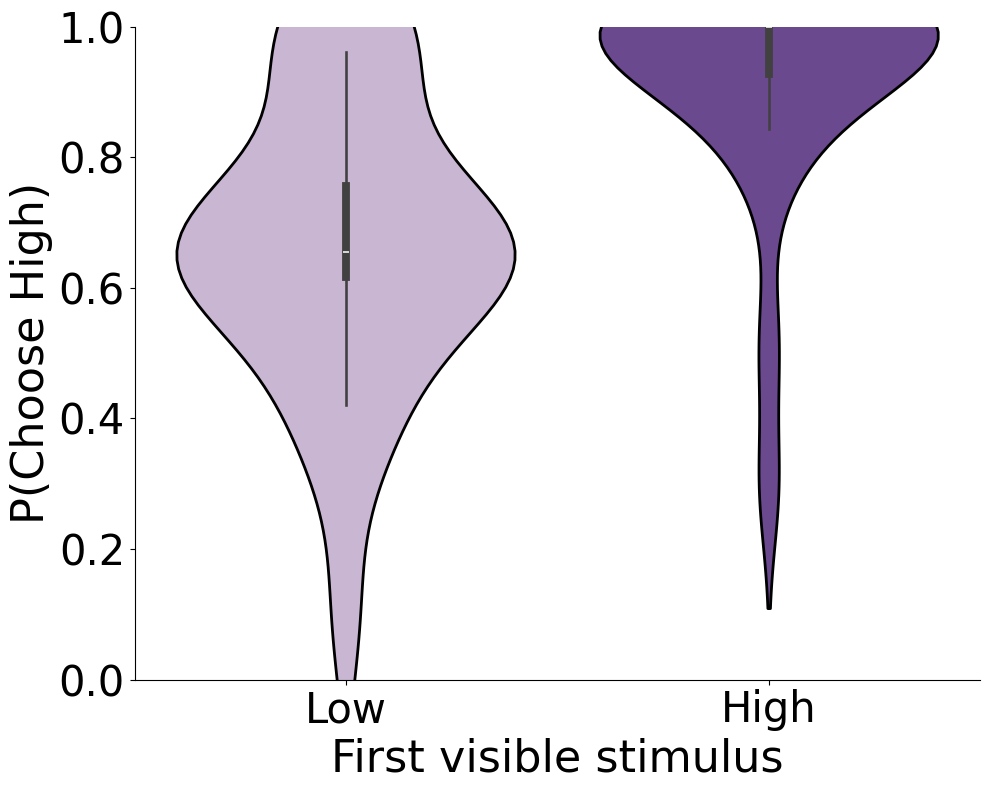

In [234]:
data = [probabilities1_ordered.ravel(), probabilities2_ordered.ravel()]
labels = ['Low', 'High']
plot_violinplots.plot_violinplot(data, labels, ylim=[0.0,1],
                                  ylabel="P(Choose High)", xlabel="First visible stimulus",color_offset=8,
                           return_data=False);